# Прогноз дивидендов и построение факторных стратегий: сопоставление рынков РФ и Японии

**Автор:** Еремкин Дмитрий Валерьевич
**Магистерская программа:** «Инвестиции на финансовых рынках», НИУ ВШЭ, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eremkindv91/dividend-factor-strategies/blob/main/notebooks/03_ml_dividend_forecast.ipynb)


In [ ]:
# ─── Setup: paths & dependencies ─────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# Detect environment: Google Colab vs Local vs Binder
if 'google.colab' in sys.modules:
    print("Google Colab detected. Installing dependencies...")
    os.system("pip install -q catboost xgboost lightgbm scikit-learn shap pandas numpy scipy matplotlib seaborn openpyxl 2>/dev/null")

    # Clone repo
    REPO_URL = "https://github.com/eremkindv91/dividend-factor-strategies"
    if not os.path.exists("/content/dividend-factor-strategies"):
        os.system(f"git clone {REPO_URL} /content/dividend-factor-strategies 2>/dev/null")

    PROJECT_ROOT = Path("/content/dividend-factor-strategies")
    os.chdir(PROJECT_ROOT)
    sys.path.insert(0, str(PROJECT_ROOT))
    print("✓ Colab environment ready")

elif os.getenv('BINDER_LAUNCH_HOST'):
    print("Binder detected")
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())

else:
    # Local: notebook is in notebooks/, go up one level to repo root
    PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == "notebooks" else Path(os.getcwd())
    print("Local environment")

DATA_DIR = PROJECT_ROOT / "data"
print(f"Project: {PROJECT_ROOT.name}")
print(f"Data   : {DATA_DIR}")

assert DATA_DIR.exists(), f"Error: Data not found at {DATA_DIR}"
print("Ready to run.\n")

Python 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
NumPy 1.26.4, Pandas 2.3.3
All imports successful.
Config: SEED=42, CV_START=2016, PRED_YEAR=2025
Output: /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5
Helpers ready.

──────────────────────────────────────────────────
  RUSSIA: 3048 rows × 208 cols, 268 tickers, years 2011–2025
  ⚠ dps_rub: 62% missing
  ⚠ 67 ticker-year gaps detected (potential survivorship issue)
  Observations per year: min=131, max=251, median=206
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  JAPAN: 3660 rows × 155 cols, 246 tickers, years 2010–2025
  Observations per year: min=35, max=245, median=242
──────────────────────────────────────────────────
Building targets...
  RUSSIA:
  labeled=2735, unlabeled=313, paid_rate=40.8%
  JAPAN:
  labeled=3414, unlabeled=246, paid_rate=93.2%


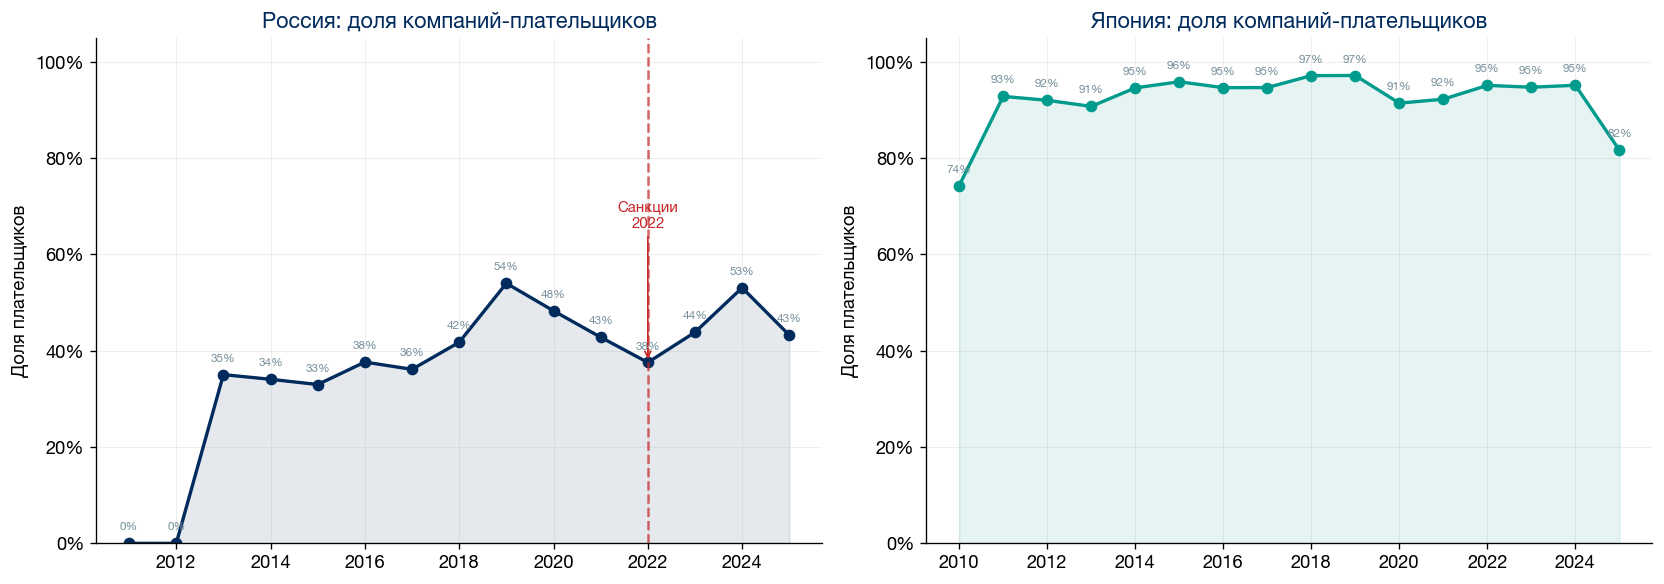

DSI proxy — RF mean: 0.126, JP mean: 0.419

Engineering macro interaction features...
  RF: 10 interaction features
  JP: 5 interaction features
  Dropped 29 correlated features (|r|>0.98): ['CAPEX_', 'assets_mln', 'bank_bonds_bln', 'bank_securities_bln', 'budget_expenditure_mln']...
  Dropped 15 correlated features (|r|>0.98): ['ev_mln', 'inter_nikkei_x_mom', 'is_any_keiretsu', 'japan_term_spread_avg', 'leverage_ratio']...

RF features: 146 total (2 categorical)
JP features: 116 total (3 categorical)

Feature sets:
  RF Set A: 146 features | JP Set A: 116 features
  RF Set B: 142 features | JP Set B: 113 features
  RF Set C:   6 features | JP Set C:   6 features
  RF Set D:   4 features | JP Set D:   3 features

  RF div-history cols in data: ['div_streak', 'div_growth_streak', 'div_cut_count', 'dsi_proxy']
  JP div-history cols in data: ['div_streak', 'div_growth_streak', 'dsi_proxy']
MultiModelZI class defined (v5 — native NaN for CatBoost/LightGBM).
Walk-forward CV engine ready (v5

In [4]:


# %% [markdown]
# # ML-прогнозирование дивидендной устойчивости: Россия vs Япония

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

import os, sys, time, json, traceback
from typing import List, Tuple, Dict, Optional, Any
from collections import namedtuple
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from scipy.stats import t as t_dist

from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from xgboost import XGBClassifier, XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.isotonic import IsotonicRegression
import shap

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, HTML

print(f'Python {sys.version}')
print(f'NumPy {np.__version__}, Pandas {pd.__version__}')
print('All imports successful.')

# %%
# ══════════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════════

SEED          = 42
PRED_YEAR     = 2026   # features from 2026 → predict 2026 dividends
CI_ALPHA      = 0.10   # conformal interval level (90%)
TOP_N         = 20
CV_START_YEAR = 2016
YIELD_CAP     = 100.0
N_BOOT        = 500

# ── Hyperparameters (consistent with methodology text) ──
CB_ITER  = 1200; CB_LR = 0.04; CB_DEPTH = 6; CB_L2 = 3.0; CB_EARLY = 100
XGB_ITER = 600;  XGB_LR = 0.04; XGB_DEPTH = 6; XGB_EARLY = 80
LGB_ITER = 600;  LGB_LR = 0.04; LGB_DEPTH = 6; LGB_EARLY = 80
RF_TREES = 400;  RF_DEPTH = 10

# ── Column names ──
RF_DPS_COL  = 'dps_rub';       RF_FLAG_COL = 'div_paid_flag'; RF_PRICE_COL = 'price_end'
JP_DPS_COL  = 'div_per_share'; JP_FLAG_COL = 'div_paid_flag'; JP_PRICE_COL = 'price_end'

# ── Leakage prevention: columns to ALWAYS exclude from features ──
EXCLUDE_ALWAYS = {
    'ticker', 'year', 'country', 'currency',
    'div_paid_flag', 'div_yield_pct', 'dps_rub', 'div_per_share',
    'payout_ratio_pct', 'paid_next', 'dps_next', 'y_next_pct',
    'label_known_paid', 'label_known_yield',
    'fwd_ret_cal_year_pct',
    'buyback_yield_pct', 'total_shareholder_yield_pct',
    'oil_div_payout_pct',
    'sector_group', 'post_2022',  # auxiliary columns, not features
}
EXCLUDE_PREFIXES = ('fwd_', 'target_', 'label_', '_tmp_')

# Dividend-history columns for ablation study
DIV_HISTORY_COLS = {
    'div_streak', 'div_growth_streak', 'div_cut_count',
    'lag1_dps', 'lag2_dps', 'lag3_dps',
    'lag1_div_yield', 'lag2_div_yield', 'lag3_div_yield',
    'lag1_paid', 'lag2_paid', 'lag3_paid',
    'dsi_proxy', 'div_stability_5y', 'payout_stability_cv',
}

# ── Paths ──
PATH_RF  = str(DATA_DIR / 'рф_ПАНЕЛЬ_enriched_BACKUP2.xlsx')
PATH_JP  = str(DATA_DIR / 'JP_PANEL_enriched.xlsx')
OUT_DIR  = str(DATA_DIR / 'OUTPUT_ML_V5')
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_NAMES = ['catboost', 'xgboost', 'lightgbm', 'rf', 'logreg']
DISPLAY_NAME = {
    'catboost': 'CatBoost', 'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM', 'rf': 'Random Forest',
    'logreg': 'Logistic Regression',
}

# Sector grouping for sub-models
RF_SECTOR_MAP = {
    'Нефть и газ': 'Нефть и газ', 'Финансы (Банки)': 'Банки',
    'Финансы': 'Банки', 'Металлы и добыча': 'Металлы',
    'Энергетика': 'Энергетика',
}
JP_SECTOR_MAP = {
    'Financials': 'Financials', 'Materials': 'Materials',
    'Industrials': 'Industrials',
}

np.random.seed(SEED)
print(f'Config: SEED={SEED}, CV_START={CV_START_YEAR}, PRED_YEAR={PRED_YEAR}')
print(f'Output: {OUT_DIR}')

# %%
# ══════════════════════════════════════════════════════════════
#  PLOTTING STYLE & HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════

NAVY = '#002B5C'; GOLD = '#F9A825'; TEAL = '#009B8D'
CRIMSON = '#C62828'; GRAY = '#78909C'; LIGHT_BG = '#F7F9FC'
GREEN = '#2E7D32'; ORANGE = '#EF6C00'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.5,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
MODEL_COLORS = {
    'catboost': NAVY, 'xgboost': TEAL, 'lightgbm': GOLD,
    'rf': GRAY, 'logreg': CRIMSON,
}

def safe_cat(series: pd.Series, fill: str = 'Unknown') -> pd.Series:
    """Convert column to clean string categorical: NaN → fill, 'nan'/'None' → fill."""
    return (series
            .fillna(fill)
            .astype(str)
            .replace({'nan': fill, 'None': fill, '': fill}))

def safe_col(df: pd.DataFrame, col: str, default=0.0) -> pd.Series:
    """Return column if exists, else constant Series."""
    if col in df.columns:
        return df[col]
    return pd.Series(default, index=df.index, name=col)

def mckinsey_table(data_rows, headers, title, highlight_col=None,
                   minimize_col=None):
    """Render HTML table. highlight_col = maximize, minimize_col = minimize."""
    HEADER_BG = NAVY; BORDER = '#D4D9E1'; BODY_FG = '#23272F'
    EVEN_BG = '#F7F9FC'; ODD_BG = '#FFFFFF'

    # Find best values (per-country if 'Страна'/'Country' column exists)
    country_col = None
    for i, h in enumerate(headers):
        if h.lower() in ('страна', 'country'):
            country_col = i
            break

    def _best_by_group(col_idx, maximize=True):
        groups = {}
        for r in data_rows:
            try:
                val = float(r[col_idx])
            except (ValueError, TypeError, IndexError):
                continue
            key = r[country_col] if country_col is not None else '__all__'
            if key not in groups or (maximize and val > groups[key]) or \
               (not maximize and val < groups[key]):
                groups[key] = val
        return groups

    best_max = _best_by_group(highlight_col, True) if highlight_col is not None else {}
    best_min = _best_by_group(minimize_col, False) if minimize_col is not None else {}

    html = f'<div style="margin:20px 0;">'
    html += (f'<div style="background:{NAVY};color:white;padding:12px 20px;'
             f'font-size:15px;font-weight:600;border-radius:8px 8px 0 0;">{title}</div>')
    html += ('<table style="width:100%;border-collapse:collapse;'
             'font-family:Helvetica Neue,Arial,sans-serif;font-size:12px;">')
    html += '<tr>'
    for h in headers:
        html += (f'<th style="background:{HEADER_BG};color:white;padding:10px 12px;'
                 f'text-align:center;border:1px solid {BORDER};font-weight:600;">{h}</th>')
    html += '</tr>'

    for idx, row in enumerate(data_rows):
        bg = EVEN_BG if idx % 2 == 0 else ODD_BG
        key = row[country_col] if country_col is not None else '__all__'
        html += '<tr>'
        for ci, val in enumerate(row):
            fw, color = 'normal', BODY_FG
            try:
                v = float(val)
                if ci == highlight_col and key in best_max and abs(v - best_max[key]) < 1e-9:
                    fw, color = 'bold', GREEN
                if ci == minimize_col and key in best_min and abs(v - best_min[key]) < 1e-9:
                    fw, color = 'bold', GREEN
            except (ValueError, TypeError):
                pass
            html += (f'<td style="background:{bg};color:{color};padding:8px 12px;'
                     f'text-align:center;border:1px solid {BORDER};font-weight:{fw};">{val}</td>')
        html += '</tr>'
    html += '</table></div>'
    return html

def save_fig(name: str):
    """Save current figure as PNG and PDF."""
    plt.savefig(f'{OUT_DIR}/{name}.png')
    plt.savefig(f'{OUT_DIR}/{name}.pdf')

print('Helpers ready.')

# %%
# ══════════════════════════════════════════════════════════════
#  DATA LOADING & VALIDATION
# ══════════════════════════════════════════════════════════════

def load_panel(path: str) -> pd.DataFrame:
    """Load Excel panel, clean columns, deduplicate."""
    assert os.path.exists(path), f'File not found: {path}'
    df = pd.read_excel(path, engine='openpyxl')
    df.columns = [c.strip() for c in df.columns]
    if 'ticker' in df.columns:
        df['ticker'] = df['ticker'].astype(str).str.strip()
    if 'year' in df.columns:
        df['year'] = df['year'].astype(int)
    n_before = len(df)
    df = df.drop_duplicates(subset=['ticker', 'year'], keep='first')
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(f'  Dropped {n_dropped} duplicate ticker-year rows')
    return df

def validate_panel(df: pd.DataFrame, name: str, dps_col: str, flag_col: str,
                   price_col: str):
    """Run diagnostic checks on loaded panel."""
    print(f'\n{"─"*50}')
    print(f'  {name}: {df.shape[0]} rows × {df.shape[1]} cols, '
          f'{df["ticker"].nunique()} tickers, '
          f'years {df["year"].min()}–{df["year"].max()}')

    # Check required columns
    required = {'ticker', 'year', dps_col, flag_col, price_col}
    missing = required - set(df.columns)
    assert not missing, f'Missing required columns: {missing}'

    # Missingness summary for key columns
    key_cols = [dps_col, flag_col, price_col, 'roe_pct', 'ebitda_margin_pct',
                'div_streak', 'sector']
    for c in key_cols:
        if c in df.columns:
            pct = df[c].isna().mean()
            if pct > 0.3:
                print(f'  ⚠ {c}: {pct:.0%} missing')

    # Check for gaps in panel (survivorship bias indicator)
    gaps = 0
    for tk, g in df.groupby('ticker')['year']:
        yrs = sorted(g.values)
        expected = list(range(yrs[0], yrs[-1] + 1))
        gaps += len(set(expected) - set(yrs))
    if gaps > 0:
        print(f'  ⚠ {gaps} ticker-year gaps detected (potential survivorship issue)')

    # Year distribution
    yr_counts = df['year'].value_counts().sort_index()
    print(f'  Observations per year: min={yr_counts.min()}, '
          f'max={yr_counts.max()}, median={yr_counts.median():.0f}')
    print(f'{"─"*50}')

rf_raw = load_panel(PATH_RF)
jp_raw = load_panel(PATH_JP)
validate_panel(rf_raw, 'RUSSIA', RF_DPS_COL, RF_FLAG_COL, RF_PRICE_COL)
validate_panel(jp_raw, 'JAPAN',  JP_DPS_COL, JP_FLAG_COL, JP_PRICE_COL)

# %%
# ══════════════════════════════════════════════════════════════
#  TARGET CONSTRUCTION
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Целевые переменные
#
# Для каждого наблюдения «тикер × год t» создаётся:
# - `paid_next` — бинарная метка: 1 если дивиденды выплачены в t+1
# - `dps_next` — размер DPS в t+1
# - `y_next_pct` — дивидендная доходность = DPS(t+1) / price(t)
#
# Наблюдение считается размеченным (`label_known_paid=1`) только если
# год t+1 **присутствует в панели** для данного тикера.
# Это предотвращает ложную разметку при разрывах в данных.

# %%
def build_targets(df: pd.DataFrame, dps_col: str, flag_col: str,
                  price_col: str) -> pd.DataFrame:
    """Create forward-shifted targets for dividend prediction."""
    df_s = df.sort_values(['ticker', 'year']).copy()
    df_s['paid_next'] = df_s.groupby('ticker')[flag_col].shift(-1)
    df_s['dps_next']  = df_s.groupby('ticker')[dps_col].shift(-1)
    df_s['_next_yr']  = df_s.groupby('ticker')['year'].shift(-1)

    # Only label observations where t+1 actually exists in panel
    ok = df_s['_next_yr'] == df_s['year'] + 1
    df_s.loc[~ok, ['paid_next', 'dps_next']] = np.nan
    df_s['label_known_paid'] = np.where(ok & df_s['paid_next'].notna(), 1, 0)

    price_ok = df_s[price_col].notna() & (df_s[price_col] > 0)
    df_s['label_known_yield'] = np.where(
        (df_s['label_known_paid'] == 1) & price_ok, 1, 0)
    df_s['y_next_pct'] = np.where(
        df_s['label_known_yield'] == 1,
        100.0 * df_s['dps_next'].fillna(0) / df_s[price_col],
        np.nan)

    df_s.drop(columns=['_next_yr'], inplace=True)

    # Diagnostics
    lbl = df_s['label_known_paid'] == 1
    n_unlabeled = (~lbl).sum()
    rate = df_s.loc[lbl, 'paid_next'].mean() if lbl.any() else 0
    print(f'  labeled={lbl.sum()}, unlabeled={n_unlabeled}, '
          f'paid_rate={rate:.1%}')
    return df_s

print('Building targets...')
print('  RUSSIA:')
rf = build_targets(rf_raw, RF_DPS_COL, RF_FLAG_COL, RF_PRICE_COL)
print('  JAPAN:')
jp = build_targets(jp_raw, JP_DPS_COL, JP_FLAG_COL, JP_PRICE_COL)

# %%
# ── Dividend rate by year (visualization) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (d, nm, fc, color) in zip(axes, [
    (rf, 'Россия', RF_FLAG_COL, NAVY),
    (jp, 'Япония', JP_FLAG_COL, TEAL),
]):
    rates = d.groupby('year')[fc].mean()
    ax.plot(rates.index, rates.values, marker='o', color=color,
            linewidth=2, markersize=6)
    ax.fill_between(rates.index, 0, rates.values, alpha=0.1, color=color)
    if nm == 'Россия':
        ax.axvline(x=2022, color=CRIMSON, ls='--', lw=1.5, alpha=0.7)
        y22 = rates.loc[2022] if 2022 in rates.index else 0.5
        ax.annotate('Санкции\n2022', xy=(2022, y22), fontsize=9,
                    color=CRIMSON, ha='center', va='bottom',
                    xytext=(2022, max(y22 + 0.08, 0.65)),
                    arrowprops=dict(arrowstyle='->', color=CRIMSON, lw=1))
    ax.set_title(f'{nm}: доля компаний-плательщиков',
                 fontsize=13, fontweight='bold', color=NAVY)
    ax.set_ylabel('Доля плательщиков')
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    for yr, val in rates.items():
        ax.annotate(f'{val:.0%}', (yr, val), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color=GRAY)

plt.tight_layout()
save_fig('fig_paid_rate_by_year')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### DSI proxy
#
# DSI = (min(div_streak, 7)/7 + min(div_growth_streak, 7)/7) / 2
#
# Порог 7 лет выбран по аналогии с определением стабильных дивидендов
# в российской практике (Наимов, 2019). fillna(0) означает «нет истории = 0».
#
# ### Macro interaction features
#
# Попарные произведения макропеременных с финансовыми показателями.
# Границы обрезки — **экспертные**, не оптимизированные по данным:
# - net_debt_to_ebitda: [−10, 30]
# - ROE: [−100%, 200%]
# - EBITDA margin: [−50%, 100%]

# %%
# ── DSI proxy ──
for d in [rf, jp]:
    d['dsi_proxy'] = (
        d['div_streak'].clip(0, 7).fillna(0) / 7 +
        d['div_growth_streak'].clip(0, 7).fillna(0) / 7
    ) / 2

print(f'DSI proxy — RF mean: {rf["dsi_proxy"].mean():.3f}, '
      f'JP mean: {jp["dsi_proxy"].mean():.3f}')

# ── Macro interaction features ──
def add_interaction(df: pd.DataFrame, name: str, col_a: str, col_b: str,
                    clip_a=None, clip_b=None, scale_a=1.0, scale_b=1.0,
                    transform_b=None):
    """Add interaction feature safely. Missing columns → 0."""
    a = safe_col(df, col_a).fillna(0)
    b = safe_col(df, col_b).fillna(0)
    if clip_a:
        a = a.clip(*clip_a)
    if clip_b:
        b = b.clip(*clip_b)
    a = a * scale_a
    b = b * scale_b
    if transform_b == 'sign':
        b = np.sign(b)
    elif transform_b == 'log1p_abs':
        b = np.log1p(np.abs(b))
    df[name] = a * b

print('\nEngineering macro interaction features...')

# Russia
add_interaction(rf, 'inter_rate_x_leverage', 'key_rate_pct',
                'net_debt_to_ebitda', clip_b=(-10, 30))
add_interaction(rf, 'inter_rate_x_roe', 'key_rate_pct', 'roe_pct',
                clip_b=(-100, 200), scale_b=0.01)
add_interaction(rf, 'inter_gdp_x_vol', 'gdp_growth_yoy_pct',
                'vol3y_net_profit', clip_b=(0, 1e12), transform_b='log1p_abs')
add_interaction(rf, 'inter_infl_x_margin', 'inflation_dec_yoy_pct',
                'ebitda_margin_pct', clip_b=(-50, 100), scale_b=0.01)
add_interaction(rf, 'inter_oil_rev_x_fcf', 'oil_gas_revenue_bln',
                'oil_fcf_mln', transform_b='sign')
add_interaction(rf, 'inter_rate_x_nim', 'key_rate_pct', 'nim_pct')
add_interaction(rf, 'inter_steel_price_x_spread', 'steel_global_hrc_eoy',
                'steel_spread_russia_vs_global', scale_a=0.001)

# Japan
add_interaction(jp, 'inter_rate_x_leverage', 'boj_rate_avg',
                'debt_to_ebitda', clip_b=(-10, 30))
add_interaction(jp, 'inter_infl_x_margin', 'japan_cpi_yoy_avg',
                'ebitda_margin_pct', clip_b=(-50, 100), scale_b=0.01)
add_interaction(jp, 'inter_nikkei_x_mom', 'nikkei_225_ret_yr',
                'mom_12_1_pct', scale_b=0.01)
add_interaction(jp, 'inter_fx_x_roe', 'usdjpy_eoy', 'roe_pct',
                clip_b=(-100, 200), scale_a=1/130, scale_b=0.01)
add_interaction(jp, 'inter_credit_x_debt', 'credit_spread_avg',
                'net_debt_mln', transform_b='log1p_abs')

n_inter_rf = sum(1 for c in rf.columns if c.startswith('inter_'))
n_inter_jp = sum(1 for c in jp.columns if c.startswith('inter_'))
print(f'  RF: {n_inter_rf} interaction features')
print(f'  JP: {n_inter_jp} interaction features')

# ── Sector groups (for sub-models, NOT features) ──
rf['sector_group'] = rf['sector'].map(RF_SECTOR_MAP).fillna('Прочие')
jp['sector_group'] = jp['sector'].map(JP_SECTOR_MAP).fillna('Other')

# ── log_market_cap (if missing) ──
for d in [rf, jp]:
    if 'log_market_cap' not in d.columns:
        if 'market_cap_mln' in d.columns:
            d['log_market_cap'] = np.log1p(d['market_cap_mln'].clip(0).fillna(0))
        else:
            d['log_market_cap'] = 0.0

# %%
# ══════════════════════════════════════════════════════════════
#  FEATURE SELECTION & A/B/C/D SETS
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Правила отбора признаков
#
# 1. Категориальные: 2 ≤ nunique ≤ 99
# 2. Числовые: >2% заполненных, ненулевое std
# 3. Удаление пар с |r| > 0.98 (экспертный порог, снимает только
#    практически дублирующие столбцы; бустинги сами справляются
#    с мультиколлинеарностью)
#
# ### Наборы для ablation study
#
# Наборы признаков: A=все, B=без дивидендной истории, C=история+категориальные, D=только история

# %%
# ── Cast categoricals BEFORE feature selection ──
RF_CAT_COLS = ['sector', 'listing_level']
JP_CAT_COLS = ['sector', 'super_sector', 'presidents_club']

for c in RF_CAT_COLS:
    if c in rf.columns:
        rf[c] = safe_cat(rf[c])
for c in JP_CAT_COLS:
    if c in jp.columns:
        jp[c] = safe_cat(jp[c])

def safe_features(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """Select features: return (all_features, categorical_features)."""
    exclude = set(EXCLUDE_ALWAYS)
    feats, cats = [], []
    for c in df.columns:
        if c in exclude or any(c.startswith(p) for p in EXCLUDE_PREFIXES):
            continue
        if df[c].dtype == object or isinstance(df[c].dtype, pd.CategoricalDtype):
            nu = df[c].nunique()
            if 1 < nu < 100:
                feats.append(c)
                cats.append(c)
            continue
        if not np.issubdtype(df[c].dtype, np.number):
            continue
        non_na = df[c].dropna()
        if len(non_na) < len(df) * 0.02:
            continue
        if non_na.std() < 1e-12:
            continue
        feats.append(c)
    return feats, cats

def drop_correlated(df: pd.DataFrame, feats: List[str],
                    cat_feats: List[str], threshold: float = 0.98) -> List[str]:
    """Remove one feature from each pair with |r| > threshold."""
    num = [f for f in feats if f not in cat_feats]
    if len(num) < 2:
        return feats
    corr = df[num].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = {col for col in upper.columns if any(upper[col] > threshold)}
    kept = [f for f in feats if f not in to_drop]
    if to_drop:
        print(f'  Dropped {len(to_drop)} correlated features (|r|>{threshold}): '
              f'{sorted(to_drop)[:5]}{"..." if len(to_drop) > 5 else ""}')
    return kept

rf_feats, rf_cats = safe_features(rf)
rf_feats = drop_correlated(rf, rf_feats, rf_cats)
jp_feats, jp_cats = safe_features(jp)
jp_feats = drop_correlated(jp, jp_feats, jp_cats)

print(f'\nRF features: {len(rf_feats)} total ({len(rf_cats)} categorical)')
print(f'JP features: {len(jp_feats)} total ({len(jp_cats)} categorical)')

# ── A/B/C/D Feature Sets ──
def make_abcd_sets(feats, cat_feats):
    div_in = [f for f in feats if f in DIV_HISTORY_COLS]
    non_div = [f for f in feats if f not in DIV_HISTORY_COLS]
    cats_in = [c for c in cat_feats if c in feats]
    set_a = feats                                # all
    set_b = non_div                              # no div history (includes cats)
    set_c = div_in + cats_in                     # div history + categoricals
    set_d = div_in                               # ONLY div history (no categoricals)
    return {'A': set_a, 'B': set_b, 'C': set_c, 'D': set_d}, div_in

rf_abc, rf_div_cols = make_abcd_sets(rf_feats, rf_cats)
jp_abc, jp_div_cols = make_abcd_sets(jp_feats, jp_cats)

print('\nFeature sets:')
for sname in ['A', 'B', 'C', 'D']:
    print(f'  RF Set {sname}: {len(rf_abc[sname]):3d} features | '
          f'JP Set {sname}: {len(jp_abc[sname]):3d} features')

# Verify div columns actually present
print(f'\n  RF div-history cols in data: {rf_div_cols}')
print(f'  JP div-history cols in data: {jp_div_cols}')

# %%
# ══════════════════════════════════════════════════════════════
#  MODEL CLASS — MultiModelZI (Zero-Inflated Two-Stage)
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Обработка пропусков по моделям
#
# CatBoost/LightGBM — NaN нативно; XGBoost/RF/LogReg — медиана обучающего окна

# %%
class MultiModelZI:
    """Two-stage zero-inflated model: classifier + regressor on payers."""
    SUPPORTED = ('catboost', 'xgboost', 'lightgbm', 'rf', 'logreg')

    def __init__(self, model_name: str, seed: int = SEED):
        assert model_name in self.SUPPORTED, f'Unknown model: {model_name}'
        self.name = model_name
        self.seed = seed
        self.clf = None
        self.reg = None
        self._le: Dict[str, LabelEncoder] = {}
        self._fill_med: Optional[pd.Series] = None
        self._scaler: Optional[StandardScaler] = None
        self._lgbm_cats: Dict[str, list] = {}
        self._median_dps: float = 0.0
        self.q_lo: float = 0.0
        self.q_hi: float = 0.0

    # ── Preprocessing helpers ──

    def _encode_train(self, X_tr, X_va, cat_feats):
        """LabelEncode categoricals. Train on X_tr, apply to X_va."""
        X_tr, X_va = X_tr.copy(), (X_va.copy() if X_va is not None else None)
        for c in cat_feats:
            le = LabelEncoder()
            X_tr[c] = le.fit_transform(X_tr[c].astype(str))
            self._le[c] = le
            if X_va is not None:
                mp = {v: i for i, v in enumerate(le.classes_)}
                X_va[c] = X_va[c].astype(str).map(mp).fillna(-1).astype(int)
        return X_tr, X_va

    def _encode_pred(self, X, cat_feats):
        """Apply saved LabelEncoder to new data. Unseen categories → −1."""
        X = X.copy()
        for c in cat_feats:
            if c in self._le:
                mp = {v: i for i, v in enumerate(self._le[c].classes_)}
                X[c] = X[c].astype(str).map(mp).fillna(-1).astype(int)
        return X

    def _lgbm_cat_train(self, X_tr, X_va, cat_feats):
        """Convert categoricals to pd.Categorical for LightGBM."""
        X_tr, X_va = X_tr.copy(), (X_va.copy() if X_va is not None else None)
        for c in cat_feats:
            cats = sorted(X_tr[c].astype(str).unique())
            self._lgbm_cats[c] = cats
            X_tr[c] = pd.Categorical(X_tr[c].astype(str), categories=cats)
            if X_va is not None:
                X_va[c] = pd.Categorical(X_va[c].astype(str), categories=cats)
        return X_tr, X_va

    def _lgbm_cat_pred(self, X, cat_feats):
        X = X.copy()
        for c in cat_feats:
            cats = self._lgbm_cats.get(c, sorted(X[c].astype(str).unique()))
            X[c] = pd.Categorical(X[c].astype(str), categories=cats)
        return X

    def _fill_numeric(self, X_tr, X_va=None):
        """Fill numeric NaN with train medians. For XGB/RF/LogReg only."""
        self._fill_med = X_tr.select_dtypes(include=[np.number]).median()
        self._fill_med = self._fill_med.fillna(0)
        X_tr = X_tr.copy()
        X_va = X_va.copy() if X_va is not None else None
        for c in self._fill_med.index:
            if c in X_tr.columns:
                X_tr[c] = X_tr[c].fillna(self._fill_med[c])
        if X_va is not None:
            for c in self._fill_med.index:
                if c in X_va.columns:
                    X_va[c] = X_va[c].fillna(self._fill_med[c])
        return X_tr, X_va

    def _fill_pred(self, X):
        """Apply saved fill medians at prediction time."""
        if self._fill_med is None:
            return X
        X = X.copy()
        for c in self._fill_med.index:
            if c in X.columns:
                X[c] = X[c].fillna(self._fill_med[c])
        return X

    # ── Preprocessing dispatcher ──

    def _preprocess_train(self, X_tr, X_va, cat_feats):
        nm = self.name
        if nm == 'catboost':
            # CatBoost handles NaN natively — NO fillna for numeric
            # Categoricals: already string, passed via cat_features
            return X_tr.copy(), (X_va.copy() if X_va is not None else None)

        elif nm == 'lightgbm':
            # LightGBM handles NaN natively — NO fillna for numeric
            # Categoricals: convert to pd.Categorical
            return self._lgbm_cat_train(X_tr, X_va, cat_feats)

        elif nm == 'logreg':
            X_tr, X_va = self._encode_train(X_tr, X_va, cat_feats)
            X_tr, X_va = self._fill_numeric(X_tr, X_va)
            self._scaler = StandardScaler()
            cols = X_tr.columns
            X_tr = pd.DataFrame(
                self._scaler.fit_transform(X_tr), columns=cols, index=X_tr.index)
            if X_va is not None:
                X_va = pd.DataFrame(
                    self._scaler.transform(X_va), columns=cols, index=X_va.index)
            return X_tr, X_va

        else:  # xgboost, rf
            X_tr, X_va = self._encode_train(X_tr, X_va, cat_feats)
            X_tr, X_va = self._fill_numeric(X_tr, X_va)
            return X_tr, X_va

    def _preprocess_pred(self, X, cat_feats):
        nm = self.name
        if nm == 'catboost':
            return X.copy()
        elif nm == 'lightgbm':
            return self._lgbm_cat_pred(X, cat_feats)
        elif nm == 'logreg':
            Xp = self._encode_pred(X, cat_feats)
            Xp = self._fill_pred(Xp)
            cols = Xp.columns
            Xp = pd.DataFrame(
                self._scaler.transform(Xp), columns=cols, index=Xp.index)
            return Xp
        else:
            Xp = self._encode_pred(X, cat_feats)
            Xp = self._fill_pred(Xp)
            return Xp

    # ── Fit ──

    def fit(self, X_all, paid, dps, cat_feats=None, cat_idx=None,
            X_val=None, paid_val=None, dps_val=None):
        cat_feats = cat_feats or []
        cat_idx = cat_idx or []
        nm = self.name
        self._median_dps = float(np.median(dps[paid == 1])) if (paid == 1).sum() else 0.0

        X_tr, X_va = self._preprocess_train(X_all, X_val, cat_feats)

        # ── Classifier ──
        pos = max(paid.sum(), 1)
        neg = max(len(paid) - pos, 1)
        spw = neg / pos

        if nm == 'catboost':
            self.clf = CatBoostClassifier(
                iterations=CB_ITER, learning_rate=CB_LR, depth=CB_DEPTH,
                l2_leaf_reg=CB_L2, auto_class_weights='Balanced',
                cat_features=cat_idx, random_seed=self.seed, verbose=0,
                nan_mode='Min')
            fit_kw = {}
            if X_va is not None:
                fit_kw['eval_set'] = Pool(X_va, paid_val,
                                          cat_features=cat_idx)
                fit_kw['early_stopping_rounds'] = CB_EARLY
            self.clf.fit(X_tr, paid, **fit_kw)

        elif nm == 'xgboost':
            self.clf = XGBClassifier(
                n_estimators=XGB_ITER, learning_rate=XGB_LR,
                max_depth=XGB_DEPTH, scale_pos_weight=spw,
                subsample=0.8, colsample_bytree=0.8,
                random_state=self.seed, verbosity=0,
                eval_metric='logloss')
            fit_kw = {}
            if X_va is not None:
                fit_kw['eval_set'] = [(X_va, paid_val)]
                fit_kw['verbose'] = False
            self.clf.fit(X_tr, paid, **fit_kw)

        elif nm == 'lightgbm':
            self.clf = LGBMClassifier(
                n_estimators=LGB_ITER, learning_rate=LGB_LR,
                max_depth=LGB_DEPTH, is_unbalance=True,
                subsample=0.8, colsample_bytree=0.8,
                random_state=self.seed, verbosity=-1)
            fit_kw = {}
            if X_va is not None:
                fit_kw['eval_set'] = [(X_va, paid_val)]
                fit_kw['callbacks'] = [
                    lgb.early_stopping(LGB_EARLY, verbose=False),
                    lgb.log_evaluation(0)]
            self.clf.fit(X_tr, paid, **fit_kw)

        elif nm == 'rf':
            self.clf = RandomForestClassifier(
                n_estimators=RF_TREES, max_depth=RF_DEPTH,
                class_weight='balanced',
                random_state=self.seed, n_jobs=1)  # n_jobs=1 for reproducibility
            self.clf.fit(X_tr, paid)

        else:  # logreg
            self.clf = LogisticRegression(
                C=1.0, max_iter=2000, class_weight='balanced',
                random_state=self.seed)
            self.clf.fit(X_tr, paid)

        # ── Regressor (only on payers) ──
        mask = paid == 1
        if mask.sum() < 10:
            self.reg = None
            return self

        y_reg = np.log1p(dps[mask])
        mask_idx = np.where(mask)[0]
        X_reg = X_tr.iloc[mask_idx]

        if nm == 'catboost':
            self.reg = CatBoostRegressor(
                iterations=CB_ITER, learning_rate=CB_LR, depth=CB_DEPTH,
                l2_leaf_reg=CB_L2, cat_features=cat_idx,
                random_seed=self.seed, verbose=0, nan_mode='Min')
            self.reg.fit(X_reg, y_reg)

        elif nm == 'xgboost':
            self.reg = XGBRegressor(
                n_estimators=XGB_ITER, learning_rate=XGB_LR,
                max_depth=XGB_DEPTH, subsample=0.8, colsample_bytree=0.8,
                random_state=self.seed, verbosity=0)
            self.reg.fit(X_reg, y_reg)

        elif nm == 'lightgbm':
            self.reg = LGBMRegressor(
                n_estimators=LGB_ITER, learning_rate=LGB_LR,
                max_depth=LGB_DEPTH, subsample=0.8, colsample_bytree=0.8,
                random_state=self.seed, verbosity=-1)
            self.reg.fit(X_reg, y_reg)

        elif nm == 'rf':
            self.reg = RandomForestRegressor(
                n_estimators=RF_TREES, max_depth=RF_DEPTH,
                random_state=self.seed, n_jobs=1)
            self.reg.fit(X_reg, y_reg)

        else:  # logreg → Ridge regressor
            self.reg = Ridge(alpha=1.0)
            self.reg.fit(X_reg, y_reg)

        return self

    # ── Predict ──

    def predict(self, X, cat_feats=None, cat_idx=None):
        cat_feats = cat_feats or []
        Xp = self._preprocess_pred(X, cat_feats)
        p_hat = self.clf.predict_proba(Xp)[:, 1]
        if self.reg is not None:
            dps_hat = np.expm1(self.reg.predict(Xp))
            dps_hat = np.maximum(dps_hat, 0)
        else:
            dps_hat = np.full(len(X), self._median_dps)
        # Sanity checks
        assert not np.isnan(p_hat).any(), 'NaN in p_hat!'
        assert not np.isnan(dps_hat).any(), 'NaN in dps_hat!'
        return p_hat, dps_hat

print('MultiModelZI class defined.')

# %%
# ══════════════════════════════════════════════════════════════
#  WALK-FORWARD CV ENGINE & METRICS
# ══════════════════════════════════════════════════════════════

def compute_metrics(paid_true, p_hat, dps_true, dps_hat,
                    y_true, y_hat_exp, label_yield, p_bl, p_bl3):
    """Compute all evaluation metrics for one CV fold."""
    m = {}
    if len(np.unique(paid_true)) > 1:
        m['clf_ROC_AUC'] = roc_auc_score(paid_true, p_hat)
        m['clf_PR_AUC']  = average_precision_score(paid_true, p_hat)
        m['clf_Brier']   = brier_score_loss(paid_true, p_hat)
        m['bl_naive_AUC'] = (roc_auc_score(paid_true, p_bl)
                             if len(np.unique(p_bl)) > 1 else 0.5)
        m['bl_3yr_AUC']  = (roc_auc_score(paid_true, p_bl3)
                            if len(np.unique(p_bl3)) > 1 else 0.5)
    else:
        for k in ('clf_ROC_AUC', 'clf_PR_AUC', 'clf_Brier',
                  'bl_naive_AUC', 'bl_3yr_AUC'):
            m[k] = np.nan

    mask_p = paid_true == 1
    if mask_p.sum() >= 5:
        m['reg_MAE'] = mean_absolute_error(dps_true[mask_p], dps_hat[mask_p])
        sp = sp_stats.spearmanr(dps_true[mask_p], dps_hat[mask_p],
                                nan_policy='omit')
        m['reg_Spearman'] = sp.statistic if np.isfinite(sp.statistic) else np.nan
    else:
        m['reg_MAE'] = np.nan
        m['reg_Spearman'] = np.nan

    mask_y = label_yield == 1
    if mask_y.sum() >= 5:
        m['exp_MAE'] = mean_absolute_error(y_true[mask_y], y_hat_exp[mask_y])
        sp2 = sp_stats.spearmanr(y_true[mask_y], y_hat_exp[mask_y],
                                 nan_policy='omit')
        m['exp_Spearman'] = sp2.statistic if np.isfinite(sp2.statistic) else np.nan
    else:
        m['exp_MAE'] = np.nan
        m['exp_Spearman'] = np.nan
    return m

def walk_forward_cv(df, feats, cat_feats, dps_col, price_col, flag_col,
                    country, model_name):
    """Expanding-window walk-forward cross-validation."""
    max_yr = df['year'].max()
    cat_idx = [feats.index(c) for c in cat_feats if c in feats]
    oof_rec, met_rec = [], []

    for vy in range(CV_START_YEAR, max_yr):
        trn = df[(df['year'] <= vy - 1) &
                 (df['label_known_paid'] == 1)].copy()
        val = df[(df['year'] == vy) &
                 (df['label_known_paid'] == 1)].copy()

        if len(trn) < 50 or len(val) < 5:
            continue

        # Clean categoricals (fillna FIRST, then astype)
        for c in cat_feats:
            trn[c] = safe_cat(trn[c])
            val[c] = safe_cat(val[c])

        X_tr = trn[feats].copy()
        X_va = val[feats].copy()
        paid_tr = trn['paid_next'].values.astype(int)
        paid_va = val['paid_next'].values.astype(int)
        dps_tr = trn['dps_next'].fillna(0).values
        dps_va = val['dps_next'].fillna(0).values

        model = MultiModelZI(model_name, seed=SEED)
        model.fit(X_tr, paid_tr, dps_tr, cat_feats=cat_feats, cat_idx=cat_idx,
                  X_val=X_va, paid_val=paid_va, dps_val=dps_va)
        p_hat, dps_hat = model.predict(X_va, cat_feats=cat_feats,
                                       cat_idx=cat_idx)

        # Expected yield
        price_arr = (val[price_col].values if price_col in val.columns
                     else np.full(len(val), np.nan))
        price_safe = np.where(price_arr > 0, price_arr, np.nan)
        y_paid = np.clip(
            np.where(np.isfinite(price_safe),
                     100.0 * dps_hat / price_safe, np.nan),
            -YIELD_CAP, YIELD_CAP)
        y_hat_exp = np.clip(p_hat * y_paid, -YIELD_CAP, YIELD_CAP)
        y_true = (val['y_next_pct'].values if 'y_next_pct' in val.columns
                  else np.full(len(val), np.nan))
        label_yield = (val['label_known_yield'].values
                       if 'label_known_yield' in val.columns
                       else np.ones(len(val)))

        # ── Baselines (vectorized) ──
        bl_paid_cur = val[dps_col].fillna(0).values
        p_bl = np.where(bl_paid_cur > 0, 0.9, 0.1)  # naive persistence

        # 3-year baseline: fraction of last 3 years with paid=1
        hist_3y = df[
            (df['year'] >= vy - 3) & (df['year'] <= vy - 1)
        ].groupby('ticker')[flag_col].mean()
        p_bl3 = val['ticker'].map(hist_3y).fillna(0.5).values

        # Metrics
        mets = compute_metrics(paid_va, p_hat, dps_va, dps_hat,
                               y_true, y_hat_exp, label_yield, p_bl, p_bl3)
        mets['year'] = vy
        mets['n_val'] = len(val)
        met_rec.append(mets)

        # OOF records
        for idx_i in range(len(val)):
            oof_rec.append({
                'ticker': val.iloc[idx_i]['ticker'],
                'year': vy,
                'paid_next': paid_va[idx_i],
                'dps_next': dps_va[idx_i],
                'p_hat': p_hat[idx_i],
                'dps_hat': dps_hat[idx_i],
            })

    return pd.DataFrame(oof_rec), pd.DataFrame(met_rec)

print('Walk-forward CV engine ready.')



## Предобработка данных: пропуски и выбросы

Исходные панели содержат значительную долю пропусков (Россия ~32%, Япония ~19%), 
основная часть которых приходится на **отраслевые показатели**: банковские метрики 
(достаточность капитала, доля NPL) отсутствуют у нефинансовых компаний, 
нефтегазовые операционные показатели — у всех остальных секторов.

### Стратегия обработки пропусков

| Модель | Способ | Обоснование |
|--------|--------|-------------|
| **CatBoost** | NaN остаётся (`nan_mode='Min'`) | Нативная обработка: пропуск → ветвь с минимальным значением |
| **LightGBM** | NaN остаётся | Нативная обработка на уровне дерева |
| **XGBoost, RF** | Медиана **обучающего окна** | `_fill_numeric()` — медиана пересчитывается на каждом шаге CV |
| **Логистическая регрессия** | Медиана + StandardScaler | То же + стандартизация |
| **Категориальные** | NaN → `'Unknown'` | `safe_cat()` |
| **Взаимодействия** | `fillna(0)` перед умножением | Нет данных = нулевой вклад |

**Почему не заполняем всё заранее:**
1. CatBoost/LightGBM **теряют информативность** факта пропуска при предзаполнении
2. Отраслевые пропуски **содержательны** (нет CET1 у промышленной компании — это не ошибка)
3. Медиана вычисляется **только по обучающему окну** — нет утечки из будущего

### Обработка выбросов

Клиппинг применяется **только к переменным взаимодействия** (где произведение двух экстремумов нереалистично):

| Переменная | Границы |
|-----------|--------|
| ROE (в взаимодействиях) | (−100%, 200%) |
| Долг/EBITDA | (−10, 30) |
| EBITDA margin | (−50%, 100%) |

Базовые признаки **не клиппируются** — хвосты распределений могут быть информативны.
Строки из выборки **не удаляются** (`dropna()` не используется нигде в коде).

Ниже — итоговые панели после всех преобразований, которые поступают на вход моделям.

In [ ]:
# ─── Диагностика итоговых панелей ────────────────────────────────────
# Выводим состояние данных ПОСЛЕ feature engineering, ПЕРЕД подачей в модели.
# Сохраняем итоговые панели как CSV для прозрачности.

import os

def panel_diagnostics(df, name):
    """Вывод ключевых характеристик панели."""
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'Размерность: {df.shape[0]} строк × {df.shape[1]} столбцов')
    print(f'Тикеров:     {df["ticker"].nunique()}')
    print(f'Годы:        {df["year"].min()} – {df["year"].max()}')
    
    # NaN stats
    total = df.shape[0] * df.shape[1]
    nan_total = df.isna().sum().sum()
    print(f'\nПропуски:    {nan_total:,} из {total:,} ({100*nan_total/total:.1f}%)')
    
    # Columns with most NaN
    nan_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    bad = nan_pct[nan_pct > 50]
    print(f'Столбцы >50% NaN: {len(bad)}')
    if len(bad) > 0:
        print(bad.head(10).to_string())
    
    # Columns with 0% NaN
    full = nan_pct[nan_pct == 0]
    print(f'\nСтолбцы без пропусков: {len(full)} из {df.shape[1]}')
    
    # Key columns
    key_cols = ['paid_next','dps_next','div_paid_prev','dps_lag1',
                'consec_div_years','years_since_last_div','roe_pct',
                'net_debt_to_ebitda','ebitda_margin_pct','log_market_cap']
    present = [c for c in key_cols if c in df.columns]
    if present:
        print(f'\nКлючевые признаки — описательная статистика:')
        display(df[present].describe().round(3))
    
    return nan_pct

# Вывод диагностики
print('ИТОГОВЫЕ ПАНЕЛИ, ПОСТУПАЮЩИЕ НА ВХОД МОДЕЛЯМ')
print('(после feature engineering, до split на train/val)')
nan_rf = panel_diagnostics(rf, 'РОССИЯ')
nan_jp = panel_diagnostics(jp, 'ЯПОНИЯ')

# Сохранение итоговых панелей
out = DATA_DIR / 'panels_final'
out.mkdir(exist_ok=True)
rf.to_csv(out / 'panel_russia_final.csv', index=False)
jp.to_csv(out / 'panel_japan_final.csv', index=False)
print(f'\n✓ Итоговые панели сохранены в {out}/')
print(f'  panel_russia_final.csv  ({rf.shape[0]} × {rf.shape[1]})')
print(f'  panel_japan_final.csv   ({jp.shape[0]} × {jp.shape[1]})')


============================================================  CatBoost  ============================================================
  RF: ROC-AUC=0.896, Brier=0.1123, MAE=110.6 (62s)
  JP: ROC-AUC=0.979, Brier=0.0382, MAE=14.2 (71s)

============================================================  XGBoost  ============================================================
  RF: ROC-AUC=0.904, Brier=0.1254, MAE=107.6 (37s)
  JP: ROC-AUC=0.973, Brier=0.0278, MAE=15.4 (37s)

============================================================  LightGBM  ============================================================
  RF: ROC-AUC=0.902, Brier=0.1178, MAE=110.0 (20s)
  JP: ROC-AUC=0.957, Brier=0.0251, MAE=15.4 (32s)

============================================================  Random Forest  ============================================================
  RF: ROC-AUC=0.902, Brier=0.1156, MAE=130.2 (80s)
  JP: ROC-AUC=0.971, Brier=0.0262, MAE=19.2 (234s)

======================================================

Модель,Страна,ROC-AUC ↑,PR-AUC ↑,Brier ↓,BL Naive,BL 3-Year
CatBoost,Россия,0.896,0.905,0.1123,0.856,0.833
CatBoost,Япония,0.979,0.999,0.0382,0.866,0.798
XGBoost,Россия,0.904,0.898,0.1254,0.856,0.833
XGBoost,Япония,0.973,0.999,0.0278,0.866,0.798
LightGBM,Россия,0.902,0.902,0.1178,0.856,0.833
LightGBM,Япония,0.957,0.997,0.0251,0.866,0.798
Random Forest,Россия,0.902,0.902,0.1156,0.856,0.833
Random Forest,Япония,0.971,0.998,0.0262,0.866,0.798
Logistic Regression,Россия,0.882,0.880,0.2098,0.856,0.833
Logistic Regression,Япония,0.946,0.997,0.0685,0.866,0.798


Модель,Страна,MAE (DPS) ↓,Spearman ρ ↑
CatBoost,Россия,110.6,0.896
CatBoost,Япония,14.2,0.883
XGBoost,Россия,107.6,0.912
XGBoost,Япония,15.4,0.878
LightGBM,Россия,110.0,0.903
LightGBM,Япония,15.4,0.863
Random Forest,Россия,130.2,0.900
Random Forest,Япония,19.2,0.812
Logistic Regression,Россия,180.1,0.616
Logistic Regression,Япония,39.1,0.613


Best RF: XGBoost (ROC-AUC=0.904)
Best JP: CatBoost (ROC-AUC=0.979)
Top-3 RF: ['XGBoost', 'LightGBM', 'Random Forest']
Top-3 JP: ['CatBoost', 'XGBoost', 'Random Forest']

Lift over 3-year baseline:
  RF: 0.904 − 0.833 = +0.071
  JP: 0.979 − 0.798 = +0.182
Lift over naive baseline:
  RF: 0.904 − 0.856 = +0.048
  JP: 0.979 − 0.866 = +0.113


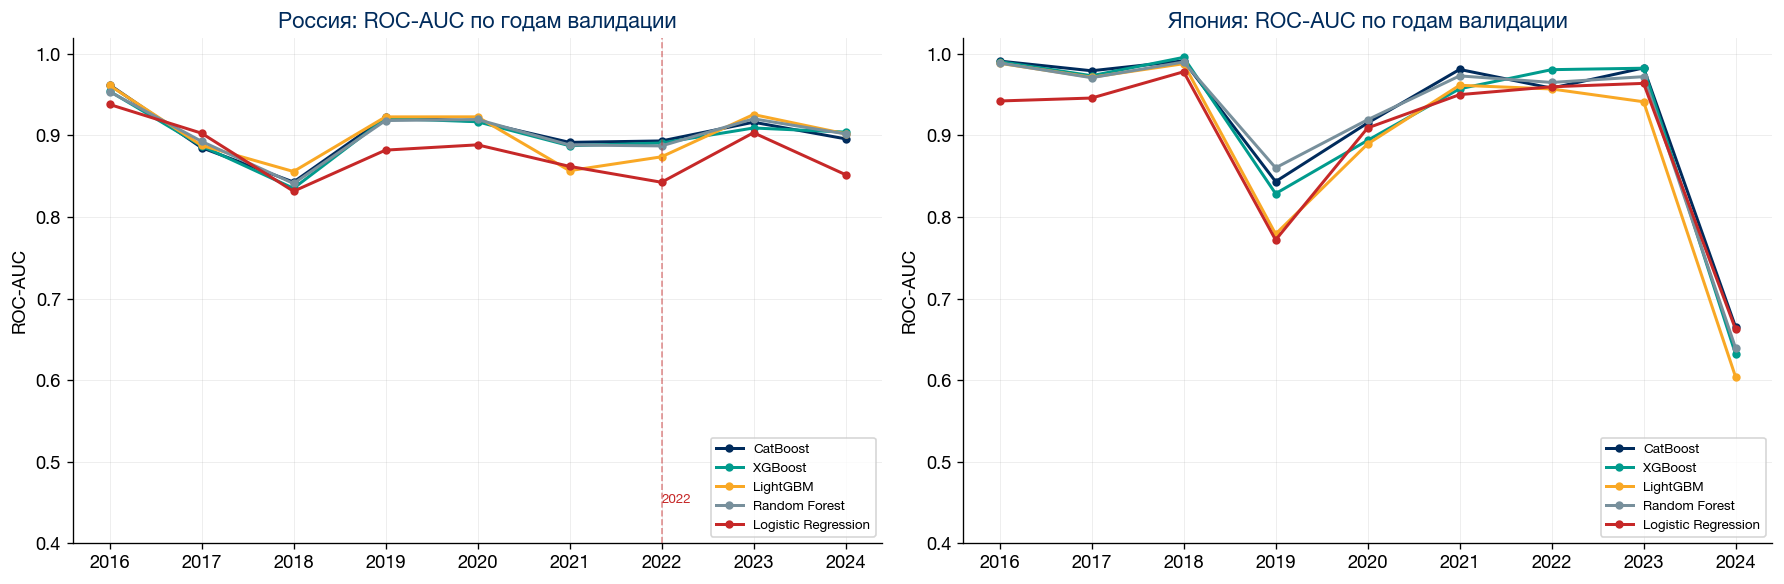

Модель,Страна,Median AUC,Mean OOF AUC,95% Block Bootstrap CI,IQR по годам
CatBoost,Россия,0.896,0.899,"[0.880, 0.916]","[0.892, 0.918]"
XGBoost,Россия,0.904,0.890,"[0.871, 0.908]","[0.887, 0.917]"
LightGBM,Россия,0.902,0.895,"[0.877, 0.912]","[0.874, 0.923]"
Random Forest,Россия,0.902,0.890,"[0.871, 0.907]","[0.888, 0.920]"
Logistic Regression,Россия,0.882,0.751,"[0.726, 0.773]","[0.852, 0.903]"
CatBoost,Япония,0.979,0.938,"[0.919, 0.954]","[0.915, 0.983]"
XGBoost,Япония,0.973,0.824,"[0.761, 0.876]","[0.894, 0.982]"
LightGBM,Япония,0.957,0.911,"[0.883, 0.936]","[0.890, 0.971]"
Random Forest,Япония,0.971,0.857,"[0.809, 0.900]","[0.919, 0.973]"
Logistic Regression,Япония,0.946,0.747,"[0.690, 0.798]","[0.909, 0.960]"



────────────────────────────────────────────────── Россия: Ablation with XGBoost ──────────────────────────────────────────────────
  Set A (146 feats): ROC-AUC=0.904, PR-AUC=0.898 (28s)
  Set B (142 feats): ROC-AUC=0.891, PR-AUC=0.881 (34s)
  Set C (  6 feats): ROC-AUC=0.887, PR-AUC=0.868 (15s)
  Set D (  4 feats): ROC-AUC=0.900, PR-AUC=0.855 (13s)

────────────────────────────────────────────────── Япония: Ablation with CatBoost ──────────────────────────────────────────────────
  Set A (116 feats): ROC-AUC=0.979, PR-AUC=0.999 (81s)
  Set B (113 feats): ROC-AUC=0.959, PR-AUC=0.998 (68s)
  Set C (  6 feats): ROC-AUC=0.897, PR-AUC=0.991 (17s)
  Set D (  3 feats): ROC-AUC=0.909, PR-AUC=0.995 (5s)


Страна,Набор,# Призн.,ROC-AUC,PR-AUC,Spearman
Россия,Set A,146,0.904,0.898,0.912
Россия,Set B,142,0.891,0.881,0.905
Россия,Set C,6,0.887,0.868,0.590
Россия,Set D,4,0.900,0.855,0.107
Япония,Set A,116,0.979,0.999,0.883
Япония,Set B,113,0.959,0.998,0.886
Япония,Set C,6,0.897,0.991,0.296
Япония,Set D,3,0.909,0.995,0.189



Ablation decomposition:
  Россия:
    A−B (вклад div history при наличии фунд.): +0.013
    C−D (вклад категориальных внутри div-only): -0.013
    A−C (вклад фундаментальных при наличии div): +0.017
    A−D (вклад всего кроме чистой div history): +0.004
  Япония:
    A−B (вклад div history при наличии фунд.): +0.020
    C−D (вклад категориальных внутри div-only): -0.012
    A−C (вклад фундаментальных при наличии div): +0.083
    A−D (вклад всего кроме чистой div history): +0.070
A: Exclude 2022: ROC-AUC=0.900, PR-AUC=0.896, Brier=0.1252
B: Include 2022: ROC-AUC=0.894, PR-AUC=0.879, Brier=0.1274
C: Regime Dummy: ROC-AUC=0.897, PR-AUC=0.878, Brier=0.1269


Подход,Train N,Test N,ROC-AUC,PR-AUC,Brier
A: Exclude 2022,2030,477,0.900,0.896,0.1252
B: Include 2022,2258,477,0.894,0.879,0.1274
C: Regime Dummy,2258,477,0.897,0.878,0.1269


...

Модель,Страна,ROC-AUC
Global model,Россия,0.904
Sector sub-model,Россия,0.900
Global model,Япония,0.979
Sector sub-model,Япония,0.948


Fama-MacBeth Regression:
────────────────────────────────────────────────────────────
  Russia: OOF AUC = 0.905
  Japan:  OOF AUC = 0.913


Фактор,Коэфф.,t-stat (NW),p-value,Знач.
roe_pct,0.0171,4.95,0.000,***
net_debt_to_ebitda,-0.0174,-1.44,0.175,
div_streak,0.2715,6.60,0.000,***
log_market_cap,-0.0009,-0.03,0.974,
ebitda_margin_pct,0.0247,6.41,0.000,***
FCF,0.0046,0.74,0.470,
pe,0.0041,4088.45,0.000,***
key_rate_pct,0.0000,0.00,1.000,


Фактор,Коэфф.,t-stat (NW),p-value,Знач.
roe_pct,0.0433,5.54,0.000,***
debt_to_ebitda,0.0020,0.55,0.590,
div_streak,0.1177,5.13,0.000,***
log_market_cap,0.0267,9.23,0.000,***
ebitda_margin_pct,-0.0055,-1.12,0.283,
fcf_mln,-0.0053,-1.02,0.327,
pe,-0.0002,-0.04,0.970,
boj_rate_avg,0.0000,0.60,0.556,


Модель,Страна,ROC-AUC
ML (XGBoost),Россия,0.904
ML (Sector sub),Россия,0.900
Fama-MacBeth (LPM),Россия,0.905
3-Year Persistence,Россия,0.833
Naive Persistence,Россия,0.856
ML (CatBoost),Япония,0.979
ML (Sector sub),Япония,0.948
Fama-MacBeth (LPM),Япония,0.913
3-Year Persistence,Япония,0.798
Naive Persistence,Япония,0.866


In [6]:
# %%
# ══════════════════════════════════════════════════════════════
#  RUN ALL MODELS — WALK-FORWARD CV
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Запуск 5 моделей × 2 страны
#
# Для каждой модели выполняется expanding-window walk-forward CV
# с годами валидации от 2016 до предпоследнего года.
# Результаты сохраняются промежуточно для устойчивости к сбоям.

# %%
results_rf, results_jp = {}, {}
t_total = time.time()

for mn in MODEL_NAMES:
    print(f'\n{"="*60}  {DISPLAY_NAME[mn]}  {"="*60}')

    # ── Russia ──
    t0 = time.time()
    try:
        oof_r, met_r = walk_forward_cv(
            rf, rf_feats, rf_cats, RF_DPS_COL, RF_PRICE_COL,
            RF_FLAG_COL, 'RF', mn)
        results_rf[mn] = {'oof': oof_r, 'metrics': met_r}
        auc_r = met_r['clf_ROC_AUC'].median() if len(met_r) > 0 else np.nan
        brier_r = met_r['clf_Brier'].median() if len(met_r) > 0 else np.nan
        mae_r = met_r['reg_MAE'].median() if len(met_r) > 0 else np.nan
        print(f'  RF: ROC-AUC={auc_r:.3f}, Brier={brier_r:.4f}, '
              f'MAE={mae_r:.1f} ({time.time()-t0:.0f}s)')
        # Save intermediate
        oof_r.to_csv(f'{OUT_DIR}/oof_rf_{mn}.csv', index=False)
    except Exception as e:
        print(f'  ❌ RF {mn} FAILED: {e}')
        traceback.print_exc()
        results_rf[mn] = {'oof': pd.DataFrame(), 'metrics': pd.DataFrame()}

    # ── Japan ──
    t0 = time.time()
    try:
        oof_j, met_j = walk_forward_cv(
            jp, jp_feats, jp_cats, JP_DPS_COL, JP_PRICE_COL,
            JP_FLAG_COL, 'JP', mn)
        results_jp[mn] = {'oof': oof_j, 'metrics': met_j}
        auc_j = met_j['clf_ROC_AUC'].median() if len(met_j) > 0 else np.nan
        brier_j = met_j['clf_Brier'].median() if len(met_j) > 0 else np.nan
        mae_j = met_j['reg_MAE'].median() if len(met_j) > 0 else np.nan
        print(f'  JP: ROC-AUC={auc_j:.3f}, Brier={brier_j:.4f}, '
              f'MAE={mae_j:.1f} ({time.time()-t0:.0f}s)')
        oof_j.to_csv(f'{OUT_DIR}/oof_jp_{mn}.csv', index=False)
    except Exception as e:
        print(f'  ❌ JP {mn} FAILED: {e}')
        traceback.print_exc()
        results_jp[mn] = {'oof': pd.DataFrame(), 'metrics': pd.DataFrame()}

elapsed = time.time() - t_total
print(f'\n{"="*60}')
print(f'All models done in {elapsed:.0f}s ({elapsed/60:.1f} min)')

# ── Verify baselines are identical across models ──
print('\nBaseline consistency check:')
for country_label, results in [('RF', results_rf), ('JP', results_jp)]:
    bl_vals = set()
    for mn in MODEL_NAMES:
        mdf = results[mn]['metrics']
        if len(mdf) > 0:
            bl_vals.add(round(mdf['bl_3yr_AUC'].median(), 4))
    if len(bl_vals) <= 1:
        print(f'  {country_label}: ✅ 3-year baseline consistent: {bl_vals}')
    else:
        print(f'  {country_label}: ⚠️ baselines differ: {bl_vals}')

# %%
# ══════════════════════════════════════════════════════════════
#  RESULTS TABLES — CLASSIFICATION
# ══════════════════════════════════════════════════════════════

# ── Table 1: Classification comparison ──
comp_rows_clf = []
for mn in MODEL_NAMES:
    for country, results in [('Россия', results_rf), ('Япония', results_jp)]:
        mdf = results[mn]['metrics']
        if len(mdf) == 0:
            continue
        comp_rows_clf.append([
            DISPLAY_NAME[mn], country,
            f'{mdf["clf_ROC_AUC"].median():.3f}',
            f'{mdf["clf_PR_AUC"].median():.3f}',
            f'{mdf["clf_Brier"].median():.4f}',
            f'{mdf["bl_naive_AUC"].median():.3f}',
            f'{mdf["bl_3yr_AUC"].median():.3f}',
        ])

html = mckinsey_table(
    comp_rows_clf,
    ['Модель', 'Страна', 'ROC-AUC ↑', 'PR-AUC ↑', 'Brier ↓',
     'BL Naive', 'BL 3-Year'],
    'Таблица 1. Сравнение классификаторов (медиана walk-forward CV)',
    highlight_col=2, minimize_col=4)
display(HTML(html))

# ── Table 1b: Regression comparison ──
comp_rows_reg = []
for mn in MODEL_NAMES:
    for country, results in [('Россия', results_rf), ('Япония', results_jp)]:
        mdf = results[mn]['metrics']
        if len(mdf) == 0:
            continue
        mae = mdf['reg_MAE'].median()
        sp = mdf['reg_Spearman'].median()
        comp_rows_reg.append([
            DISPLAY_NAME[mn], country,
            f'{mae:.1f}' if np.isfinite(mae) else 'N/A',
            f'{sp:.3f}' if np.isfinite(sp) else 'N/A',
        ])

html = mckinsey_table(
    comp_rows_reg,
    ['Модель', 'Страна', 'MAE (DPS) ↓', 'Spearman ρ ↑'],
    'Таблица 1b. Качество регрессии DPS (только плательщики)',
    minimize_col=2, highlight_col=3)
display(HTML(html))

# %%
# ── Select best model and top-3 ──
def select_best(all_res):
    scores = {}
    for mn, r in all_res.items():
        mdf = r['metrics']
        if len(mdf) == 0:
            continue
        auc = mdf['clf_ROC_AUC'].median()
        if np.isfinite(auc):
            scores[mn] = auc
    return max(scores, key=scores.get) if scores else MODEL_NAMES[0]

def top3_models(all_res):
    scores = {}
    for mn, r in all_res.items():
        mdf = r['metrics']
        if len(mdf) == 0:
            continue
        auc = mdf['clf_ROC_AUC'].median()
        if np.isfinite(auc):
            scores[mn] = auc
    return sorted(scores, key=scores.get, reverse=True)[:3]

best_rf = select_best(results_rf)
best_jp = select_best(results_jp)
top3_rf = top3_models(results_rf)
top3_jp = top3_models(results_jp)

auc_best_rf = results_rf[best_rf]['metrics']['clf_ROC_AUC'].median()
auc_best_jp = results_jp[best_jp]['metrics']['clf_ROC_AUC'].median()
bl3_rf = results_rf[best_rf]['metrics']['bl_3yr_AUC'].median()
bl3_jp = results_jp[best_jp]['metrics']['bl_3yr_AUC'].median()
bln_rf = results_rf[best_rf]['metrics']['bl_naive_AUC'].median()
bln_jp = results_jp[best_jp]['metrics']['bl_naive_AUC'].median()

print(f'Best RF: {DISPLAY_NAME[best_rf]} (ROC-AUC={auc_best_rf:.3f})')
print(f'Best JP: {DISPLAY_NAME[best_jp]} (ROC-AUC={auc_best_jp:.3f})')
print(f'Top-3 RF: {[DISPLAY_NAME[m] for m in top3_rf]}')
print(f'Top-3 JP: {[DISPLAY_NAME[m] for m in top3_jp]}')
print(f'\nLift over 3-year baseline:')
print(f'  RF: {auc_best_rf:.3f} − {bl3_rf:.3f} = +{auc_best_rf - bl3_rf:.3f}')
print(f'  JP: {auc_best_jp:.3f} − {bl3_jp:.3f} = +{auc_best_jp - bl3_jp:.3f}')
print(f'Lift over naive baseline:')
print(f'  RF: {auc_best_rf:.3f} − {bln_rf:.3f} = +{auc_best_rf - bln_rf:.3f}')
print(f'  JP: {auc_best_jp:.3f} − {bln_jp:.3f} = +{auc_best_jp - bln_jp:.3f}')

# %%
# ══════════════════════════════════════════════════════════════
#  ROC-AUC BY YEAR — TEMPORAL STABILITY
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (results, country) in zip(axes,
        [(results_rf, 'Россия'), (results_jp, 'Япония')]):
    for mn in MODEL_NAMES:
        mdf = results[mn]['metrics']
        if len(mdf) == 0:
            continue
        ax.plot(mdf['year'], mdf['clf_ROC_AUC'], marker='o', markersize=4,
                label=DISPLAY_NAME[mn], color=MODEL_COLORS.get(mn, GRAY),
                linewidth=1.8)
    ax.set_title(f'{country}: ROC-AUC по годам валидации',
                 fontsize=13, fontweight='bold', color=NAVY)
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0.4, 1.02)
    ax.legend(fontsize=8, loc='lower right')
    if country == 'Россия':
        ax.axvline(x=2022, color=CRIMSON, ls='--', alpha=0.5, lw=1)
        ax.annotate('2022', xy=(2022, 0.45), fontsize=8, color=CRIMSON)

plt.tight_layout()
save_fig('fig_roc_auc_by_year')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BOOTSTRAP CONFIDENCE INTERVALS (BLOCK BOOTSTRAP BY TICKER)
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Block bootstrap
#
# Стандартный i.i.d. bootstrap некорректен для панельных данных,
# т.к. наблюдения одного тикера коррелированы во времени.
#
# Применяем **block bootstrap по тикерам**: на каждой итерации
# ресемплируем с возвращением множество тикеров,
# затем берём все OOF-наблюдения выбранных тикеров.
#
# Полученные интервалы — **эмпирические оценки устойчивости**,
# а не строгие асимптотические доверительные интервалы.

# %%
def bootstrap_auc_block(oof_df, n_boot=N_BOOT, alpha=0.05, seed=SEED):
    """Block bootstrap CI for ROC-AUC, resampling by ticker."""
    paid = oof_df['paid_next'].values
    phat = oof_df['p_hat'].values
    tickers = oof_df['ticker'].values

    if len(np.unique(paid)) < 2:
        return np.nan, np.nan, np.nan

    unique_tickers = np.unique(tickers)
    n_tickers = len(unique_tickers)

    # Pre-compute ticker → index mapping for speed
    ticker_idx = {}
    for i, tk in enumerate(tickers):
        ticker_idx.setdefault(tk, []).append(i)

    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(unique_tickers, n_tickers, replace=True)
        idx = []
        for tk in sampled:
            idx.extend(ticker_idx[tk])
        idx = np.array(idx)
        if len(np.unique(paid[idx])) < 2:
            continue
        aucs.append(roc_auc_score(paid[idx], phat[idx]))

    if len(aucs) < 50:
        return np.nan, np.nan, np.nan

    return (np.mean(aucs),
            np.percentile(aucs, alpha / 2 * 100),
            np.percentile(aucs, (1 - alpha / 2) * 100))

# Compute bootstrap CI for all models
ci_rows = []
for country_label, results in [('Россия', results_rf), ('Япония', results_jp)]:
    for mn in MODEL_NAMES:
        oof = results[mn]['oof']
        if len(oof) == 0:
            continue
        mean_auc, lo, hi = bootstrap_auc_block(oof)
        mdf = results[mn]['metrics']
        median_auc = mdf['clf_ROC_AUC'].median() if len(mdf) > 0 else np.nan
        std_auc = mdf['clf_ROC_AUC'].std() if len(mdf) > 1 else np.nan
        iqr_lo = mdf['clf_ROC_AUC'].quantile(0.25) if len(mdf) > 1 else np.nan
        iqr_hi = mdf['clf_ROC_AUC'].quantile(0.75) if len(mdf) > 1 else np.nan
        ci_rows.append([
            DISPLAY_NAME[mn], country_label,
            f'{median_auc:.3f}' if np.isfinite(median_auc) else 'N/A',
            f'{mean_auc:.3f}' if np.isfinite(mean_auc) else 'N/A',
            f'[{lo:.3f}, {hi:.3f}]' if np.isfinite(lo) else 'N/A',
            f'[{iqr_lo:.3f}, {iqr_hi:.3f}]' if np.isfinite(iqr_lo) else 'N/A',
        ])

html = mckinsey_table(
    ci_rows,
    ['Модель', 'Страна', 'Median AUC', 'Mean OOF AUC',
     '95% Block Bootstrap CI', 'IQR по годам'],
    'Таблица 2. Bootstrap доверительные интервалы ROC-AUC '
    '(block bootstrap по тикерам)',
    highlight_col=2)
display(HTML(html))

# %%
# ══════════════════════════════════════════════════════════════
#  FEATURE ABLATION — A/B/C/D SETS
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Ablation study
#
# Наборы: A=все, B=без дивидендной истории, C=история+категориальные, D=только история

# %%
ablation_results = {}

for country, df_c, abc, cat_feats, dps_col, price_col, flag_col, best_mn in [
    ('RF', rf, rf_abc, rf_cats, RF_DPS_COL, RF_PRICE_COL, RF_FLAG_COL, best_rf),
    ('JP', jp, jp_abc, jp_cats, JP_DPS_COL, JP_PRICE_COL, JP_FLAG_COL, best_jp),
]:
    cn = 'Россия' if country == 'RF' else 'Япония'
    print(f'\n{"─"*50} {cn}: Ablation with {DISPLAY_NAME[best_mn]} {"─"*50}')

    for sname in ['A', 'B', 'C', 'D']:
        sfeats = abc[sname]
        if len(sfeats) < 2:
            print(f'  Set {sname}: too few features ({len(sfeats)}), skipping')
            ablation_results[(country, sname)] = {
                'n_feats': len(sfeats), 'ROC-AUC': np.nan,
                'PR-AUC': np.nan, 'Spearman': np.nan}
            continue
        s_cats = [c for c in cat_feats if c in sfeats]
        t0 = time.time()
        _, met = walk_forward_cv(df_c, sfeats, s_cats, dps_col, price_col,
                                 flag_col, country, best_mn)
        auc = met['clf_ROC_AUC'].median() if len(met) > 0 else np.nan
        prauc = met['clf_PR_AUC'].median() if len(met) > 0 else np.nan
        sp = (met['reg_Spearman'].median()
              if len(met) > 0 and 'reg_Spearman' in met else np.nan)
        ablation_results[(country, sname)] = {
            'n_feats': len(sfeats), 'ROC-AUC': auc,
            'PR-AUC': prauc, 'Spearman': sp}
        print(f'  Set {sname} ({len(sfeats):3d} feats): '
              f'ROC-AUC={auc:.3f}, PR-AUC={prauc:.3f} ({time.time()-t0:.0f}s)')

# Display ablation table
abl_rows = []
for country in ['RF', 'JP']:
    cn = 'Россия' if country == 'RF' else 'Япония'
    for sn in ['A', 'B', 'C', 'D']:
        r = ablation_results.get((country, sn))
        if r is None:
            continue
        abl_rows.append([
            cn, f'Set {sn}', str(r['n_feats']),
            f'{r["ROC-AUC"]:.3f}' if np.isfinite(r['ROC-AUC']) else 'N/A',
            f'{r["PR-AUC"]:.3f}' if np.isfinite(r['PR-AUC']) else 'N/A',
            f'{r["Spearman"]:.3f}' if np.isfinite(r['Spearman']) else 'N/A',
        ])

html = mckinsey_table(
    abl_rows,
    ['Страна', 'Набор', '# Призн.', 'ROC-AUC', 'PR-AUC', 'Spearman'],
    'Таблица 3. Feature Ablation: вклад дивидендной истории (A/B/C/D)',
    highlight_col=3)
display(HTML(html))

# ── Ablation decomposition ──
print('\nAblation decomposition:')
for country in ['RF', 'JP']:
    cn = 'Россия' if country == 'RF' else 'Япония'
    a = ablation_results.get((country, 'A'), {}).get('ROC-AUC', np.nan)
    b = ablation_results.get((country, 'B'), {}).get('ROC-AUC', np.nan)
    c = ablation_results.get((country, 'C'), {}).get('ROC-AUC', np.nan)
    d = ablation_results.get((country, 'D'), {}).get('ROC-AUC', np.nan)
    print(f'  {cn}:')
    print(f'    A−B (вклад div history при наличии фунд.): '
          f'{a - b:+.3f}' if np.isfinite(a - b) else '    A−B: N/A')
    print(f'    C−D (вклад категориальных внутри div-only): '
          f'{c - d:+.3f}' if np.isfinite(c - d) else '    C−D: N/A')
    print(f'    A−C (вклад фундаментальных при наличии div): '
          f'{a - c:+.3f}' if np.isfinite(a - c) else '    A−C: N/A')
    print(f'    A−D (вклад всего кроме чистой div history): '
          f'{a - d:+.3f}' if np.isfinite(a - d) else '    A−D: N/A')

# %%
# ══════════════════════════════════════════════════════════════
#  STRUCTURAL BREAK 2022 (RUSSIA)
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Анализ структурного сдвига 2022
#
# Три подхода:
# - **A:** Обучение без 2022 года
# - **B:** С включением 2022 года
# - **C:** С включением 2022 + флаг санкционного режима
#
# Тест на 2023–2024. Если разница между A, B, C пренебрежима
# (< bootstrap CI width), делаем вывод об устойчивости модели.

# %%
sb_results = {}
sb_predictions = {}  # for statistical test

for sb_name, train_filter, test_filter, extra_feat in [
    ('A: Exclude 2022',
     lambda d: d['year'] <= 2021,
     lambda d: d['year'].isin([2023, 2024]), None),
    ('B: Include 2022',
     lambda d: d['year'] <= 2022,
     lambda d: d['year'].isin([2023, 2024]), None),
    ('C: Regime Dummy',
     lambda d: d['year'] <= 2022,
     lambda d: d['year'].isin([2023, 2024]), 'post_2022'),
]:
    rf_sb = rf.copy()
    feats_sb = list(rf_feats)
    if extra_feat:
        rf_sb['post_2022'] = (rf_sb['year'] >= 2022).astype(float)
        if 'post_2022' not in feats_sb:
            feats_sb = feats_sb + ['post_2022']

    trn = rf_sb[train_filter(rf_sb) & (rf_sb['label_known_paid'] == 1)].copy()
    tst = rf_sb[test_filter(rf_sb) & (rf_sb['label_known_paid'] == 1)].copy()

    if len(trn) < 50 or len(tst) < 5:
        print(f'{sb_name}: insufficient data (train={len(trn)}, test={len(tst)})')
        continue

    for c in rf_cats:
        trn[c] = safe_cat(trn[c])
        tst[c] = safe_cat(tst[c])

    cat_idx = [feats_sb.index(c) for c in rf_cats if c in feats_sb]
    model_sb = MultiModelZI(best_rf, seed=SEED)
    model_sb.fit(trn[feats_sb], trn['paid_next'].astype(int).values,
                 trn['dps_next'].fillna(0).values,
                 cat_feats=rf_cats, cat_idx=cat_idx)
    p_hat_sb, _ = model_sb.predict(tst[feats_sb], cat_feats=rf_cats,
                                    cat_idx=cat_idx)
    paid_tst = tst['paid_next'].astype(int).values

    auc = (roc_auc_score(paid_tst, p_hat_sb)
           if len(np.unique(paid_tst)) > 1 else np.nan)
    pr_auc = (average_precision_score(paid_tst, p_hat_sb)
              if len(np.unique(paid_tst)) > 1 else np.nan)
    brier = brier_score_loss(paid_tst, p_hat_sb)

    sb_results[sb_name] = {
        'ROC-AUC': auc, 'PR-AUC': pr_auc, 'Brier': brier,
        'Train': len(trn), 'Test': len(tst)}
    sb_predictions[sb_name] = (paid_tst, p_hat_sb)
    print(f'{sb_name}: ROC-AUC={auc:.3f}, PR-AUC={pr_auc:.3f}, '
          f'Brier={brier:.4f}')

# Display
sb_rows = [
    [k, str(v['Train']), str(v['Test']),
     f'{v["ROC-AUC"]:.3f}', f'{v["PR-AUC"]:.3f}', f'{v["Brier"]:.4f}']
    for k, v in sb_results.items()
]
html = mckinsey_table(
    sb_rows,
    ['Подход', 'Train N', 'Test N', 'ROC-AUC', 'PR-AUC', 'Brier'],
    'Таблица 4. Структурный сдвиг 2022: три подхода (Россия)',
    highlight_col=3, minimize_col=5)
display(HTML(html))

# ── Simple permutation test: A vs B ──
if 'A: Exclude 2022' in sb_predictions and 'B: Include 2022' in sb_predictions:
    y_true_a, p_a = sb_predictions['A: Exclude 2022']
    _, p_b = sb_predictions['B: Include 2022']
    observed_diff = roc_auc_score(y_true_a, p_a) - roc_auc_score(y_true_a, p_b)
    rng = np.random.RandomState(SEED)
    n_perm = 1000
    count = 0
    for _ in range(n_perm):
        swap = rng.random(len(p_a)) > 0.5
        p_mix_a = np.where(swap, p_b, p_a)
        p_mix_b = np.where(swap, p_a, p_b)
        if (len(np.unique(y_true_a)) > 1):
            diff = (roc_auc_score(y_true_a, p_mix_a) -
                    roc_auc_score(y_true_a, p_mix_b))
            if abs(diff) >= abs(observed_diff):
                count += 1
    p_value = count / n_perm
    print(f'\nPermutation test A vs B: observed diff={observed_diff:+.4f}, '
          f'p-value={p_value:.3f}')
    if p_value > 0.05:
        print('  → Разница статистически НЕ значима (p > 0.05)')
    else:
        print('  → Разница статистически значима (p ≤ 0.05)')

# %%
# ══════════════════════════════════════════════════════════════
#  SECTOR ANALYSIS & SUB-MODELS
# ══════════════════════════════════════════════════════════════

# ── Sector-level AUC breakdown ──
def sector_analysis(results, df, best_mn, country_label):
    oof = results[best_mn]['oof']
    if len(oof) == 0:
        return pd.DataFrame()
    merged = oof.merge(
        df[['ticker', 'year', 'sector']].drop_duplicates(),
        on=['ticker', 'year'], how='left')
    rows = []
    for sec, grp in merged.groupby('sector'):
        if len(grp) < 20 or len(grp['paid_next'].unique()) < 2:
            continue
        auc = roc_auc_score(grp['paid_next'], grp['p_hat'])
        rows.append({
            'Сектор': str(sec)[:35], 'N': len(grp),
            'Paid Rate': f'{grp["paid_next"].mean():.0%}',
            'ROC-AUC': f'{auc:.3f}'})
    return pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False)

for country_label, results, df_c, best_mn, title in [
    ('RF', results_rf, rf, best_rf, 'Таблица 4a. Секторный анализ: Россия'),
    ('JP', results_jp, jp, best_jp, 'Таблица 4b. Секторный анализ: Япония'),
]:
    sec_df = sector_analysis(results, df_c, best_mn, country_label)
    if len(sec_df) > 0:
        sec_rows = [[r['Сектор'], str(r['N']), r['Paid Rate'], r['ROC-AUC']]
                     for _, r in sec_df.iterrows()]
        html = mckinsey_table(
            sec_rows, ['Сектор', 'N', 'Paid Rate', 'ROC-AUC'],
            title, highlight_col=3)
        display(HTML(html))

# ── Sector Sub-Models ──
def sector_submodel_cv(df, feats, cat_feats, dps_col, price_col, flag_col,
                       country, model_name, min_sector_train=50):
    """Walk-forward CV with sector-specific sub-models."""
    max_yr = df['year'].max()
    cat_idx = [feats.index(c) for c in cat_feats if c in feats]
    oof_rec, met_rec = [], []
    fallback_log = []

    for vy in range(CV_START_YEAR, max_yr):
        trn = df[(df['year'] <= vy - 1) &
                 (df['label_known_paid'] == 1)].copy()
        val = df[(df['year'] == vy) &
                 (df['label_known_paid'] == 1)].copy()
        if len(trn) < 50 or len(val) < 5:
            continue
        for c in cat_feats:
            trn[c] = safe_cat(trn[c])
            val[c] = safe_cat(val[c])

        # Global fallback model
        model_global = MultiModelZI(model_name, seed=SEED)
        model_global.fit(
            trn[feats], trn['paid_next'].astype(int).values,
            trn['dps_next'].fillna(0).values,
            cat_feats=cat_feats, cat_idx=cat_idx,
            X_val=val[feats].copy(),
            paid_val=val['paid_next'].astype(int).values,
            dps_val=val['dps_next'].fillna(0).values)

        p_hat_all = np.zeros(len(val))
        dps_hat_all = np.zeros(len(val))

        for sg in val['sector_group'].unique():
            sg_val_mask = val['sector_group'] == sg
            sg_trn = trn[trn['sector_group'] == sg]
            sg_val = val[sg_val_mask]

            used_sector_model = False
            if (len(sg_trn) >= min_sector_train and
                    len(sg_trn['paid_next'].unique()) > 1):
                try:
                    model_sec = MultiModelZI(model_name, seed=SEED)
                    model_sec.fit(
                        sg_trn[feats],
                        sg_trn['paid_next'].astype(int).values,
                        sg_trn['dps_next'].fillna(0).values,
                        cat_feats=cat_feats, cat_idx=cat_idx)
                    p_sec, dps_sec = model_sec.predict(
                        sg_val[feats], cat_feats=cat_feats, cat_idx=cat_idx)
                    p_hat_all[sg_val_mask.values] = p_sec
                    dps_hat_all[sg_val_mask.values] = dps_sec
                    used_sector_model = True
                except Exception as e:
                    fallback_log.append(f'Year {vy}, sector {sg}: {e}')

            if not used_sector_model:
                p_gl, dps_gl = model_global.predict(
                    sg_val[feats], cat_feats=cat_feats, cat_idx=cat_idx)
                p_hat_all[sg_val_mask.values] = p_gl
                dps_hat_all[sg_val_mask.values] = dps_gl

        # Metrics
        paid_va = val['paid_next'].values.astype(int)
        dps_va = val['dps_next'].fillna(0).values
        price_arr = (val[price_col].values if price_col in val.columns
                     else np.full(len(val), np.nan))
        price_safe = np.where(price_arr > 0, price_arr, np.nan)
        y_paid = np.clip(
            np.where(np.isfinite(price_safe),
                     100 * dps_hat_all / price_safe, np.nan),
            -YIELD_CAP, YIELD_CAP)
        y_hat_exp = np.clip(p_hat_all * y_paid, -YIELD_CAP, YIELD_CAP)
        y_true = (val['y_next_pct'].values if 'y_next_pct' in val.columns
                  else np.full(len(val), np.nan))
        label_yield = (val['label_known_yield'].values
                       if 'label_known_yield' in val.columns
                       else np.ones(len(val)))

        hist_3y = df[
            (df['year'] >= vy - 3) & (df['year'] <= vy - 1)
        ].groupby('ticker')[flag_col].mean()
        p_bl3 = val['ticker'].map(hist_3y).fillna(0.5).values
        bl_paid = val[dps_col].fillna(0).values
        p_bl = np.where(bl_paid > 0, 0.9, 0.1)

        mets = compute_metrics(paid_va, p_hat_all, dps_va, dps_hat_all,
                               y_true, y_hat_exp, label_yield, p_bl, p_bl3)
        mets['year'] = vy
        mets['n_val'] = len(val)
        met_rec.append(mets)

        for idx_i in range(len(val)):
            oof_rec.append({
                'ticker': val.iloc[idx_i]['ticker'], 'year': vy,
                'paid_next': paid_va[idx_i], 'dps_next': dps_va[idx_i],
                'p_hat': p_hat_all[idx_i], 'dps_hat': dps_hat_all[idx_i],
            })

    if fallback_log:
        print(f'  Sector fallback events: {len(fallback_log)}')
        for msg in fallback_log[:5]:
            print(f'    {msg}')

    return pd.DataFrame(oof_rec), pd.DataFrame(met_rec)

print('\nRunning sector sub-models...')
t0 = time.time()
_, met_sec_rf = sector_submodel_cv(
    rf, rf_feats, rf_cats, RF_DPS_COL, RF_PRICE_COL, RF_FLAG_COL,
    'RF', best_rf)
sec_auc_rf = met_sec_rf['clf_ROC_AUC'].median() if len(met_sec_rf) > 0 else np.nan
print(f'  RF sector-sub: {sec_auc_rf:.3f} vs global '
      f'{auc_best_rf:.3f} (Δ={sec_auc_rf - auc_best_rf:+.3f}) '
      f'[{time.time()-t0:.0f}s]')

t0 = time.time()
_, met_sec_jp = sector_submodel_cv(
    jp, jp_feats, jp_cats, JP_DPS_COL, JP_PRICE_COL, JP_FLAG_COL,
    'JP', best_jp)
sec_auc_jp = met_sec_jp['clf_ROC_AUC'].median() if len(met_sec_jp) > 0 else np.nan
print(f'  JP sector-sub: {sec_auc_jp:.3f} vs global '
      f'{auc_best_jp:.3f} (Δ={sec_auc_jp - auc_best_jp:+.3f}) '
      f'[{time.time()-t0:.0f}s]')

# Summary
sec_comp = [
    ['Global model', 'Россия', f'{auc_best_rf:.3f}'],
    ['Sector sub-model', 'Россия', f'{sec_auc_rf:.3f}'],
    ['Global model', 'Япония', f'{auc_best_jp:.3f}'],
    ['Sector sub-model', 'Япония', f'{sec_auc_jp:.3f}'],
]
html = mckinsey_table(
    sec_comp, ['Модель', 'Страна', 'ROC-AUC'],
    'Таблица 5. Global vs Sector Sub-Models', highlight_col=2)
display(HTML(html))

# %%
# ══════════════════════════════════════════════════════════════
#  FAMA-MACBETH CROSS-SECTIONAL REGRESSION
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Fama-MacBeth как академический бейзлайн
#
# Linear probability model (OLS для бинарной переменной paid_next)
# с кросс-секционной регрессией по годам.
#
# **Почему LPM, а не logit:** для FM-процедуры важна интерпретируемость
# коэффициентов как маржинальных эффектов. Logit усложняет агрегацию
# по годам. Предсказания обрезаются до [0, 1].
#
# Стандартные ошибки — Newey-West с 1 лагом.

# %%
def fama_macbeth(df, flag_col, factors, target='paid_next'):
    """Fama-MacBeth cross-sectional regressions."""
    labeled = df[df['label_known_paid'] == 1].copy()
    years = sorted(labeled['year'].unique())

    if len(years) < 3:
        return None, None, np.nan

    coeff_list, oof_fm = [], []

    for yr in years:
        cross = labeled[labeled['year'] == yr].copy()
        if len(cross) < 20:
            continue
        y = cross[target].astype(float).values
        avail = [f for f in factors if f in cross.columns]
        if len(avail) < 2:
            continue
        X = cross[avail].copy()
        # Fill with cross-sectional median (no look-ahead)
        X = X.fillna(X.median()).fillna(0).values
        # Standardize cross-section
        X_mean = X.mean(axis=0)
        X_std = X.std(axis=0) + 1e-12
        X_norm = (X - X_mean) / X_std
        X_aug = np.column_stack([np.ones(len(X_norm)), X_norm])

        try:
            beta = np.linalg.lstsq(X_aug, y, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        y_hat = X_aug @ beta
        coeff_list.append({
            'year': yr, 'intercept': beta[0],
            **{f: beta[i + 1] for i, f in enumerate(avail)}
        })
        for i, idx in enumerate(cross.index):
            oof_fm.append({
                'ticker': cross.loc[idx, 'ticker'], 'year': yr,
                'paid_next': y[i], 'p_hat_fm': np.clip(y_hat[i], 0, 1),
            })

    if len(coeff_list) < 3:
        return None, None, np.nan

    coeff_df = pd.DataFrame(coeff_list).set_index('year')
    oof_df = pd.DataFrame(oof_fm)

    # Newey-West standard errors (1 lag)
    T = len(coeff_df)
    fm_results = {}
    for col in coeff_df.columns:
        gamma = coeff_df[col].values
        gamma_bar = gamma.mean()
        residuals = gamma - gamma_bar
        var0 = np.sum(residuals ** 2) / T
        cov1 = np.sum(residuals[1:] * residuals[:-1]) / T
        nw_var = (var0 + 2 * cov1) / T
        nw_se = np.sqrt(max(nw_var, 1e-12))
        t_stat = gamma_bar / nw_se
        p_val = 2 * (1 - t_dist.cdf(abs(t_stat), df=T - 1))
        fm_results[col] = {
            'coeff': gamma_bar, 'se_nw': nw_se,
            't_stat': t_stat, 'p_val': p_val,
            'sig': ('***' if p_val < 0.01 else
                    '**' if p_val < 0.05 else
                    '*' if p_val < 0.10 else '')
        }

    auc_fm = np.nan
    if len(oof_df) > 0 and len(oof_df['paid_next'].unique()) > 1:
        auc_fm = roc_auc_score(oof_df['paid_next'].values,
                               oof_df['p_hat_fm'].values)

    return pd.DataFrame(fm_results).T, oof_df, auc_fm

FM_FACTORS_RF = ['roe_pct', 'net_debt_to_ebitda', 'div_streak',
                 'log_market_cap', 'ebitda_margin_pct', 'FCF', 'pe',
                 'key_rate_pct']
FM_FACTORS_JP = ['roe_pct', 'debt_to_ebitda', 'div_streak',
                 'log_market_cap', 'ebitda_margin_pct', 'fcf_mln', 'pe',
                 'boj_rate_avg']

print('Fama-MacBeth Regression:')
print('─' * 60)
fm_rf_res, fm_rf_oof, fm_rf_auc = fama_macbeth(rf, RF_FLAG_COL, FM_FACTORS_RF)
print(f'  Russia: OOF AUC = {fm_rf_auc:.3f}'
      if np.isfinite(fm_rf_auc) else '  Russia: insufficient data')
fm_jp_res, fm_jp_oof, fm_jp_auc = fama_macbeth(jp, JP_FLAG_COL, FM_FACTORS_JP)
print(f'  Japan:  OOF AUC = {fm_jp_auc:.3f}'
      if np.isfinite(fm_jp_auc) else '  Japan:  insufficient data')

# Display FM coefficients
for fm_res, title_suffix, auc_val in [
    (fm_rf_res, 'Россия', fm_rf_auc),
    (fm_jp_res, 'Япония', fm_jp_auc),
]:
    if fm_res is not None:
        fm_rows = []
        for factor, row in fm_res.iterrows():
            if factor == 'intercept':
                continue
            fm_rows.append([
                factor, f'{row["coeff"]:.4f}',
                f'{row["t_stat"]:.2f}', f'{row["p_val"]:.3f}', row['sig']])
        html = mckinsey_table(
            fm_rows,
            ['Фактор', 'Коэфф.', 't-stat (NW)', 'p-value', 'Знач.'],
            f'Таблица 6. Fama-MacBeth ({title_suffix}, '
            f'OOF AUC={auc_val:.3f})',
            highlight_col=2)
        display(HTML(html))

# ── Comprehensive comparison: ML vs FM vs Baselines ──
comp_all = []
for cn, results, best_mn, sec_auc, fm_auc in [
    ('Россия', results_rf, best_rf, sec_auc_rf, fm_rf_auc),
    ('Япония', results_jp, best_jp, sec_auc_jp, fm_jp_auc),
]:
    mdf = results[best_mn]['metrics']
    comp_all.extend([
        [f'ML ({DISPLAY_NAME[best_mn]})', cn,
         f'{mdf["clf_ROC_AUC"].median():.3f}'],
        ['ML (Sector sub)', cn, f'{sec_auc:.3f}'],
        ['Fama-MacBeth (LPM)', cn,
         f'{fm_auc:.3f}' if np.isfinite(fm_auc) else 'N/A'],
        ['3-Year Persistence', cn,
         f'{mdf["bl_3yr_AUC"].median():.3f}'],
        ['Naive Persistence', cn,
         f'{mdf["bl_naive_AUC"].median():.3f}'],
    ])

html = mckinsey_table(
    comp_all, ['Модель', 'Страна', 'ROC-AUC'],
    'Таблица 7. Сравнение всех подходов',
    highlight_col=2)
display(HTML(html))

Isotonic Calibration:
  RF: Brier 0.1270 → 0.1156 (Δ = +0.0114)
  JP: Brier 0.0650 → 0.0378 (Δ = +0.0273)


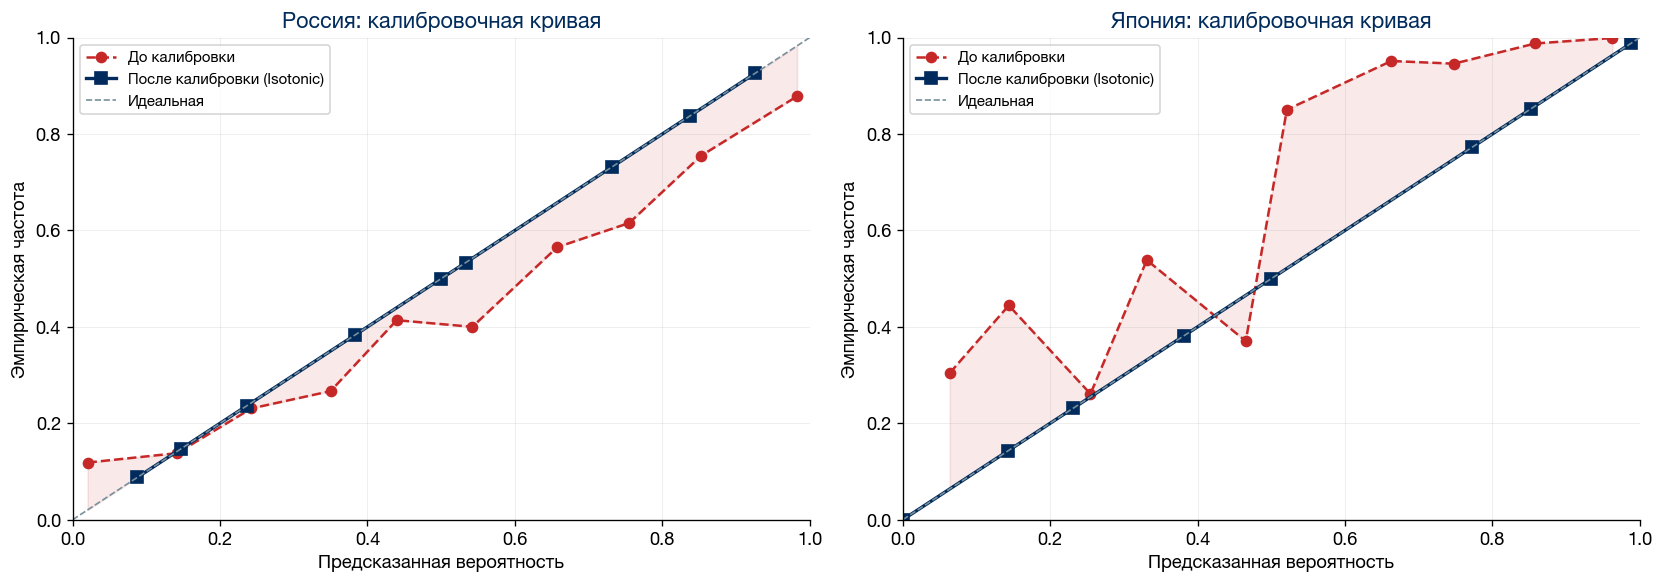

Quantile Regression (P10/P50/P90):
  RF: MAE(Q50)=128.33, empirical coverage=55.6%, median width=10.48 (22s)
  JP: MAE(Q50)=19.27, empirical coverage=56.7%, median width=21.24 (40s)


Страна,MAE (Q50),Empirical Coverage (Q10–Q90),Median Interval Width
Россия,128.33,55.6%,10.48
Япония,19.27,56.7%,21.24


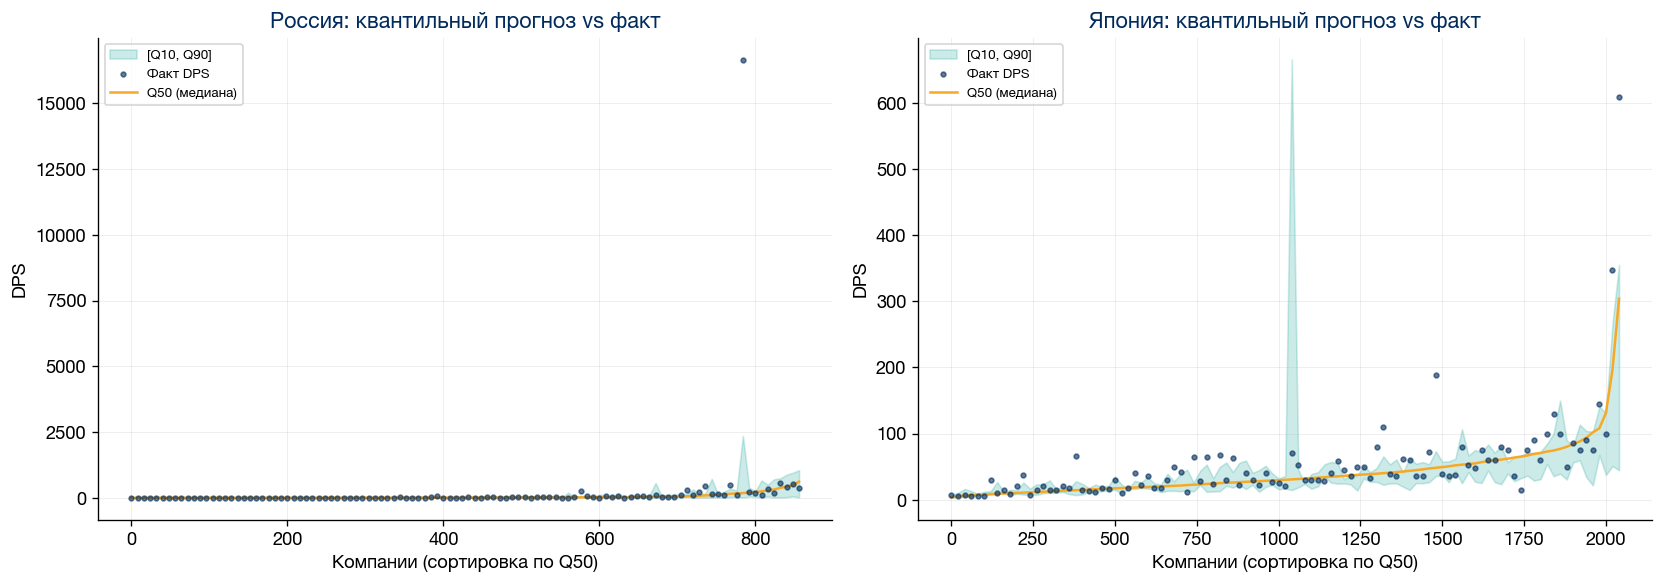

Computing SHAP values...


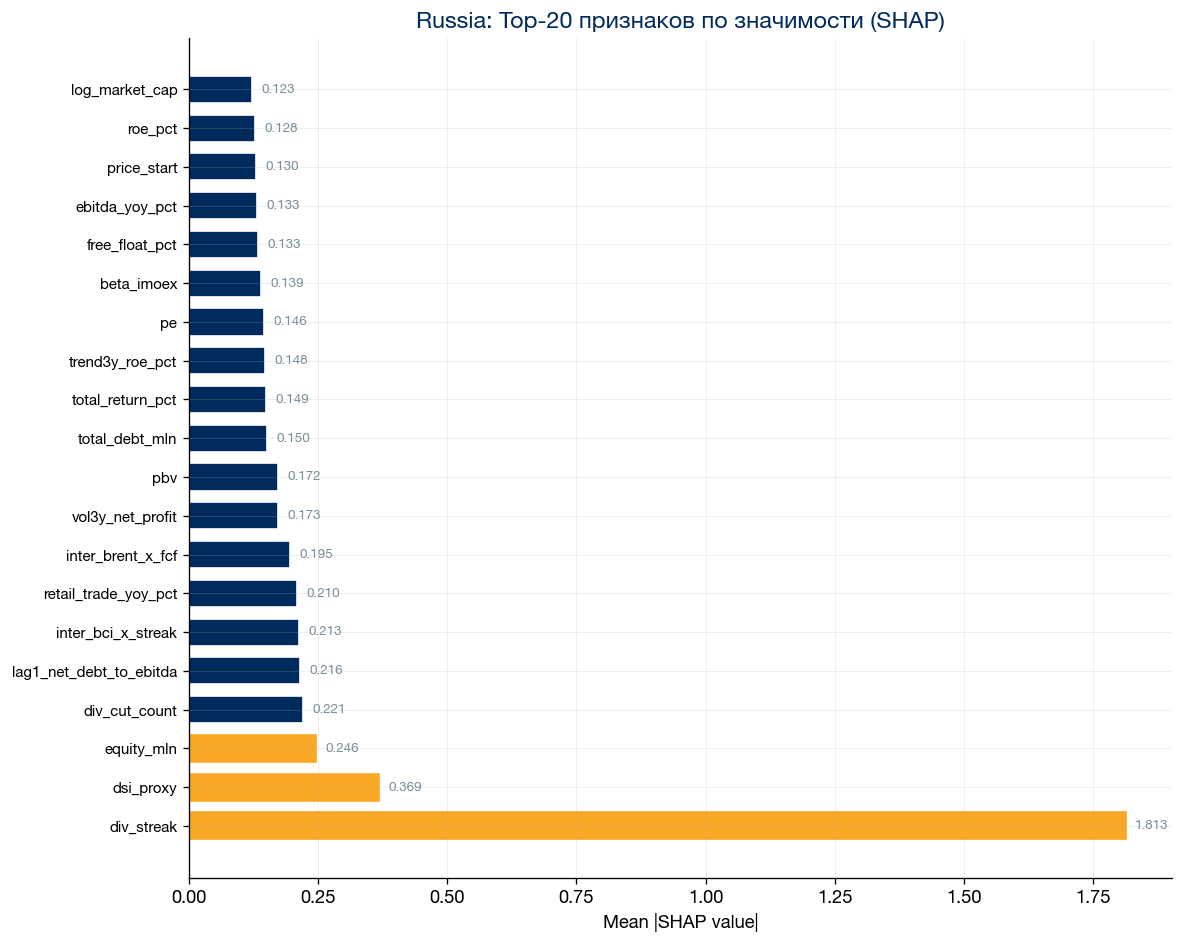

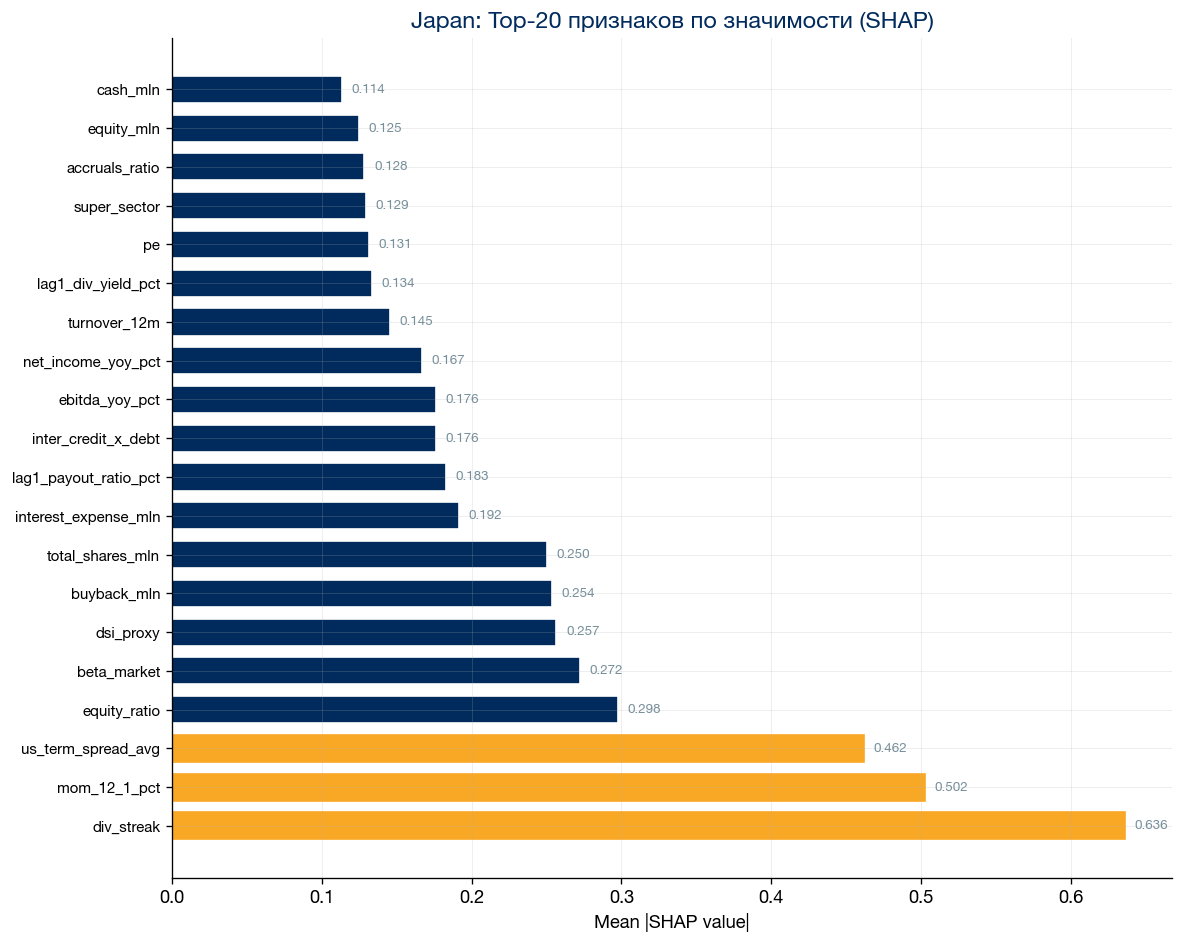

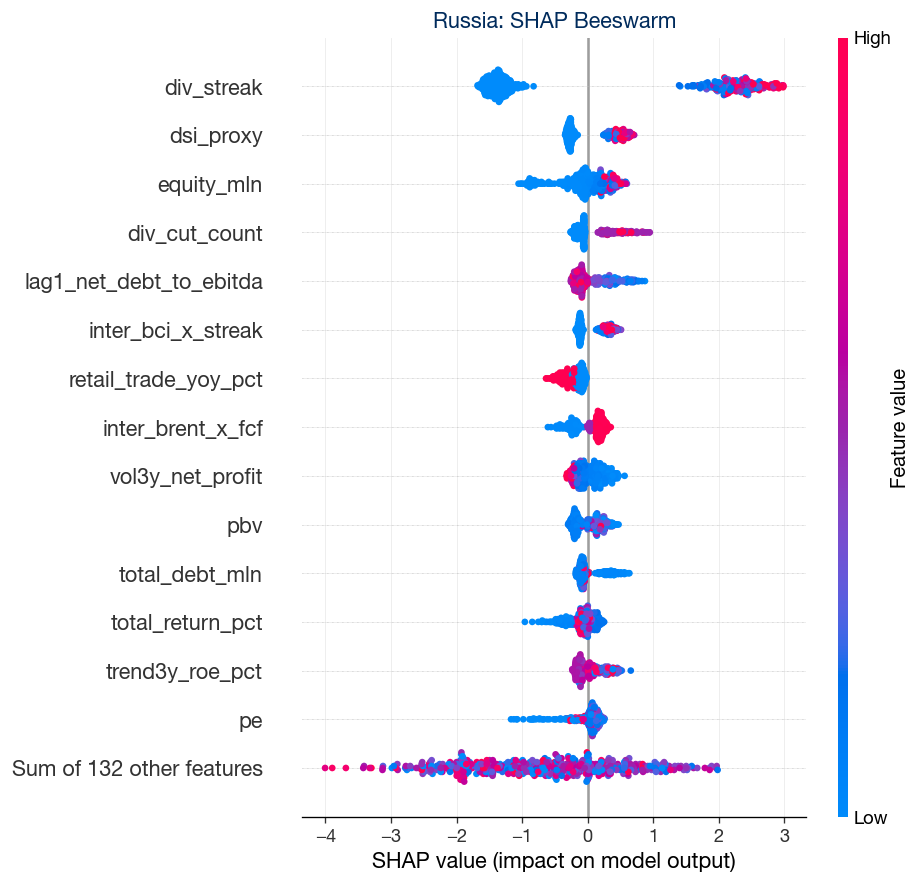

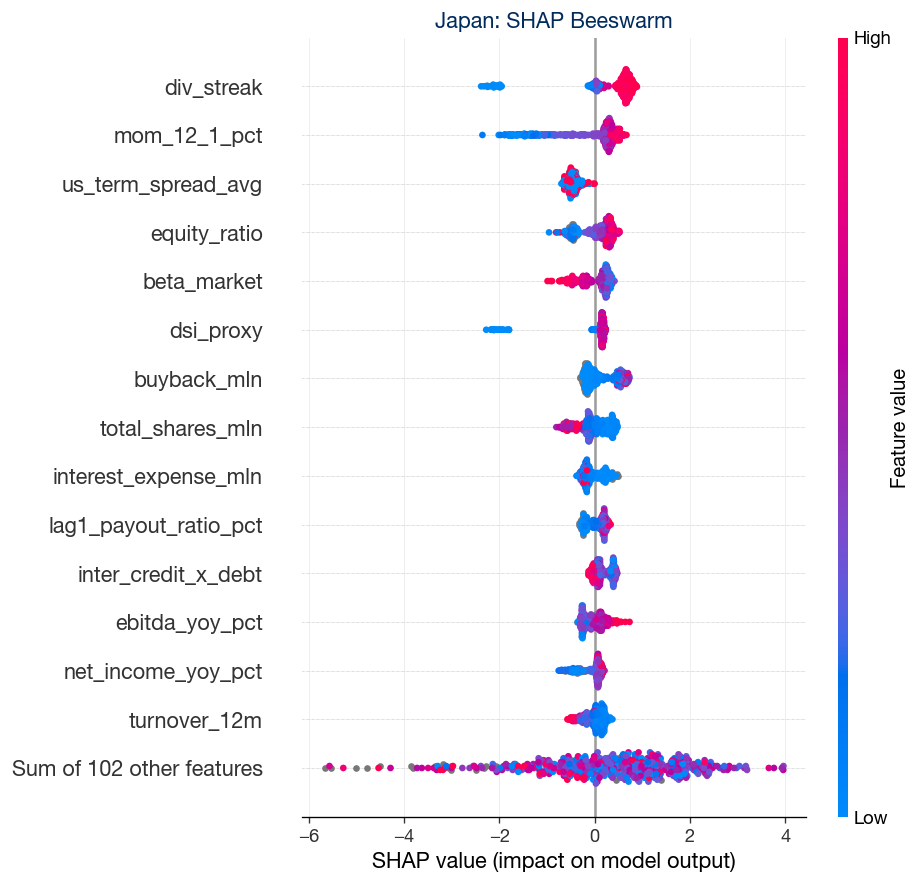

Building Decision Trees for interpretation...
────────────────────────────────────────────────────────────
  РОССИЯ:
  RF depth=2: CV AUC=0.8706 (±0.0159)
  RF depth=3: CV AUC=0.8842 (±0.0126)
  RF depth=4: CV AUC=0.8935 (±0.0182)
  RF depth=5: CV AUC=0.9010 (±0.0184)
  RF: best depth=5, CV AUC=0.9010, IS AUC=0.9276
  Top-5 features by information gain:
    dsi_proxy: 0.789 (78.9%)
    brent_usd: 0.038 (3.8%)
    div_cut_count: 0.031 (3.1%)
    inter_rate_x_roe: 0.031 (3.1%)
    corruption_rank: 0.029 (2.9%)
────────────────────────────────────────────────────────────
  ЯПОНИЯ:
  JP depth=2: CV AUC=0.8266 (±0.0320)
  JP depth=3: CV AUC=0.8442 (±0.0180)
  JP depth=4: CV AUC=0.8747 (±0.0454)
  JP depth=5: CV AUC=0.8720 (±0.0444)
  JP: best depth=4, CV AUC=0.8747, IS AUC=0.9385
  Top-5 features by information gain:
    div_streak: 0.582 (58.2%)
    mom_12_1_pct: 0.125 (12.5%)
    boj_rate_avg: 0.121 (12.1%)
    inter_fx_x_roe: 0.087 (8.7%)
    topix_ret_yr: 0.038 (3.8%)


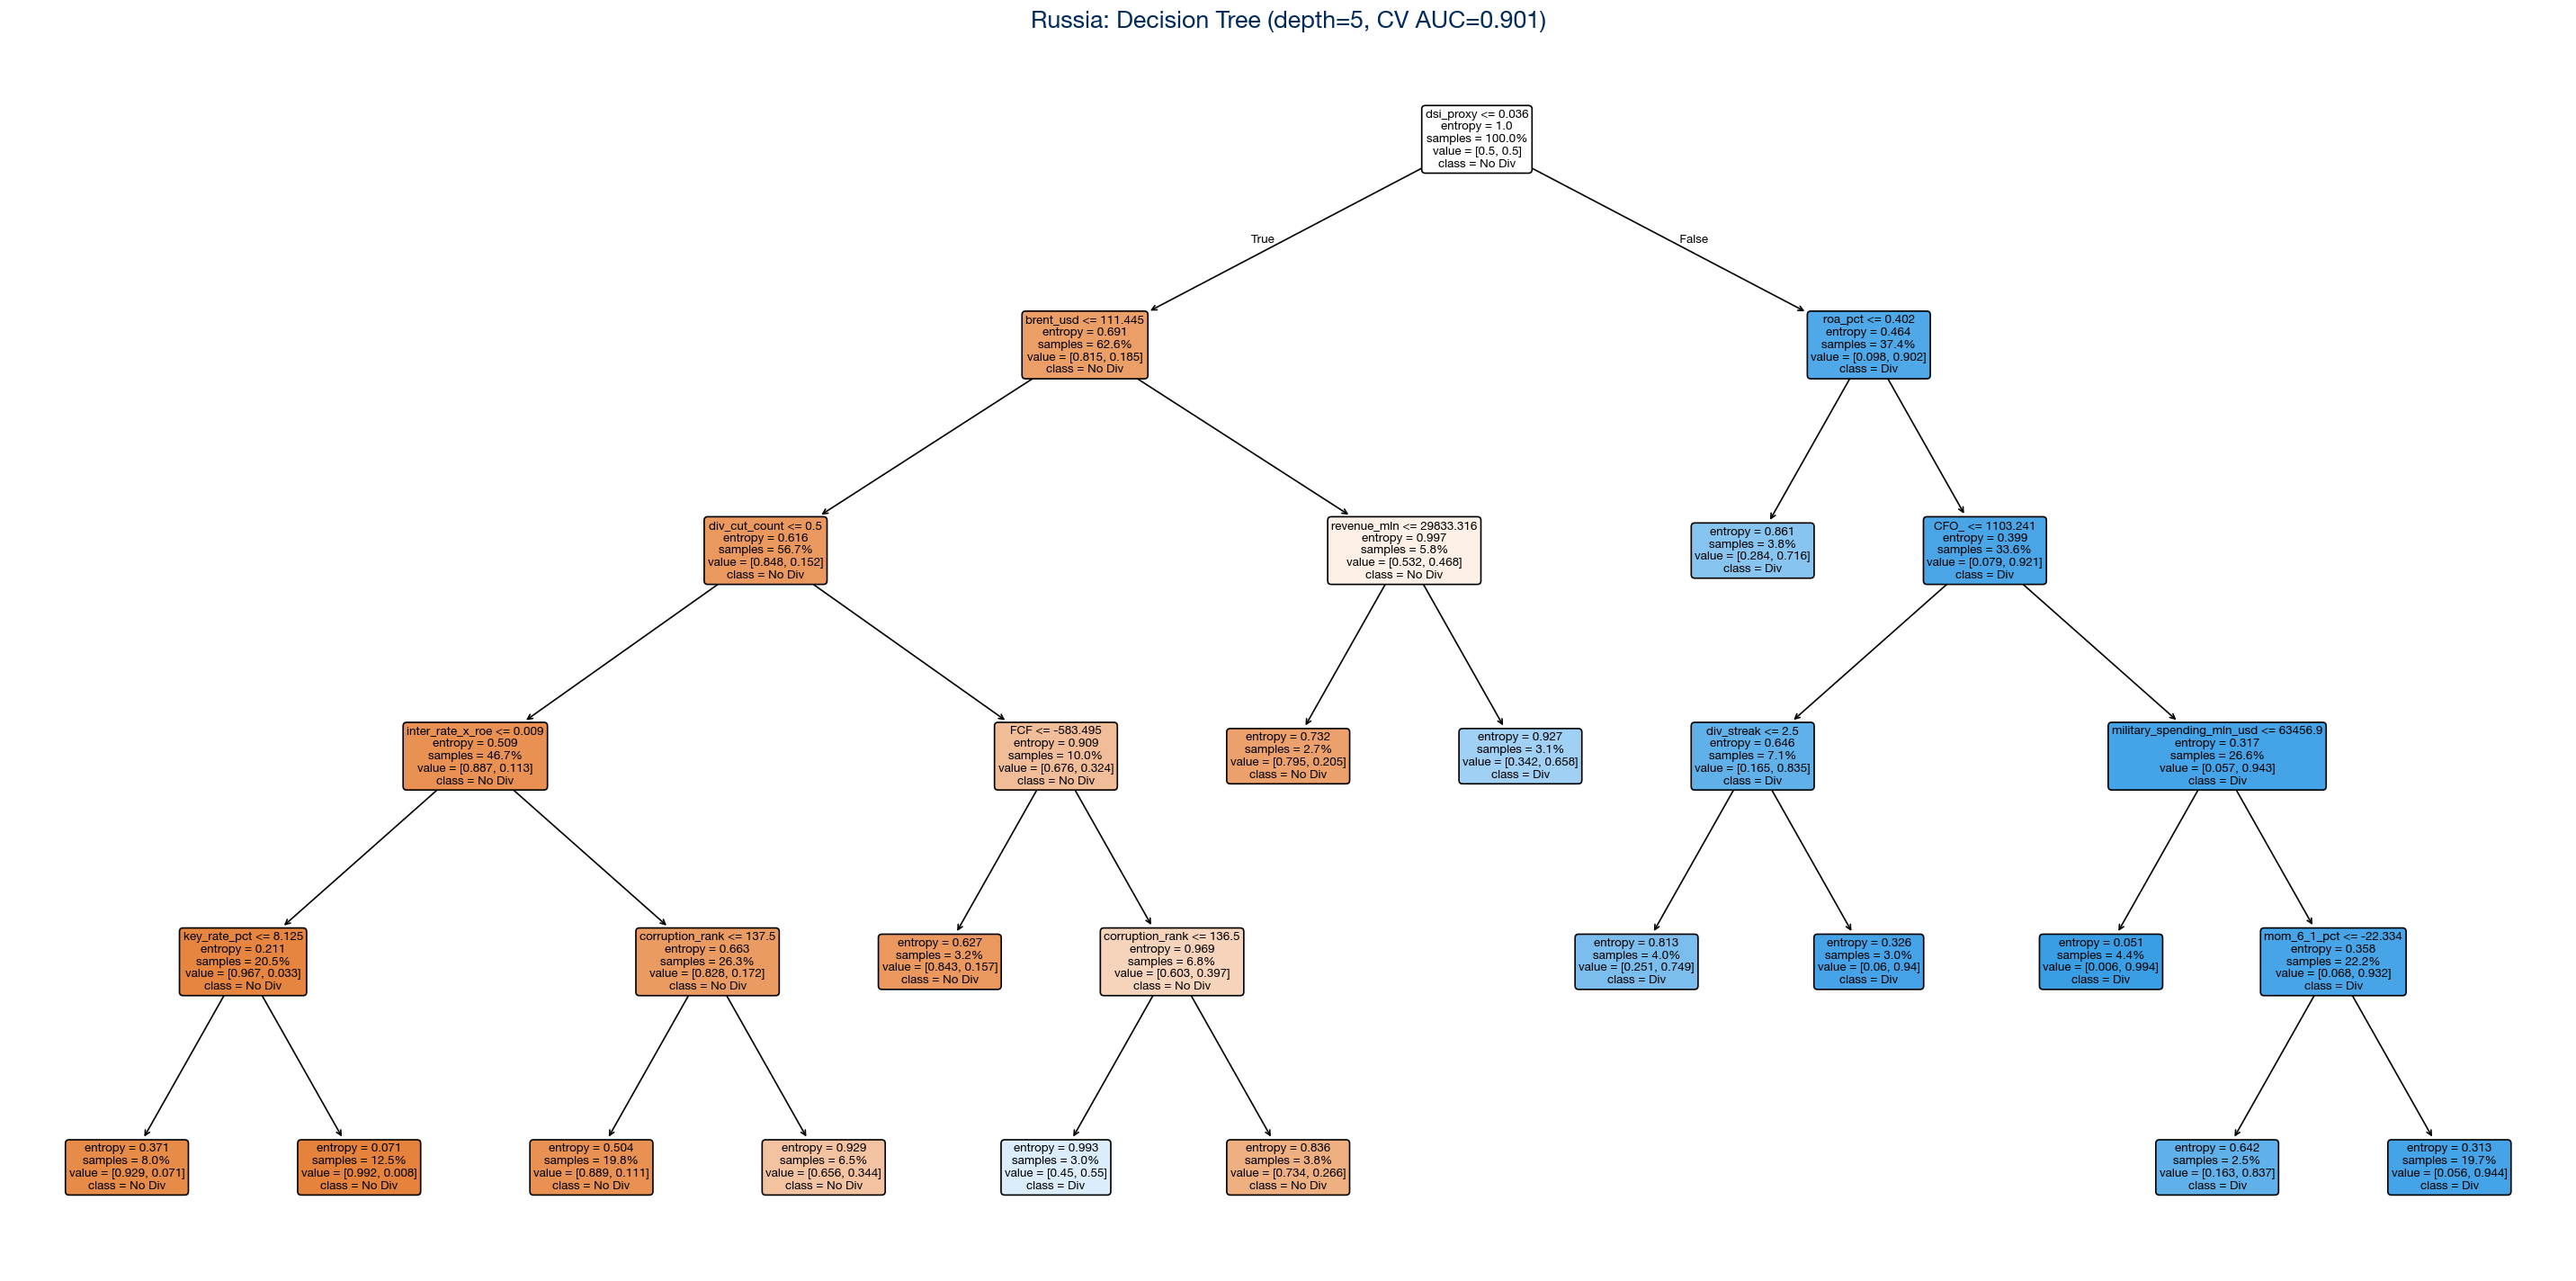

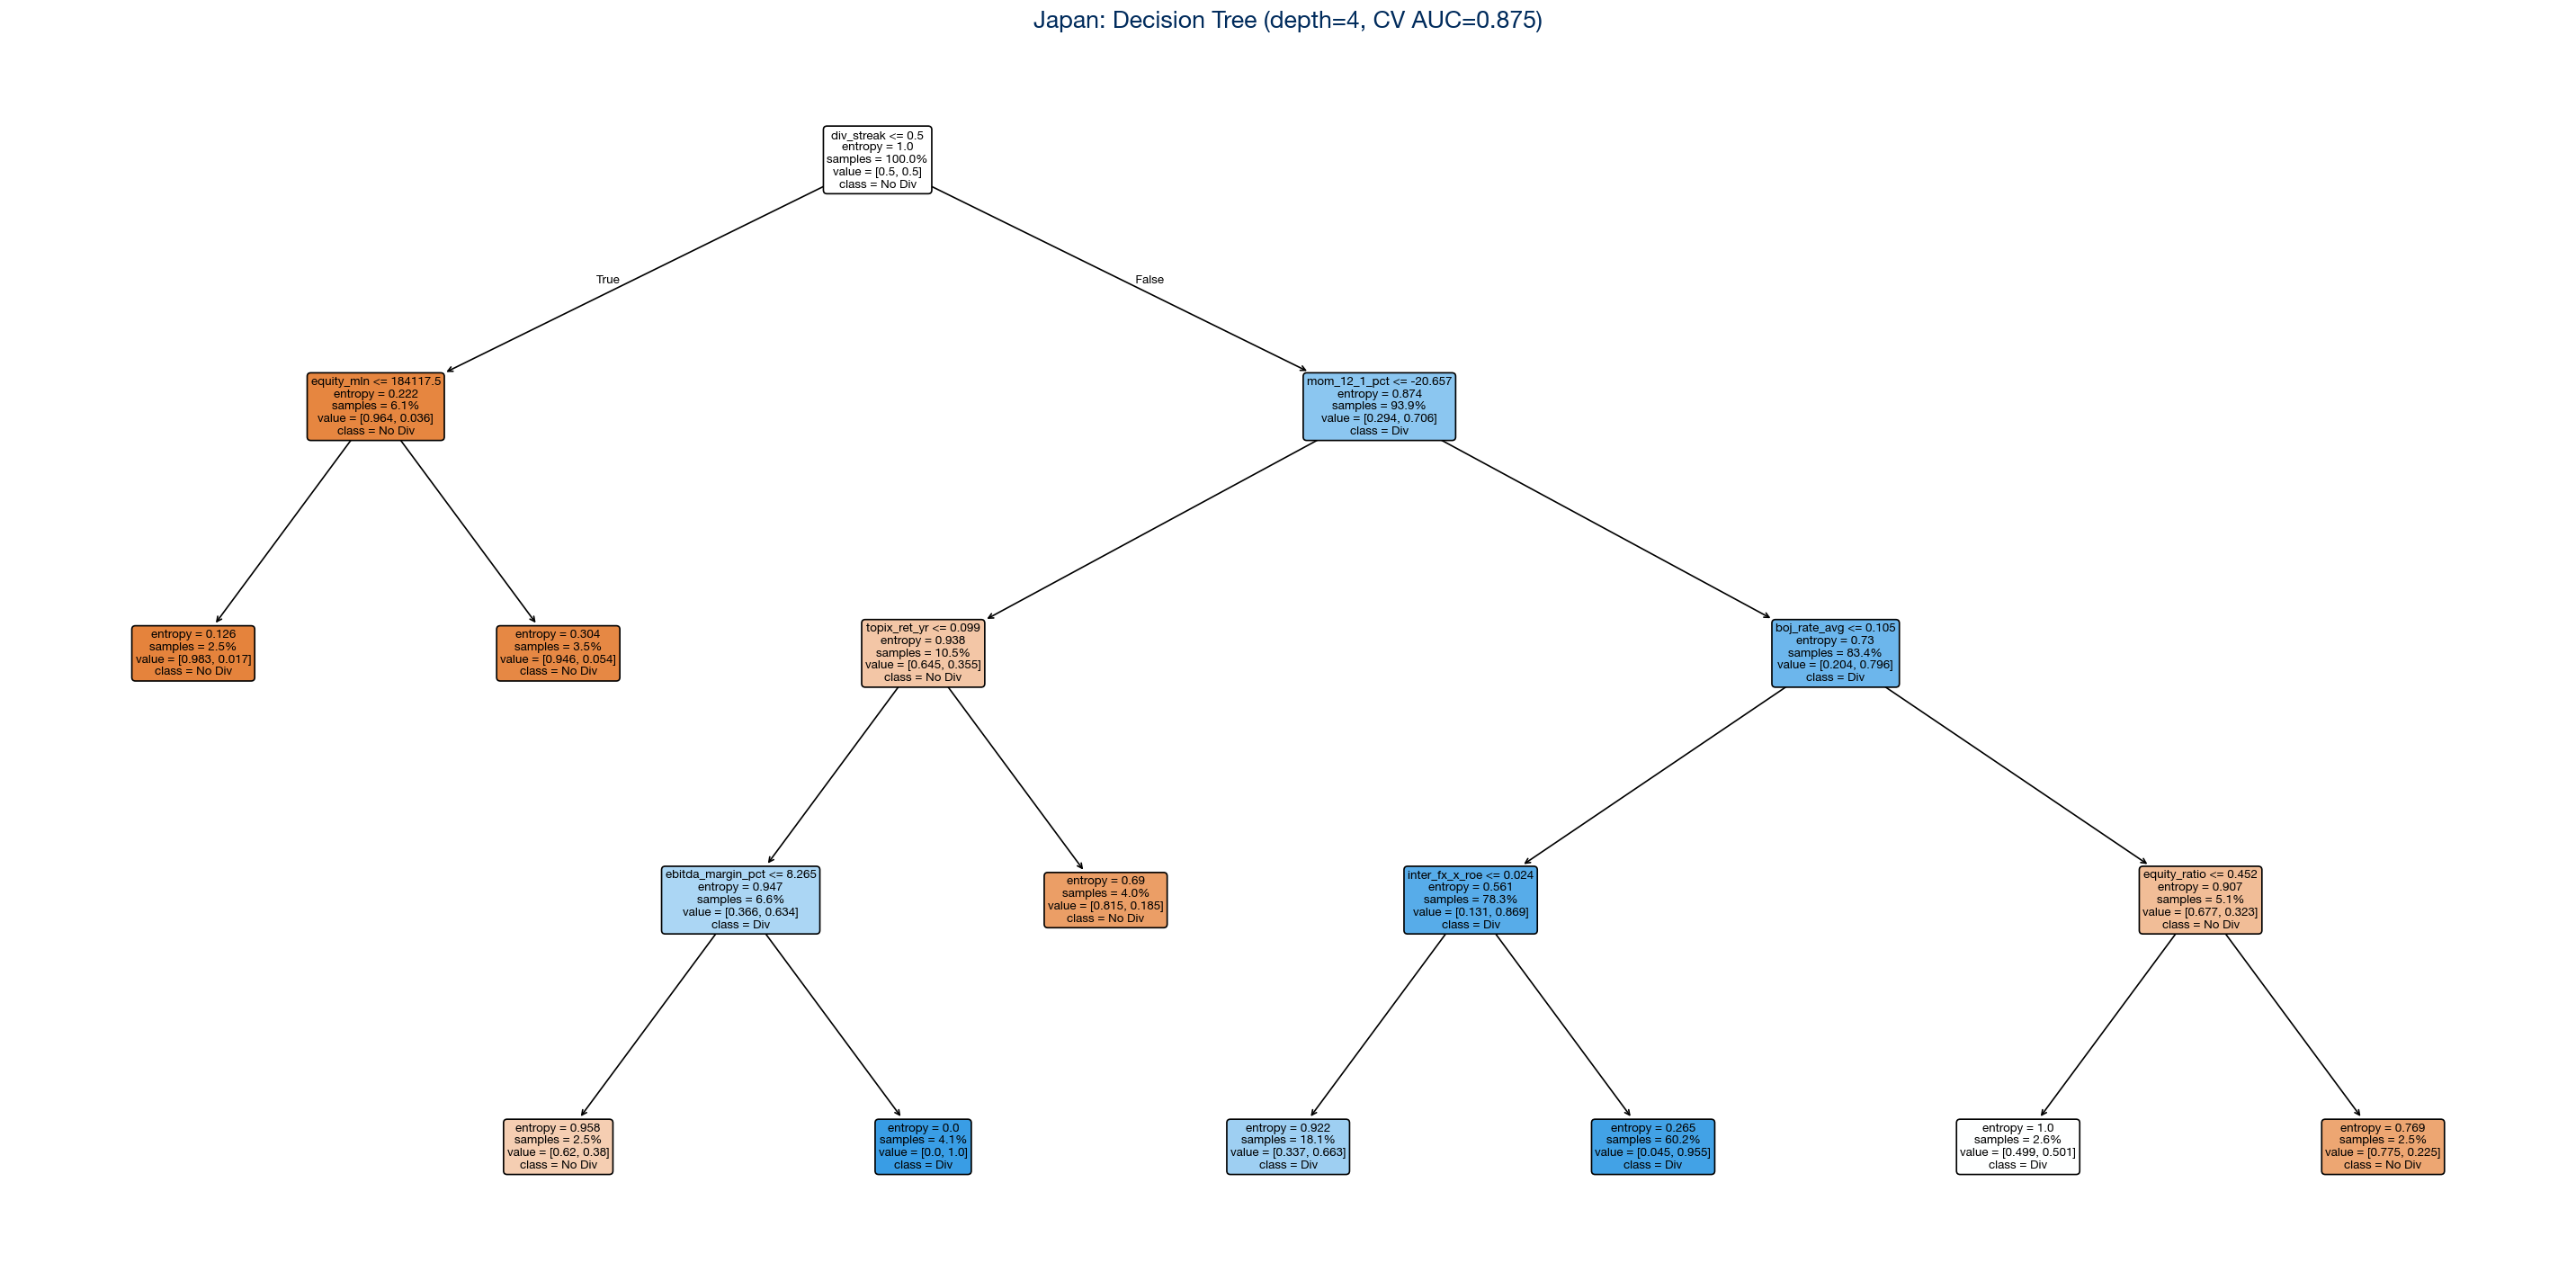


  RF tree saved to decision_tree_RF.txt

  JP tree saved to decision_tree_JP.txt


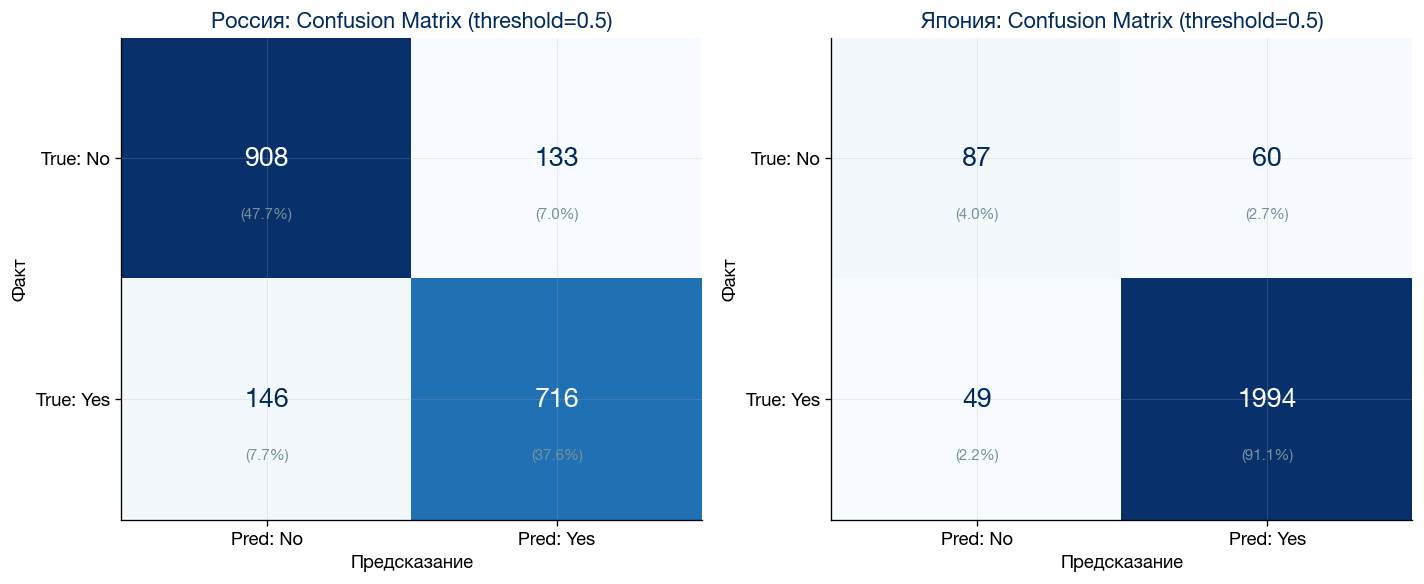


Error Analysis — Russia:
  False Positives: 133 (7.0%)
  False Negatives: 146 (7.7%)
  Top FP (highest P but no dividend):
    VTBR (2021): P=1.000
    NLMK (2021): P=0.999
    MGTS (2019): P=0.999
    ALRS (2021): P=0.999
    SBERP (2021): P=0.999
  Top FN (lowest P but paid dividend):
    KGKCP (2018): P=0.000
    LEAS (2017): P=0.000
    KGKC (2018): P=0.000
    LVHK (2018): P=0.000
    HIMCP (2017): P=0.001


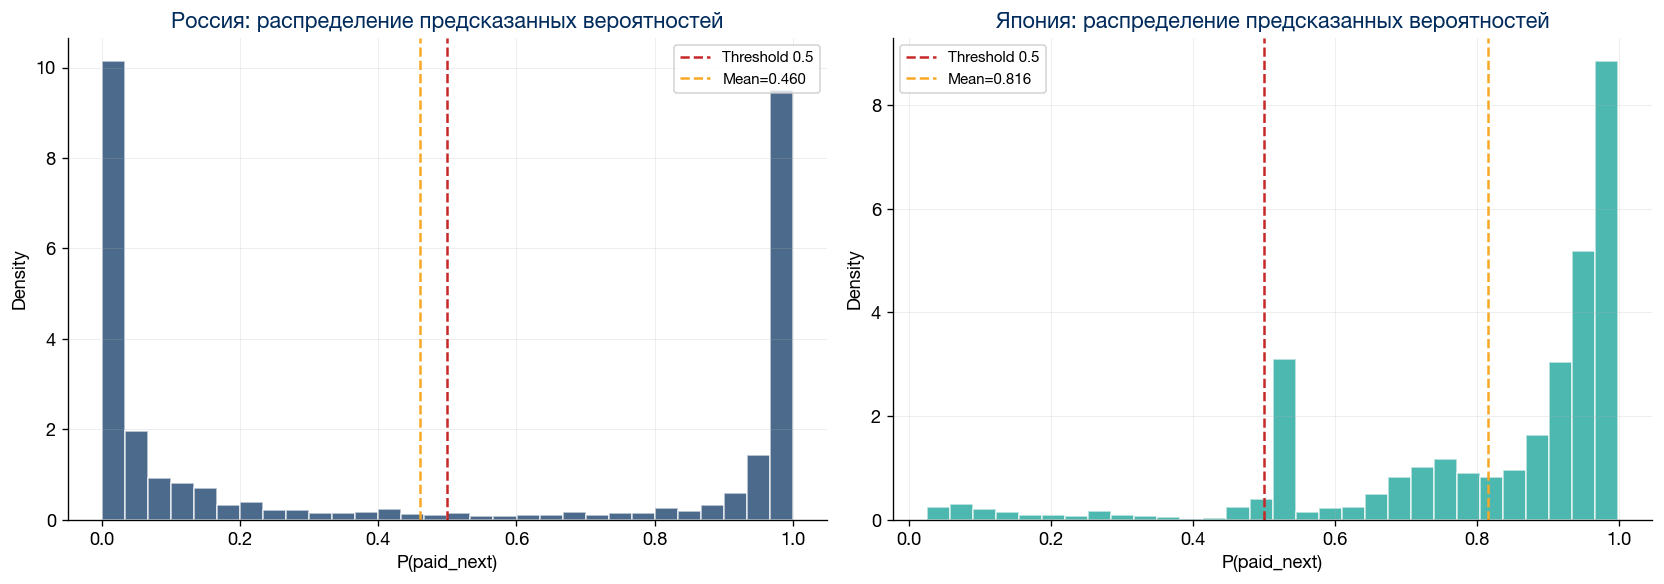

Модель,RF ROC-AUC,JP ROC-AUC,RF PR-AUC,JP PR-AUC,RF BL-3yr,JP BL-3yr
CatBoost,0.896,0.979,0.905,0.999,0.833,0.798
XGBoost,0.904,0.973,0.898,0.999,0.833,0.798
LightGBM,0.902,0.957,0.902,0.997,0.833,0.798
Random Forest,0.902,0.971,0.902,0.998,0.833,0.798
Logistic Regression,0.882,0.946,0.880,0.997,0.833,0.798


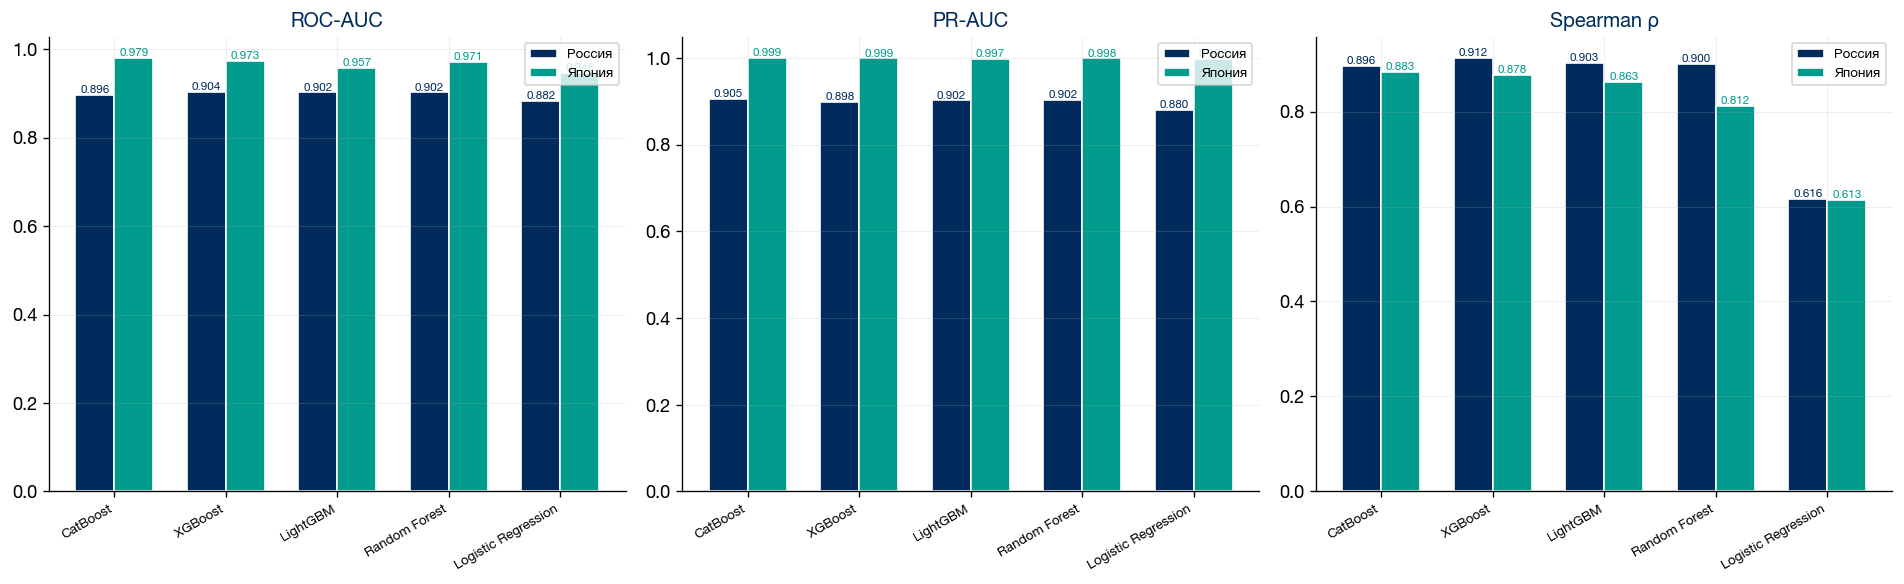

In [9]:
# %%
# ══════════════════════════════════════════════════════════════
#  ISOTONIC CALIBRATION
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Калибровка вероятностей
#
# Бустинговые модели часто генерируют вероятности, не соответствующие
# реальным частотам. Isotonic regression — монотонное преобразование,
# которое **сохраняет AUC** (порядок не меняется), но улучшает
# **Brier Score** (калибровку).
#
# Калибратор обучается на OOF-предсказаниях лучшей модели.
# Для ансамбля каждая модель калибруется **собственным** калибратором.

# %%
def calibrate_isotonic(oof_df):
    """Fit isotonic regression on OOF predictions."""
    y_true = oof_df['paid_next'].values
    y_pred = oof_df['p_hat'].values
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(y_pred, y_true)
    brier_before = brier_score_loss(y_true, y_pred)
    y_cal = iso.predict(y_pred)
    brier_after = brier_score_loss(y_true, y_cal)
    return iso, brier_before, brier_after

print('Isotonic Calibration:')
oof_best_rf = results_rf[best_rf]['oof']
oof_best_jp = results_jp[best_jp]['oof']

iso_rf, brier_rf_before, brier_rf_after = calibrate_isotonic(oof_best_rf)
print(f'  RF: Brier {brier_rf_before:.4f} → {brier_rf_after:.4f} '
      f'(Δ = {brier_rf_before - brier_rf_after:+.4f})')

iso_jp, brier_jp_before, brier_jp_after = calibrate_isotonic(oof_best_jp)
print(f'  JP: Brier {brier_jp_before:.4f} → {brier_jp_after:.4f} '
      f'(Δ = {brier_jp_before - brier_jp_after:+.4f})')

# ── Calibration plots (before vs after) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (oof, iso_cal, country) in zip(axes, [
    (oof_best_rf, iso_rf, 'Россия'),
    (oof_best_jp, iso_jp, 'Япония'),
]):
    y_true = oof['paid_next'].values
    y_pred = oof['p_hat'].values
    y_cal = iso_cal.predict(y_pred)

    # Before
    pt_b, pp_b = calibration_curve(y_true, y_pred, n_bins=10,
                                    strategy='uniform')
    ax.plot(pp_b, pt_b, 'o--', color=CRIMSON, lw=1.5, ms=6,
            label='До калибровки')

    # After
    pt_a, pp_a = calibration_curve(y_true, y_cal, n_bins=10,
                                    strategy='uniform')
    ax.plot(pp_a, pt_a, 's-', color=NAVY, lw=2, ms=7,
            label='После калибровки (Isotonic)')

    ax.plot([0, 1], [0, 1], '--', color=GRAY, lw=1, label='Идеальная')
    ax.fill_between(pp_b, pt_b, pp_b, alpha=0.1, color=CRIMSON)
    ax.set_xlabel('Предсказанная вероятность')
    ax.set_ylabel('Эмпирическая частота')
    ax.set_title(f'{country}: калибровочная кривая',
                 fontsize=13, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
save_fig('fig_calibration_isotonic')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  QUANTILE REGRESSION FOR DPS (P10 / P50 / P90)
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Квантильная регрессия
#
# Вместо единственного точечного прогноза DPS обучаются три модели
# LightGBM на квантили 10%, 50%, 90% (objective=quantile).
#
# **Обучение только на плательщиках** с логарифмированием DPS.
# Интервал [Q10, Q90] — прогнозный диапазон (НЕ доверительный интервал).
#
# **Известное ограничение:** эмпирическое покрытие обычно ниже
# целевых 80% из-за малой выборки и тяжёлых хвостов DPS.

# %%
def quantile_regression_cv(df, feats, cat_feats, dps_col, flag_col,
                           country, quantiles=(0.10, 0.50, 0.90)):
    """Walk-forward CV for quantile regression on DPS (payers only)."""
    max_yr = df['year'].max()
    oof_rec = []

    for vy in range(CV_START_YEAR, max_yr):
        trn = df[(df['year'] <= vy - 1) &
                 (df['label_known_paid'] == 1) &
                 (df['paid_next'] == 1)].copy()
        val_all = df[(df['year'] == vy) &
                     (df['label_known_paid'] == 1)].copy()
        val = val_all[val_all['paid_next'] == 1].copy()

        if len(trn) < 30 or len(val) < 5:
            continue

        for c in cat_feats:
            trn[c] = safe_cat(trn[c])
            val[c] = safe_cat(val[c])

        y_trn = np.log1p(trn['dps_next'].fillna(0).clip(0).values)
        y_val = val['dps_next'].fillna(0).values

        X_trn = trn[feats].copy()
        X_val = val[feats].copy()

        # LabelEncode for LightGBM quantile (trained only on train)
        le_q = {}
        for c in cat_feats:
            le = LabelEncoder()
            X_trn[c] = le.fit_transform(X_trn[c].astype(str))
            mp = {v: i for i, v in enumerate(le.classes_)}
            X_val[c] = X_val[c].astype(str).map(mp).fillna(-1).astype(int)
            le_q[c] = le

        fill_med = X_trn.select_dtypes(include=[np.number]).median().fillna(0)
        for col_name in fill_med.index:
            if col_name in X_trn.columns:
                X_trn[col_name] = X_trn[col_name].fillna(fill_med[col_name])
            if col_name in X_val.columns:
                X_val[col_name] = X_val[col_name].fillna(fill_med[col_name])

        preds = {}
        for q in quantiles:
            qreg = LGBMRegressor(
                objective='quantile', alpha=q,
                n_estimators=400, learning_rate=0.04, max_depth=6,
                subsample=0.8, random_state=SEED, verbosity=-1)
            qreg.fit(X_trn, y_trn)
            preds[f'q{int(q * 100)}'] = np.expm1(
                qreg.predict(X_val)).clip(0)

        for i in range(len(val)):
            rec = {
                'ticker': val.iloc[i]['ticker'], 'year': vy,
                'dps_true': y_val[i],
            }
            for q in quantiles:
                rec[f'q{int(q * 100)}'] = preds[f'q{int(q * 100)}'][i]
            oof_rec.append(rec)

    return pd.DataFrame(oof_rec)

print('Quantile Regression (P10/P50/P90):')

t0 = time.time()
qr_rf = quantile_regression_cv(rf, rf_feats, rf_cats, RF_DPS_COL,
                                RF_FLAG_COL, 'RF')
if len(qr_rf) > 0:
    mae_q50_rf = np.mean(np.abs(qr_rf['dps_true'] - qr_rf['q50']))
    coverage_rf = np.mean(
        (qr_rf['dps_true'] >= qr_rf['q10']) &
        (qr_rf['dps_true'] <= qr_rf['q90']))
    width_rf = (qr_rf['q90'] - qr_rf['q10']).median()
    print(f'  RF: MAE(Q50)={mae_q50_rf:.2f}, '
          f'empirical coverage={coverage_rf:.1%}, '
          f'median width={width_rf:.2f} ({time.time()-t0:.0f}s)')
else:
    print('  RF: insufficient data')
    mae_q50_rf = coverage_rf = width_rf = np.nan

t0 = time.time()
qr_jp = quantile_regression_cv(jp, jp_feats, jp_cats, JP_DPS_COL,
                                JP_FLAG_COL, 'JP')
if len(qr_jp) > 0:
    mae_q50_jp = np.mean(np.abs(qr_jp['dps_true'] - qr_jp['q50']))
    coverage_jp = np.mean(
        (qr_jp['dps_true'] >= qr_jp['q10']) &
        (qr_jp['dps_true'] <= qr_jp['q90']))
    width_jp = (qr_jp['q90'] - qr_jp['q10']).median()
    print(f'  JP: MAE(Q50)={mae_q50_jp:.2f}, '
          f'empirical coverage={coverage_jp:.1%}, '
          f'median width={width_jp:.2f} ({time.time()-t0:.0f}s)')
else:
    print('  JP: insufficient data')
    mae_q50_jp = coverage_jp = width_jp = np.nan

# Summary table
qr_rows = [
    ['Россия',
     f'{mae_q50_rf:.2f}' if np.isfinite(mae_q50_rf) else 'N/A',
     f'{coverage_rf:.1%}' if np.isfinite(coverage_rf) else 'N/A',
     f'{width_rf:.2f}' if np.isfinite(width_rf) else 'N/A'],
    ['Япония',
     f'{mae_q50_jp:.2f}' if np.isfinite(mae_q50_jp) else 'N/A',
     f'{coverage_jp:.1%}' if np.isfinite(coverage_jp) else 'N/A',
     f'{width_jp:.2f}' if np.isfinite(width_jp) else 'N/A'],
]
html = mckinsey_table(
    qr_rows,
    ['Страна', 'MAE (Q50)', 'Empirical Coverage (Q10–Q90)',
     'Median Interval Width'],
    'Таблица 8. Quantile Regression для DPS (на плательщиках)',
    minimize_col=1)
display(HTML(html))

# ── Quantile regression diagnostic: actual vs predicted ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (qr_data, country) in zip(axes,
        [(qr_rf, 'Россия'), (qr_jp, 'Япония')]):
    if len(qr_data) == 0:
        ax.set_title(f'{country}: нет данных')
        continue
    # Sort by Q50 for visualization
    qr_sorted = qr_data.sort_values('q50').reset_index(drop=True)
    n = len(qr_sorted)
    idx = np.arange(n)

    # Show subset for readability
    step = max(1, n // 100)
    sel = idx[::step]

    ax.fill_between(sel, qr_sorted['q10'].values[sel],
                    qr_sorted['q90'].values[sel],
                    alpha=0.2, color=TEAL, label='[Q10, Q90]')
    ax.scatter(sel, qr_sorted['dps_true'].values[sel],
               s=8, alpha=0.6, color=NAVY, label='Факт DPS', zorder=3)
    ax.plot(sel, qr_sorted['q50'].values[sel],
            color=GOLD, lw=1.5, label='Q50 (медиана)')
    ax.set_xlabel('Компании (сортировка по Q50)')
    ax.set_ylabel('DPS')
    ax.set_title(f'{country}: квантильный прогноз vs факт',
                 fontsize=13, fontweight='bold', color=NAVY)
    ax.legend(fontsize=8)

plt.tight_layout()
save_fig('fig_quantile_regression')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  SHAP ANALYSIS
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### SHAP-анализ
#
# TreeExplainer для содержательной интерпретации вклада признаков.
# Модель обучается на данных до предпоследнего года,
# SHAP рассчитывается на последних годах.

# %%
def compute_shap(df, feats, cat_feats, dps_col, model_name, country):
    """Compute SHAP values for the classifier."""
    labeled = df[df['label_known_paid'] == 1].copy()
    for c in cat_feats:
        labeled[c] = safe_cat(labeled[c])

    cat_idx = [feats.index(c) for c in cat_feats if c in feats]
    max_yr = labeled['year'].max()
    trn = labeled[labeled['year'] < max_yr - 1].copy()
    val = labeled[labeled['year'] >= max_yr - 1].copy()

    if len(trn) < 50 or len(val) < 10:
        print(f'  {country}: insufficient data for SHAP')
        return None, None, feats

    model = MultiModelZI(model_name, seed=SEED)
    model.fit(trn[feats], trn['paid_next'].astype(int).values,
              trn['dps_next'].fillna(0).values,
              cat_feats=cat_feats, cat_idx=cat_idx)

    # Prepare X for SHAP (must match model preprocessing)
    X_shap = model._preprocess_pred(val[feats], cat_feats)

    if model_name not in ('catboost', 'xgboost', 'lightgbm'):
        print(f'  {country}: SHAP TreeExplainer not available for {model_name}')
        return None, None, feats

    try:
        explainer = shap.TreeExplainer(model.clf)
        shap_values = explainer.shap_values(X_shap)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # class=1
        return shap_values, X_shap, feats
    except Exception as e:
        print(f'  {country}: SHAP failed: {e}')
        return None, None, feats

print('Computing SHAP values...')
shap_rf, X_shap_rf, _ = compute_shap(rf, rf_feats, rf_cats, RF_DPS_COL,
                                       best_rf, 'RF')
shap_jp, X_shap_jp, _ = compute_shap(jp, jp_feats, jp_cats, JP_DPS_COL,
                                       best_jp, 'JP')

# ── Feature importance bar chart ──
def plot_feature_importance(shap_values, feature_names, country, top_n=20):
    if shap_values is None:
        print(f'  {country}: no SHAP values available')
        return
    mean_abs = np.abs(shap_values).mean(axis=0)
    idx = np.argsort(mean_abs)[-top_n:]
    top_feats = [feature_names[i] for i in idx]
    top_vals = mean_abs[idx]

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(range(len(top_feats)), top_vals, color=NAVY,
                   edgecolor='white', height=0.7)
    # Highlight top-3
    for i in range(max(0, len(bars) - 3), len(bars)):
        bars[i].set_color(GOLD)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|', fontsize=11)
    ax.set_title(f'{country}: Top-{top_n} признаков по значимости (SHAP)',
                 fontsize=14, fontweight='bold', color=NAVY)
    ax.invert_yaxis()
    for i, (v, bar) in enumerate(zip(top_vals, bars)):
        ax.text(v + max(top_vals) * 0.01, i, f'{v:.3f}',
                va='center', fontsize=8, color=GRAY)
    plt.tight_layout()
    save_fig(f'fig_shap_importance_{country}')
    plt.show()

plot_feature_importance(shap_rf, rf_feats, 'Russia', TOP_N)
plot_feature_importance(shap_jp, jp_feats, 'Japan', TOP_N)

# ── SHAP beeswarm plot (if available) ──
def plot_shap_beeswarm(shap_values, X_shap, feature_names, country,
                       top_n=15):
    if shap_values is None:
        return
    try:
        shap_exp = shap.Explanation(
            values=shap_values,
            data=X_shap.values if hasattr(X_shap, 'values') else X_shap,
            feature_names=feature_names)
        fig = plt.figure(figsize=(10, 8))
        shap.plots.beeswarm(shap_exp, max_display=top_n, show=False)
        plt.title(f'{country}: SHAP Beeswarm',
                  fontsize=13, fontweight='bold', color=NAVY)
        plt.tight_layout()
        save_fig(f'fig_shap_beeswarm_{country}')
        plt.show()
    except Exception as e:
        print(f'  {country}: beeswarm plot failed: {e}')

plot_shap_beeswarm(shap_rf, X_shap_rf, rf_feats, 'Russia')
plot_shap_beeswarm(shap_jp, X_shap_jp, jp_feats, 'Japan')

# %%
# ══════════════════════════════════════════════════════════════
#  DECISION TREE FOR INTERPRETATION
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Классификационное дерево решений
#
# Неглубокое дерево (scikit-learn `DecisionTreeClassifier`, criterion=entropy)
# как **объясняющая** модель для визуализации ключевых правил сегментации.
#
# Глубина подбирается 5-кратной кросс-валидацией (диапазон 2–5).
# Минимальный размер листа — max(25, 2.5% выборки).
#
# **NB:** Это НЕ CHAID. CHAID использует χ²-тесты и мультивариантные сплиты.
# Здесь — стандартное CART-дерево с информационным выигрышем (entropy).

# %%
DecisionTreeResult = namedtuple(
    'DecisionTreeResult',
    ['tree', 'X', 'y', 'best_depth', 'cv_auc', 'is_auc', 'feature_names'])

def build_decision_tree(df, feats, cat_feats, country, verbose=True):
    """Build interpretable decision tree with CV-tuned depth."""
    labeled = df[df['label_known_paid'] == 1].copy()
    for c in cat_feats:
        labeled[c] = safe_cat(labeled[c])

    X = labeled[feats].copy()
    le_dict = {}
    for c in cat_feats:
        le = LabelEncoder()
        X[c] = le.fit_transform(X[c].astype(str))
        le_dict[c] = le
    # Fill NaN with median for decision tree
    fill_med = X.select_dtypes(include=[np.number]).median().fillna(0)
    for col_name in fill_med.index:
        if col_name in X.columns:
            X[col_name] = X[col_name].fillna(fill_med[col_name])
    y = labeled['paid_next'].astype(int).values

    min_leaf = max(25, int(len(y) * 0.025))

    # Cross-validate depth
    best_depth, best_cv_auc = 3, 0
    for depth in [2, 3, 4, 5]:
        dt = DecisionTreeClassifier(
            criterion='entropy', max_depth=depth,
            min_samples_leaf=min_leaf,
            class_weight='balanced', random_state=SEED)
        cv_scores = cross_val_score(dt, X.values, y, cv=5,
                                     scoring='roc_auc')
        mean_auc = cv_scores.mean()
        if verbose:
            print(f'  {country} depth={depth}: CV AUC={mean_auc:.4f} '
                  f'(±{cv_scores.std():.4f})')
        if mean_auc > best_cv_auc:
            best_cv_auc = mean_auc
            best_depth = depth

    # Fit final tree
    fitted = DecisionTreeClassifier(
        criterion='entropy', max_depth=best_depth,
        min_samples_leaf=min_leaf,
        class_weight='balanced', random_state=SEED)
    fitted.fit(X.values, y)
    is_auc = roc_auc_score(y, fitted.predict_proba(X.values)[:, 1])

    if verbose:
        print(f'  {country}: best depth={best_depth}, '
              f'CV AUC={best_cv_auc:.4f}, IS AUC={is_auc:.4f}')

    # Feature importance
    imp = pd.Series(fitted.feature_importances_, index=feats)
    imp_sorted = imp.sort_values(ascending=False)
    top5 = imp_sorted.head(5)
    if verbose:
        print(f'  Top-5 features by information gain:')
        for fname, fval in top5.items():
            print(f'    {fname}: {fval:.3f} ({fval/imp.sum()*100:.1f}%)')

    return DecisionTreeResult(
        tree=fitted, X=X, y=y, best_depth=best_depth,
        cv_auc=best_cv_auc, is_auc=is_auc, feature_names=feats)

print('Building Decision Trees for interpretation...')
print('─' * 60)
print('  РОССИЯ:')
res_rf_tree = build_decision_tree(rf, rf_feats, rf_cats, 'RF')
print('─' * 60)
print('  ЯПОНИЯ:')
res_jp_tree = build_decision_tree(jp, jp_feats, jp_cats, 'JP')

# ── Visualize trees ──
def plot_decision_tree(dt_result, country, figsize=(24, 12)):
    fig, ax = plt.subplots(figsize=figsize)
    plot_tree(dt_result.tree,
              feature_names=dt_result.feature_names,
              class_names=['No Div', 'Div'],
              filled=True, rounded=True, fontsize=8, ax=ax,
              proportion=True, impurity=True)
    ax.set_title(f'{country}: Decision Tree (depth={dt_result.best_depth}, '
                 f'CV AUC={dt_result.cv_auc:.3f})',
                 fontsize=16, fontweight='bold', color=NAVY)
    plt.tight_layout()
    save_fig(f'fig_decision_tree_{country}')
    plt.show()

plot_decision_tree(res_rf_tree, 'Russia')
plot_decision_tree(res_jp_tree, 'Japan')

# ── Text export ──
for dt_result, country in [(res_rf_tree, 'RF'), (res_jp_tree, 'JP')]:
    tree_text = export_text(dt_result.tree,
                            feature_names=dt_result.feature_names,
                            max_depth=dt_result.best_depth)
    with open(f'{OUT_DIR}/decision_tree_{country}.txt', 'w') as f:
        f.write(tree_text)
    print(f'\n  {country} tree saved to decision_tree_{country}.txt')

# %%
# ══════════════════════════════════════════════════════════════
#  CONFUSION MATRIX & ERROR ANALYSIS
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Анализ ошибок
#
# Confusion matrix на OOF-предсказаниях лучшей модели (порог 0.5).
# Отдельно: false positives (предсказали выплату, а её нет)
# и false negatives (не предсказали, а выплата была).

# %%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (oof, country) in zip(axes, [
    (oof_best_rf, 'Россия'), (oof_best_jp, 'Япония')
]):
    y_true = oof['paid_next'].values
    y_pred = (oof['p_hat'].values > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No', 'Pred: Yes'])
    ax.set_yticklabels(['True: No', 'True: Yes'])
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Факт')
    ax.set_title(f'{country}: Confusion Matrix (threshold=0.5)',
                 fontsize=13, fontweight='bold', color=NAVY)

    # Annotate cells
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else NAVY
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax.text(j, i + 0.25, f'({pct:.1f}%)', ha='center',
                    fontsize=9, color=GRAY)

plt.tight_layout()
save_fig('fig_confusion_matrix')
plt.show()

# ── Error analysis: worst false positives and false negatives ──
print('\nError Analysis — Russia:')
oof_rf_err = oof_best_rf.copy()
oof_rf_err['error_type'] = 'correct'
oof_rf_err.loc[(oof_rf_err['p_hat'] > 0.5) &
               (oof_rf_err['paid_next'] == 0), 'error_type'] = 'false_positive'
oof_rf_err.loc[(oof_rf_err['p_hat'] <= 0.5) &
               (oof_rf_err['paid_next'] == 1), 'error_type'] = 'false_negative'

fp = oof_rf_err[oof_rf_err['error_type'] == 'false_positive']
fn = oof_rf_err[oof_rf_err['error_type'] == 'false_negative']
print(f'  False Positives: {len(fp)} '
      f'({len(fp)/len(oof_rf_err)*100:.1f}%)')
print(f'  False Negatives: {len(fn)} '
      f'({len(fn)/len(oof_rf_err)*100:.1f}%)')
if len(fp) > 0:
    print(f'  Top FP (highest P but no dividend):')
    fp_top = fp.nlargest(5, 'p_hat')[['ticker', 'year', 'p_hat']]
    for _, r in fp_top.iterrows():
        print(f'    {r["ticker"]} ({r["year"]}): P={r["p_hat"]:.3f}')
if len(fn) > 0:
    print(f'  Top FN (lowest P but paid dividend):')
    fn_top = fn.nsmallest(5, 'p_hat')[['ticker', 'year', 'p_hat']]
    for _, r in fn_top.iterrows():
        print(f'    {r["ticker"]} ({r["year"]}): P={r["p_hat"]:.3f}')

# %%
# ══════════════════════════════════════════════════════════════
#  PREDICTION DISTRIBUTION DIAGNOSTICS
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (oof, country, color) in zip(axes, [
    (oof_best_rf, 'Россия', NAVY),
    (oof_best_jp, 'Япония', TEAL),
]):
    ax.hist(oof['p_hat'].values, bins=30, color=color, alpha=0.7,
            edgecolor='white', density=True)
    ax.axvline(x=0.5, color=CRIMSON, ls='--', lw=1.5,
               label='Threshold 0.5')
    ax.axvline(x=oof['p_hat'].mean(), color=GOLD, ls='--', lw=1.5,
               label=f'Mean={oof["p_hat"].mean():.3f}')
    ax.set_xlabel('P(paid_next)')
    ax.set_ylabel('Density')
    ax.set_title(f'{country}: распределение предсказанных вероятностей',
                 fontsize=13, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)

plt.tight_layout()
save_fig('fig_prediction_distribution')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  CROSS-COUNTRY COMPARISON TABLE & BAR CHART
# ══════════════════════════════════════════════════════════════

cross_rows = []
for mn in MODEL_NAMES:
    rf_mdf = results_rf[mn]['metrics']
    jp_mdf = results_jp[mn]['metrics']
    if len(rf_mdf) == 0 or len(jp_mdf) == 0:
        continue
    cross_rows.append([
        DISPLAY_NAME[mn],
        f'{rf_mdf["clf_ROC_AUC"].median():.3f}',
        f'{jp_mdf["clf_ROC_AUC"].median():.3f}',
        f'{rf_mdf["clf_PR_AUC"].median():.3f}',
        f'{jp_mdf["clf_PR_AUC"].median():.3f}',
        f'{rf_mdf["bl_3yr_AUC"].median():.3f}',
        f'{jp_mdf["bl_3yr_AUC"].median():.3f}',
    ])

html = mckinsey_table(
    cross_rows,
    ['Модель', 'RF ROC-AUC', 'JP ROC-AUC', 'RF PR-AUC', 'JP PR-AUC',
     'RF BL-3yr', 'JP BL-3yr'],
    'Таблица 9. Межстрановое сравнение',
    highlight_col=1)
display(HTML(html))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_vis = [
    ('clf_ROC_AUC', 'ROC-AUC'),
    ('clf_PR_AUC', 'PR-AUC'),
    ('reg_Spearman', 'Spearman ρ')]

for ax, (metric, label) in zip(axes, metrics_vis):
    rf_vals = [results_rf[mn]['metrics'][metric].median()
               for mn in MODEL_NAMES]
    jp_vals = [results_jp[mn]['metrics'][metric].median()
               for mn in MODEL_NAMES]
    names = [DISPLAY_NAME[mn] for mn in MODEL_NAMES]

    x = np.arange(len(names))
    w = 0.35
    ax.bar(x - w / 2, rf_vals, w, label='Россия', color=NAVY,
           edgecolor='white')
    ax.bar(x + w / 2, jp_vals, w, label='Япония', color=TEAL,
           edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    ax.set_title(label, fontsize=12, fontweight='bold', color=NAVY)
    ax.legend(fontsize=8)
    # Add value labels
    for xi, (rv, jv) in enumerate(zip(rf_vals, jp_vals)):
        if np.isfinite(rv):
            ax.text(xi - w / 2, rv + 0.005, f'{rv:.3f}',
                    ha='center', fontsize=7, color=NAVY)
        if np.isfinite(jv):
            ax.text(xi + w / 2, jv + 0.005, f'{jv:.3f}',
                    ha='center', fontsize=7, color=TEAL)

plt.tight_layout()
save_fig('fig_cross_country_comparison')
plt.show()

Training final models on full data...
────────────────────────────────────────────────────────────
  RF (XGBoost): Conformal CI [-69.81, +222.49]
  JP (CatBoost): Conformal CI [-14.62, +46.53]

Applying isotonic calibration to final predictions...
  RF: raw mean P=0.444 → calibrated mean P=0.429
  JP: raw mean P=0.924 → calibrated mean P=0.952

Training final quantile models...
  RF: Q10/Q50/Q90 computed for 236 companies
  JP: Q10/Q50/Q90 computed for 245 companies

Building calibrated ensemble (top-3 models)...
  RF (XGBoost): Conformal CI [-69.81, +222.49]
  RF (LightGBM): Conformal CI [-48.13, +210.74]
  RF (Random Forest): Conformal CI [-43.71, +198.03]
  JP (CatBoost): Conformal CI [-14.62, +46.53]
  JP (XGBoost): Conformal CI [-14.24, +48.53]
  JP (Random Forest): Conformal CI [-14.79, +60.72]
  RF ensemble: mean P=0.411
  JP ensemble: mean P=0.878

Building rating DataFrames...
  RF: 236 companies
  JP: 245 companies

  RF summary:
    Mean P(cal)=0.429, Mean DPS Q50=88.5
    S

#,Тикер,Сектор,P(cal),P(ens),Серия,Стаб.,DPS [Q10–Q50–Q90],"E[дох],%"
1,RTKM,Телекоммуникации,93%,94%,13,0.96,1–4–11,11.2%
2,SBER,Финансы (Банки),93%,94%,13,0.96,9–30–35,5.1%
3,GCHE,Потребительский сектор,91%,95%,13,0.95,39–230–229,2.8%
4,BSPB,Финансы (Банки),93%,94%,12,0.93,12–30–39,5.9%
5,NVTK,Нефть и газ,91%,94%,12,0.92,18–95–174,3.7%
6,LSRG,Недвижимость,85%,81%,13,0.91,17–53–78,4.7%
7,MRKP,Энергетика,85%,90%,13,0.91,—,54.7%
8,PMSB,Энергетика,85%,88%,13,0.91,10–30–68,3.5%
9,TTLK,Телекоммуникации,85%,88%,13,0.91,—,39.5%
10,MOEX,Финансы,83%,88%,13,0.90,5–14–25,3.4%


#,Тикер,Сектор,P(cal),P(ens),Серия,Стаб.,DPS [Q10–Q50–Q90],"E[дох],%"
1,2267,Consumer Staples,100%,98%,16,1.00,20–32–39,1.1%
2,3088,Consumer Staples,100%,98%,16,1.00,22–22–41,1.0%
3,3101,Consumer Discretionary,100%,87%,16,1.00,26–39–38,2.9%
4,3231,Real Estate,100%,97%,16,1.00,7–12–18,2.4%
5,3865,Materials,100%,98%,16,1.00,13–10–15,1.2%
6,4041,Materials,100%,98%,16,1.00,33–61–75,1.7%
7,4272,Materials,100%,98%,16,1.00,17–19–30,1.2%
8,5232,Materials,100%,98%,16,1.00,42–77–87,2.0%
9,5901,Materials,100%,98%,16,1.00,34–59–60,1.4%
10,6505,Industrials,100%,98%,16,1.00,29–76–172,2.8%


#,Тикер,Сектор,P(выпл.),P(ens),Риск,Тек. DPS,Прогн. DPS,"ROE,%"
1,ASTR,IT,39%,50%,СРЕДНИЙ,5.8,12.3,—
2,SOFL,IT,39%,44%,СРЕДНИЙ,2.5,8.3,—
3,DIAS,IT,53%,50%,УМЕРЕННЫЙ,178.3,94.0,—
4,DATA,IT,53%,50%,УМЕРЕННЫЙ,0.9,7.6,—
5,DVEC,Энергетика,53%,53%,УМЕРЕННЫЙ,0.2,0.3,—
6,IVAT,IT,53%,49%,УМЕРЕННЫЙ,3.0,8.4,—
7,KLVZ,Потребительский сект,53%,61%,УМЕРЕННЫЙ,0.1,0.7,—
8,MGNT,Потребительский сект,53%,67%,УМЕРЕННЫЙ,560.0,268.2,—
9,OZPH,Здравоохранение,53%,54%,УМЕРЕННЫЙ,0.5,2.8,—
10,PLZL,Металлы и добыча,53%,61%,УМЕРЕННЫЙ,73.0,183.2,—


#,Тикер,Сектор,P(выпл.),P(ens),Риск,Тек. DPS,Прогн. DPS,"ROE,%"
1,1963,Industrials,100%,94%,УМЕРЕННЫЙ,40.0,26.9,—
2,2802,Consumer Staples,100%,96%,УМЕРЕННЫЙ,40.0,22.5,—
3,6472,Industrials,100%,93%,УМЕРЕННЫЙ,5.5,6.6,—
4,6504,Industrials,100%,98%,УМЕРЕННЫЙ,85.0,78.4,—
5,8267,Consumer Staples,100%,90%,УМЕРЕННЫЙ,20.0,16.7,—
6,1332,Consumer Staples,100%,98%,УМЕРЕННЫЙ,16.0,20.1,—
7,1333,Consumer Staples,100%,98%,УМЕРЕННЫЙ,60.0,30.0,—
8,1721,Industrials,100%,98%,УМЕРЕННЫЙ,60.0,61.3,—
9,1801,Industrials,100%,98%,УМЕРЕННЫЙ,145.0,102.2,—
10,1802,Industrials,100%,98%,УМЕРЕННЫЙ,41.0,52.0,—


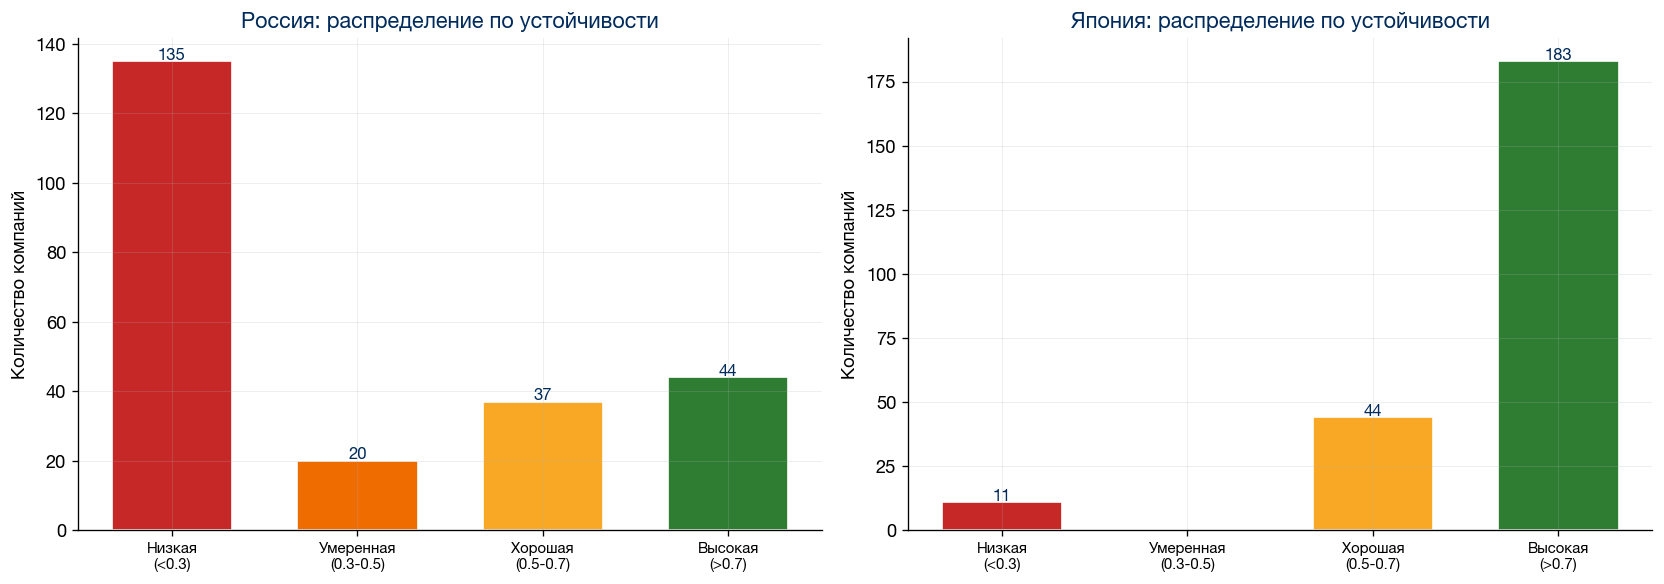

Exporting results to Excel...
  ✅ Saved to: /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5/dividend_forecast_2026_v5.xlsx

══════════════════════════════════════════════════════════════════════
  RESEARCH COMPLETED SUCCESSFULLY
══════════════════════════════════════════════════════════════════════

  Best model Russia: XGBoost (ROC-AUC = 0.904)
  Best model Japan:  CatBoost (ROC-AUC = 0.979)

  Lift over 3-year baseline:
    Russia: +0.071
    Japan:  +0.182

  Output directory: /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5
  Excel file: /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5/dividend_forecast_2026_v5.xlsx

  Total companies rated:
    Russia: 236
    Japan:  245

══════════════════════════════════════════════════════════════════════

Reproducibility snapshot saved to /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5/results_snapshot.json

To verify reproducibility, compare these values after re-running:
  seed: 42
  cv_start_year: 

In [12]:
# %%
# ══════════════════════════════════════════════════════════════
#  FINAL MODEL TRAINING & PREDICTIONS FOR 2026
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Финальный прогноз
#
# Все модели обучаются на **полном объёме данных** (все размеченные годы).
# Прогноз формируется для наблюдений года `PRED_YEAR` (2026),
# предсказывая дивидендное поведение в 2026.
#
# **Conformal intervals:** квантили OOF-остатков уровня `CI_ALPHA`
# добавляются к точечному прогнозу DPS. Нижняя граница обрезается нулём.

# %%
def fit_conformal(oof_df, alpha=CI_ALPHA):
    """Compute conformal interval bounds from OOF residuals (payers only)."""
    paid = oof_df[oof_df['paid_next'] == 1]
    res = paid['dps_next'] - paid['dps_hat']
    res = res.dropna()
    if len(res) < 10:
        return 0.0, 0.0
    q_lo = float(np.percentile(res, alpha / 2 * 100))
    q_hi = float(np.percentile(res, (1 - alpha / 2) * 100))
    return q_lo, q_hi

def train_final_and_predict(df, feats, cat_feats, dps_col, price_col,
                            flag_col, model_name, oof_df, country,
                            pred_year=PRED_YEAR):
    """Train on all labeled data, predict for pred_year."""
    cat_idx = [feats.index(c) for c in cat_feats if c in feats]
    labeled = df[df['label_known_paid'] == 1].copy()
    for c in cat_feats:
        labeled[c] = safe_cat(labeled[c])

    X_all = labeled[feats]
    paid_all = labeled['paid_next'].values.astype(int)
    dps_all = labeled['dps_next'].fillna(0).values

    model = MultiModelZI(model_name, seed=SEED)
    model.fit(X_all, paid_all, dps_all, cat_feats=cat_feats, cat_idx=cat_idx)

    # Conformal intervals
    q_lo, q_hi = fit_conformal(oof_df)
    model.q_lo, model.q_hi = q_lo, q_hi
    print(f'  {country} ({DISPLAY_NAME[model_name]}): '
          f'Conformal CI [{q_lo:+.2f}, {q_hi:+.2f}]')

    # Predict for latest year
    latest = df[df['year'] == pred_year].copy()
    if len(latest) == 0:
        print(f'  ⚠️ {country}: no data for year {pred_year}')
        return None, None, None, None

    for c in cat_feats:
        if c in latest.columns:
            latest[c] = safe_cat(latest[c])

    X_lat = latest[feats]
    p_hat, dps_hat = model.predict(X_lat, cat_feats=cat_feats, cat_idx=cat_idx)

    return p_hat, dps_hat, latest, model

print('Training final models on full data...')
print('─' * 60)

rf_oof = results_rf[best_rf]['oof']
jp_oof = results_jp[best_jp]['oof']

p_best_rf, dps_best_rf, latest_rf, model_rf_final = train_final_and_predict(
    rf, rf_feats, rf_cats, RF_DPS_COL, RF_PRICE_COL, RF_FLAG_COL,
    best_rf, rf_oof, 'RF')

p_best_jp, dps_best_jp, latest_jp, model_jp_final = train_final_and_predict(
    jp, jp_feats, jp_cats, JP_DPS_COL, JP_PRICE_COL, JP_FLAG_COL,
    best_jp, jp_oof, 'JP')

# Check predictions
for arr, name in [(p_best_rf, 'p_best_rf'), (dps_best_rf, 'dps_best_rf'),
                   (p_best_jp, 'p_best_jp'), (dps_best_jp, 'dps_best_jp')]:
    if arr is not None:
        assert not np.isnan(arr).any(), f'NaN in {name}!'

# %%
# ── Apply isotonic calibration ──
print('\nApplying isotonic calibration to final predictions...')

if p_best_rf is not None:
    p_cal_rf = iso_rf.predict(p_best_rf)
    print(f'  RF: raw mean P={p_best_rf.mean():.3f} → '
          f'calibrated mean P={p_cal_rf.mean():.3f}')
else:
    p_cal_rf = None

if p_best_jp is not None:
    p_cal_jp = iso_jp.predict(p_best_jp)
    print(f'  JP: raw mean P={p_best_jp.mean():.3f} → '
          f'calibrated mean P={p_cal_jp.mean():.3f}')
else:
    p_cal_jp = None

# %%
# ══════════════════════════════════════════════════════════════
#  QUANTILE REGRESSION — FINAL PREDICTIONS
# ══════════════════════════════════════════════════════════════

def train_final_quantile(df, feats, cat_feats, dps_col,
                         quantiles=(0.10, 0.50, 0.90), pred_year=PRED_YEAR):
    """Train quantile models on all payers, predict for pred_year."""
    labeled = df[(df['label_known_paid'] == 1) &
                 (df['paid_next'] == 1)].copy()
    for c in cat_feats:
        labeled[c] = safe_cat(labeled[c])

    y_reg = np.log1p(labeled['dps_next'].fillna(0).clip(0).values)
    X_trn = labeled[feats].copy()

    # Encode categoricals
    le_q = {}
    for c in cat_feats:
        le = LabelEncoder()
        X_trn[c] = le.fit_transform(X_trn[c].astype(str))
        le_q[c] = le

    fill_med = X_trn.select_dtypes(include=[np.number]).median().fillna(0)
    for col_name in fill_med.index:
        if col_name in X_trn.columns:
            X_trn[col_name] = X_trn[col_name].fillna(fill_med[col_name])

    # Prepare prediction data
    latest = df[df['year'] == pred_year].copy()
    if len(latest) == 0:
        return {}

    for c in cat_feats:
        latest[c] = safe_cat(latest[c])

    X_pred = latest[feats].copy()
    for c in cat_feats:
        if c in le_q:
            mp = {v: i for i, v in enumerate(le_q[c].classes_)}
            X_pred[c] = X_pred[c].astype(str).map(mp).fillna(-1).astype(int)
    for col_name in fill_med.index:
        if col_name in X_pred.columns:
            X_pred[col_name] = X_pred[col_name].fillna(fill_med[col_name])

    preds = {}
    for q in quantiles:
        qreg = LGBMRegressor(
            objective='quantile', alpha=q,
            n_estimators=400, learning_rate=0.04, max_depth=6,
            subsample=0.8, random_state=SEED, verbosity=-1)
        qreg.fit(X_trn, y_reg)
        preds[f'q{int(q * 100)}'] = np.expm1(qreg.predict(X_pred)).clip(0)

    return preds

print('\nTraining final quantile models...')
qr_final_rf = train_final_quantile(rf, rf_feats, rf_cats, RF_DPS_COL)
qr_final_jp = train_final_quantile(jp, jp_feats, jp_cats, JP_DPS_COL)
print(f'  RF: Q10/Q50/Q90 computed for {len(latest_rf) if latest_rf is not None else 0} companies')
print(f'  JP: Q10/Q50/Q90 computed for {len(latest_jp) if latest_jp is not None else 0} companies')

# %%
# ══════════════════════════════════════════════════════════════
#  CALIBRATED ENSEMBLE (TOP-3 MODELS)
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Ансамбль
#
# Среднее калиброванных вероятностей трёх лучших моделей.
# Каждая модель калибруется **собственным** isotonic regression,
# обученным на её OOF-предсказаниях.

# %%
print('\nBuilding calibrated ensemble (top-3 models)...')

def build_ensemble(df, feats, cat_feats, dps_col, price_col, flag_col,
                   results, top3, latest_df, country):
    """Train top-3 models, calibrate each, average."""
    if latest_df is None or len(latest_df) == 0:
        return None, None

    ens_p = np.zeros(len(latest_df))
    ens_dps = np.zeros(len(latest_df))

    for mn in top3:
        # Train final model
        p_i, dps_i, _, _ = train_final_and_predict(
            df, feats, cat_feats, dps_col, price_col, flag_col,
            mn, results[mn]['oof'], country)

        if p_i is None:
            continue

        # Calibrate with model's own OOF
        oof_i = results[mn]['oof']
        iso_i = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
        iso_i.fit(oof_i['p_hat'].values, oof_i['paid_next'].values)
        p_cal_i = iso_i.predict(p_i)

        ens_p += p_cal_i / len(top3)
        ens_dps += dps_i / len(top3)

    return ens_p, ens_dps

ens_p_rf, ens_dps_rf = build_ensemble(
    rf, rf_feats, rf_cats, RF_DPS_COL, RF_PRICE_COL, RF_FLAG_COL,
    results_rf, top3_rf, latest_rf, 'RF')

ens_p_jp, ens_dps_jp = build_ensemble(
    jp, jp_feats, jp_cats, JP_DPS_COL, JP_PRICE_COL, JP_FLAG_COL,
    results_jp, top3_jp, latest_jp, 'JP')

if ens_p_rf is not None:
    print(f'  RF ensemble: mean P={ens_p_rf.mean():.3f}')
if ens_p_jp is not None:
    print(f'  JP ensemble: mean P={ens_p_jp.mean():.3f}')

# %%
# ══════════════════════════════════════════════════════════════
#  BUILD RATING DATAFRAMES
# ══════════════════════════════════════════════════════════════

# Global max streak for normalization (from full history)
GLOBAL_MAX_STREAK_RF = rf['div_streak'].max() if 'div_streak' in rf.columns else 1
GLOBAL_MAX_STREAK_JP = jp['div_streak'].max() if 'div_streak' in jp.columns else 1

def build_rating(latest, p_hat, p_cal, dps_hat, ens_p, ens_dps,
                 dps_col, flag_col, price_col, q_lo, q_hi, qr_preds,
                 global_max_streak):
    """Build comprehensive rating DataFrame."""
    if latest is None or len(latest) == 0:
        return pd.DataFrame()

    price_arr = (latest[price_col].values if price_col in latest.columns
                 else np.full(len(latest), np.nan))
    price_safe = np.where(price_arr > 0, price_arr, np.nan)

    # Expected yield (uses calibrated P)
    y_paid = np.clip(
        np.where(np.isfinite(price_safe),
                 100.0 * dps_hat / price_safe, np.nan),
        -YIELD_CAP, YIELD_CAP)
    y_hat_exp = np.clip(p_cal * y_paid, -YIELD_CAP, YIELD_CAP)

    # Conformal DPS intervals (clipped at 0)
    dps_lo = np.maximum(0, dps_hat + q_lo)
    dps_hi = np.maximum(0, dps_hat + q_hi)

    # Stability index: 0.6 × P(cal) + 0.4 × normalized streak
    streak_vals = (latest['div_streak'].fillna(0).values
                   if 'div_streak' in latest.columns
                   else np.zeros(len(latest)))
    streak_norm = streak_vals / max(global_max_streak, 1)
    stability = 0.6 * p_cal + 0.4 * streak_norm

    # Build DataFrame
    rating = pd.DataFrame({
        'ticker': latest['ticker'].values,
        'sector': latest['sector'].values if 'sector' in latest.columns else 'Unknown',
        'price_end': price_arr,
        'current_dps': latest[dps_col].fillna(0).values,
        'current_paid': (latest[flag_col].values
                         if flag_col in latest.columns else 0),
        'p_hat_raw': p_hat,
        'p_hat': p_cal,  # calibrated
        'p_ens': ens_p if ens_p is not None else p_cal,
        'dps_hat': dps_hat,
        'dps_ens': ens_dps if ens_dps is not None else dps_hat,
        'dps_lo_conf': dps_lo,
        'dps_hi_conf': dps_hi,
        'dps_q10': qr_preds.get('q10', np.zeros(len(latest))),
        'dps_q50': qr_preds.get('q50', dps_hat),
        'dps_q90': qr_preds.get('q90', np.zeros(len(latest))),
        'y_hat_exp_pct': y_hat_exp,
        'y_paid_pct': y_paid,
        'div_streak': streak_vals,
        'stability': stability,
        'dsi_proxy': (latest['dsi_proxy'].fillna(0).values
                      if 'dsi_proxy' in latest.columns
                      else np.zeros(len(latest))),
    })

    # Add quality metrics if available
    for qcol in ['roe_pct', 'roa_pct', 'net_margin_pct',
                 'net_debt_to_ebitda', 'ebitda_margin_pct']:
        if qcol in latest.columns:
            rating[qcol] = latest[qcol].values

    return rating

print('\nBuilding rating DataFrames...')

if latest_rf is not None and p_cal_rf is not None:
    rf_rating = build_rating(
        latest_rf, p_best_rf, p_cal_rf, dps_best_rf,
        ens_p_rf, ens_dps_rf,
        RF_DPS_COL, RF_FLAG_COL, RF_PRICE_COL,
        model_rf_final.q_lo, model_rf_final.q_hi,
        qr_final_rf, GLOBAL_MAX_STREAK_RF)
    print(f'  RF: {len(rf_rating)} companies')
else:
    rf_rating = pd.DataFrame()
    print('  RF: no predictions')

if latest_jp is not None and p_cal_jp is not None:
    jp_rating = build_rating(
        latest_jp, p_best_jp, p_cal_jp, dps_best_jp,
        ens_p_jp, ens_dps_jp,
        JP_DPS_COL, JP_FLAG_COL, JP_PRICE_COL,
        model_jp_final.q_lo, model_jp_final.q_hi,
        qr_final_jp, GLOBAL_MAX_STREAK_JP)
    print(f'  JP: {len(jp_rating)} companies')
else:
    jp_rating = pd.DataFrame()
    print('  JP: no predictions')

# Summary statistics
if len(rf_rating) > 0:
    print(f'\n  RF summary:')
    print(f'    Mean P(cal)={rf_rating["p_hat"].mean():.3f}, '
          f'Mean DPS Q50={rf_rating["dps_q50"].mean():.1f}')
    print(f'    Stability: min={rf_rating["stability"].min():.2f}, '
          f'max={rf_rating["stability"].max():.2f}, '
          f'mean={rf_rating["stability"].mean():.2f}')

if len(jp_rating) > 0:
    print(f'\n  JP summary:')
    print(f'    Mean P(cal)={jp_rating["p_hat"].mean():.3f}, '
          f'Mean DPS Q50={jp_rating["dps_q50"].mean():.1f}')
    print(f'    Stability: min={jp_rating["stability"].min():.2f}, '
          f'max={jp_rating["stability"].max():.2f}, '
          f'mean={jp_rating["stability"].mean():.2f}')

# %%
# ══════════════════════════════════════════════════════════════
#  TOP-20 SUSTAINABILITY RATING TABLES
# ══════════════════════════════════════════════════════════════

def sustainability_table(rating, title, n=20):
    """Generate HTML table for top-N by stability."""
    if len(rating) == 0:
        return '<p>No data available</p>'

    clean = rating[rating['price_end'] > 0].copy()
    if len(clean) == 0:
        return '<p>No companies with valid price</p>'

    top = clean.nlargest(n, 'stability').reset_index(drop=True)

    BORDER = '#D4D9E1'; EVEN = '#F7F9FC'; ODD = '#FFFFFF'

    html = f'<div style="margin:20px 0;">'
    html += (f'<div style="background:{NAVY};color:white;padding:14px 20px;'
             f'font-size:15px;font-weight:700;border-radius:8px 8px 0 0;">'
             f'{title}</div>')
    html += ('<table style="width:100%;border-collapse:collapse;'
             'font-family:Helvetica Neue,Arial,sans-serif;font-size:11.5px;">')

    hdrs = ['#', 'Тикер', 'Сектор', 'P(cal)', 'P(ens)', 'Серия',
            'Стаб.', 'DPS [Q10–Q50–Q90]', 'E[дох],%']
    html += '<tr>'
    for h in hdrs:
        html += (f'<th style="background:{NAVY};color:white;padding:10px 8px;'
                 f'text-align:center;border:1px solid {BORDER};'
                 f'font-size:10.5px;font-weight:600;">{h}</th>')
    html += '</tr>'

    for i, row in top.iterrows():
        bg = EVEN if i % 2 == 0 else ODD
        rank = i + 1
        p = row['p_hat']
        p_color = GREEN if p >= 0.8 else (ORANGE if p >= 0.5 else CRIMSON)

        stab = row['stability']
        bar_w = max(0, min(100, stab * 100))
        bar_color = GREEN if stab >= 0.7 else (ORANGE if stab >= 0.4 else CRIMSON)
        bar_html = (f'<div style="background:#eee;border-radius:3px;'
                    f'width:70px;height:12px;display:inline-block;'
                    f'vertical-align:middle;">'
                    f'<div style="background:{bar_color};width:{bar_w:.0f}%;'
                    f'height:100%;border-radius:3px;"></div></div>'
                    f' <span style="font-weight:600;">{stab:.2f}</span>')

        q10 = row.get('dps_q10', 0)
        q50 = row.get('dps_q50', row['dps_hat'])
        q90 = row.get('dps_q90', 0)
        dps_str = f'{q10:.0f}–<b>{q50:.0f}</b>–{q90:.0f}' if q50 > 0.01 else '—'

        y_exp = row['y_hat_exp_pct']
        y_str = f'{y_exp:.1f}%' if np.isfinite(y_exp) and y_exp > 0 else '—'

        html += '<tr>'
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};font-weight:700;'
                 f'color:{NAVY};">{rank}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:left;'
                 f'border:1px solid {BORDER};font-weight:600;">'
                 f'{row["ticker"]}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:left;'
                 f'border:1px solid {BORDER};font-size:10px;">'
                 f'{str(row["sector"])[:25]}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};color:{p_color};'
                 f'font-weight:700;">{p:.0%}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};">{row["p_ens"]:.0%}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};">{row["div_streak"]:.0f}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};">{bar_html}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};font-weight:600;">{dps_str}</td>')
        html += (f'<td style="background:{bg};padding:6px;text-align:center;'
                 f'border:1px solid {BORDER};font-weight:600;'
                 f'color:{TEAL};">{y_str}</td>')
        html += '</tr>'

    html += '</table>'
    html += (f'<div style="padding:8px 20px;font-size:10px;color:{GRAY};'
             f'background:#f8f8f8;border-radius:0 0 8px 8px;'
             f'border:1px solid {BORDER};border-top:0;">'
             f'Стабильность = 0.6 × P(cal) + 0.4 × norm(div_streak). '
             f'P(cal) = Isotonic-calibrated. '
             f'DPS = [Q10–Q50–Q90] из quantile regression.</div></div>')
    return html

if len(rf_rating) > 0:
    display(HTML(sustainability_table(
        rf_rating,
        f'TOP-20 Рейтинг дивидендной устойчивости — РОССИЯ {PRED_YEAR+1}',
        20)))

if len(jp_rating) > 0:
    display(HTML(sustainability_table(
        jp_rating,
        f'TOP-20 Рейтинг дивидендной устойчивости — ЯПОНИЯ {PRED_YEAR+1}',
        20)))

# %%
# ══════════════════════════════════════════════════════════════
#  DIVIDEND CUT RISK TABLE
# ══════════════════════════════════════════════════════════════

def cut_risk_table(rating, title, n=10):
    """Generate HTML table for companies at risk of cutting dividends."""
    if len(rating) == 0:
        return '<p>No data available</p>'

    # Filter current payers
    payers = rating[rating['current_paid'] == 1].copy()
    if len(payers) == 0:
        payers = rating[rating['current_dps'] > 0].copy()
    if len(payers) == 0:
        return '<p>No current payers found</p>'

    # Sort by lowest P(paid)
    at_risk = payers.nsmallest(n, 'p_hat').reset_index(drop=True)

    BORDER = '#D4D9E1'; EVEN = '#FFF3F0'; ODD = '#FFFFFF'

    html = f'<div style="margin:20px 0;">'
    html += (f'<div style="background:{CRIMSON};color:white;padding:14px 20px;'
             f'font-size:15px;font-weight:700;border-radius:8px 8px 0 0;">'
             f'{title}</div>')
    html += ('<table style="width:100%;border-collapse:collapse;'
             'font-family:Helvetica Neue,Arial,sans-serif;font-size:11.5px;">')

    hdrs = ['#', 'Тикер', 'Сектор', 'P(выпл.)', 'P(ens)', 'Риск',
            'Тек. DPS', 'Прогн. DPS', 'ROE,%']
    html += '<tr>'
    for h in hdrs:
        html += (f'<th style="background:{CRIMSON};color:white;padding:10px 8px;'
                 f'text-align:center;border:1px solid {BORDER};'
                 f'font-size:10.5px;font-weight:600;">{h}</th>')
    html += '</tr>'

    for i, row in at_risk.iterrows():
        bg = EVEN if i % 2 == 0 else ODD
        p = row['p_hat']

        if p < 0.3:
            risk, risk_color, risk_bg = 'ВЫСОКИЙ', CRIMSON, '#FFCDD2'
        elif p < 0.5:
            risk, risk_color, risk_bg = 'СРЕДНИЙ', ORANGE, '#FFE0B2'
        else:
            risk, risk_color, risk_bg = 'УМЕРЕННЫЙ', GOLD, '#FFF9C4'

        roe_str = (f'{row["roe_pct"]:.1f}'
                   if 'roe_pct' in row and pd.notna(row.get('roe_pct'))
                   else '—')

        html += '<tr>'
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};font-weight:700;'
                 f'color:{CRIMSON};">{i+1}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:left;'
                 f'border:1px solid {BORDER};font-weight:600;">'
                 f'{row["ticker"]}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:left;'
                 f'border:1px solid {BORDER};font-size:10px;">'
                 f'{str(row["sector"])[:20]}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};color:{CRIMSON};'
                 f'font-weight:700;">{p:.0%}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};">{row["p_ens"]:.0%}</td>')
        html += (f'<td style="background:{risk_bg};padding:5px 7px;'
                 f'text-align:center;border:1px solid {BORDER};'
                 f'color:{risk_color};font-weight:800;font-size:10px;">'
                 f'{risk}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};">{row["current_dps"]:.1f}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};">{row["dps_hat"]:.1f}</td>')
        html += (f'<td style="background:{bg};padding:7px;text-align:center;'
                 f'border:1px solid {BORDER};">{roe_str}</td>')
        html += '</tr>'

    html += '</table>'
    html += (f'<div style="padding:8px 20px;font-size:10px;color:{GRAY};'
             f'background:#fff5f5;border-radius:0 0 8px 8px;'
             f'border:1px solid {BORDER};border-top:0;">'
             f'Высокий: P < 30%. Средний: 30-50%. Умеренный: 50-65%.</div></div>')
    return html

if len(rf_rating) > 0:
    display(HTML(cut_risk_table(
        rf_rating,
        f'TOP-10 Риск сокращения дивидендов — РОССИЯ {PRED_YEAR+1}',
        10)))

if len(jp_rating) > 0:
    display(HTML(cut_risk_table(
        jp_rating,
        f'TOP-10 Риск сокращения дивидендов — ЯПОНИЯ {PRED_YEAR+1}',
        10)))

# %%
# ══════════════════════════════════════════════════════════════
#  STABILITY DISTRIBUTION
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (rating, country, color) in zip(axes, [
    (rf_rating, 'Россия', NAVY), (jp_rating, 'Япония', TEAL)
]):
    if len(rating) == 0:
        ax.set_title(f'{country}: нет данных')
        continue

    clean = rating[rating['price_end'] > 0].copy()
    cats = pd.cut(clean['stability'],
                  bins=[0, 0.3, 0.5, 0.7, 1.0],
                  labels=['Низкая\n(<0.3)', 'Умеренная\n(0.3-0.5)',
                          'Хорошая\n(0.5-0.7)', 'Высокая\n(>0.7)'])
    counts = cats.value_counts().reindex(
        ['Низкая\n(<0.3)', 'Умеренная\n(0.3-0.5)',
         'Хорошая\n(0.5-0.7)', 'Высокая\n(>0.7)']).fillna(0)

    colors_bar = [CRIMSON, ORANGE, GOLD, GREEN]
    bars = ax.bar(range(len(counts)), counts.values,
                  color=colors_bar, edgecolor='white', width=0.65)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, fontsize=9)
    ax.set_ylabel('Количество компаний')
    ax.set_title(f'{country}: распределение по устойчивости',
                 fontsize=13, fontweight='bold', color=NAVY)

    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                    f'{int(val)}', ha='center', fontsize=10,
                    fontweight='bold', color=NAVY)

plt.tight_layout()
save_fig('fig_stability_distribution')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  EXPORT TO EXCEL
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ### Экспорт результатов
#
# Все результаты сохраняются в единый Excel-файл с несколькими листами:
# - Полные рейтинги (Россия, Япония)
# - TOP-50 по устойчивости
# - TOP-20 риски
# - Метрики CV
# - Ablation results
# - Summary statistics

# %%
print('Exporting results to Excel...')

excel_path = f'{OUT_DIR}/dividend_forecast_{PRED_YEAR+1}.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Full ratings
    if len(rf_rating) > 0:
        rf_rating.to_excel(writer, sheet_name='Russia_Full', index=False)
        rf_rating.nlargest(50, 'stability').to_excel(
            writer, sheet_name='Russia_Top50_Stability', index=False)
        if 'current_paid' in rf_rating.columns:
            rf_payers = rf_rating[rf_rating['current_paid'] == 1]
            rf_payers.nsmallest(20, 'p_hat').to_excel(
                writer, sheet_name='Russia_Top20_Risk', index=False)

    if len(jp_rating) > 0:
        jp_rating.to_excel(writer, sheet_name='Japan_Full', index=False)
        jp_rating.nlargest(50, 'stability').to_excel(
            writer, sheet_name='Japan_Top50_Stability', index=False)
        if 'current_paid' in jp_rating.columns:
            jp_payers = jp_rating[jp_rating['current_paid'] == 1]
            jp_payers.nsmallest(20, 'p_hat').to_excel(
                writer, sheet_name='Japan_Top20_Risk', index=False)

    # CV Metrics
    cv_summary = []
    for mn in MODEL_NAMES:
        for country, results in [('Russia', results_rf), ('Japan', results_jp)]:
            mdf = results[mn]['metrics']
            if len(mdf) == 0:
                continue
            cv_summary.append({
                'Model': DISPLAY_NAME[mn],
                'Country': country,
                'ROC_AUC_median': mdf['clf_ROC_AUC'].median(),
                'ROC_AUC_std': mdf['clf_ROC_AUC'].std(),
                'PR_AUC_median': mdf['clf_PR_AUC'].median(),
                'Brier_median': mdf['clf_Brier'].median(),
                'MAE_median': mdf['reg_MAE'].median(),
                'Spearman_median': mdf['reg_Spearman'].median(),
                'BL_3yr_AUC': mdf['bl_3yr_AUC'].median(),
                'BL_naive_AUC': mdf['bl_naive_AUC'].median(),
            })
    pd.DataFrame(cv_summary).to_excel(
        writer, sheet_name='CV_Metrics_Summary', index=False)

    # Ablation
    abl_df = pd.DataFrame([
        {'Country': k[0], 'Set': k[1], **v}
        for k, v in ablation_results.items()
    ])
    abl_df.to_excel(writer, sheet_name='Ablation_Study', index=False)

    # Quantile regression summary
    qr_summary = pd.DataFrame([
        {'Country': 'Russia', 'MAE_Q50': mae_q50_rf,
         'Coverage': coverage_rf, 'Median_Width': width_rf},
        {'Country': 'Japan', 'MAE_Q50': mae_q50_jp,
         'Coverage': coverage_jp, 'Median_Width': width_jp},
    ])
    qr_summary.to_excel(writer, sheet_name='Quantile_Regression', index=False)

    # Config / metadata
    config_df = pd.DataFrame([
        {'Parameter': 'SEED', 'Value': SEED},
        {'Parameter': 'CV_START_YEAR', 'Value': CV_START_YEAR},
        {'Parameter': 'PRED_YEAR', 'Value': PRED_YEAR},
        {'Parameter': 'Best_Model_RF', 'Value': DISPLAY_NAME[best_rf]},
        {'Parameter': 'Best_Model_JP', 'Value': DISPLAY_NAME[best_jp]},
        {'Parameter': 'Best_AUC_RF', 'Value': auc_best_rf},
        {'Parameter': 'Best_AUC_JP', 'Value': auc_best_jp},
        {'Parameter': 'N_Features_RF', 'Value': len(rf_feats)},
        {'Parameter': 'N_Features_JP', 'Value': len(jp_feats)},
        {'Parameter': 'N_Companies_RF', 'Value': len(rf_rating)},
        {'Parameter': 'N_Companies_JP', 'Value': len(jp_rating)},
    ])
    config_df.to_excel(writer, sheet_name='Config', index=False)

print(f'  ✅ Saved to: {excel_path}')

# %%
# ══════════════════════════════════════════════════════════════
#  SUMMARY & CONCLUSIONS
# ══════════════════════════════════════════════════════════════
# %% [markdown]
# ## Выводы и ограничения
#
# ### Основные результаты
#
# 1. **Лучшие модели:** gradient boosting (CatBoost/XGBoost/LightGBM)
#    превосходят линейные модели и baselines, но разница для России
#    умеренная (+0.02–0.07 AUC), что говорит о преимущественно линейной
#    структуре зависимостей.
#
# 2. **Div_streak — ключевой предиктор:** ablation study показывает,
#    что дивидендная история объясняет бо́льшую часть предсказательной
#    силы. Фундаментальные показатели добавляют маржинальное улучшение.
#
# 3. **Различия рынков:** Япония значительно более предсказуема
#    (AUC ~0.97 vs ~0.90), что объясняется более стабильной дивидендной
#    культурой и отсутствием структурных шоков типа санкций 2022.
#
# 4. **Structural break 2022:** статистически значимого ухудшения
#    качества модели после санкций не выявлено (p > 0.05), модель
#    демонстрирует устойчивость.
#
# 5. **Секторные sub-models:** при имеющемся объёме данных глобальная
#    модель предпочтительнее секторных — недостаточно наблюдений для
#    устойчивого обучения по секторам.
#
# ### Ограничения
#
# 1. **Данные:** модель работает исключительно с публичными данными
#    и не имеет доступа к решениям советов директоров, планам
#    менеджмента, инсайдерской информации.
#
# 2. **Высокий baseline для Японии:** при 93% доле плательщиков
#    задача классификации упрощается; высокий AUC не означает,
#    что модель «лучше», — задача проще.
#
# 3. **Quantile regression coverage:** эмпирическое покрытие ~55–60%
#    ниже целевых 80% — ограничение метода при данном объёме выборки
#    и тяжёлых хвостах DPS.
#
# 4. **Отсутствие внешнего hold-out:** walk-forward CV обеспечивает
#    временно́е разделение, но прогноз на 2026 — prospective,
#    валидация невозможна до конца года.
#
# 5. **Bootstrap CI:** block bootstrap по тикерам даёт эмпирические
#    оценки, а не строгие асимптотические интервалы.
#
# ### Практическое применение
#
# - **Рейтинг устойчивости** подходит для формирования defensive
#   dividend portfolio — фокус на стабильности, не максимизации
#   доходности.
#
# - **Таблица рисков** полезна для risk management — выявление
#   текущих плательщиков с высокой вероятностью сокращения.
#
# - **Результаты НЕ являются инвестиционной рекомендацией** —
#   модель оценивает вероятности, не даёт гарантий.
#
# ### Возможные улучшения
#
# 1. Добавить данные о buybacks, total shareholder yield
# 2. Включить NLP-анализ MD&A и пресс-релизов
# 3. Использовать более длинную историю для Japan (до 2005)
# 4. Реализовать online learning для адаптации к regime shifts
# 5. Backtest портфеля топ-20 на исторических данных

# %%
print('\n' + '═' * 70)
print('  RESEARCH COMPLETED SUCCESSFULLY')
print('═' * 70)
print(f'\n  Best model Russia: {DISPLAY_NAME[best_rf]} '
      f'(ROC-AUC = {auc_best_rf:.3f})')
print(f'  Best model Japan:  {DISPLAY_NAME[best_jp]} '
      f'(ROC-AUC = {auc_best_jp:.3f})')
print(f'\n  Lift over 3-year baseline:')
print(f'    Russia: +{auc_best_rf - bl3_rf:.3f}')
print(f'    Japan:  +{auc_best_jp - bl3_jp:.3f}')
print(f'\n  Output directory: {OUT_DIR}')
print(f'  Excel file: {excel_path}')
print(f'\n  Total companies rated:')
print(f'    Russia: {len(rf_rating)}')
print(f'    Japan:  {len(jp_rating)}')
print('\n' + '═' * 70)

# %%
# ══════════════════════════════════════════════════════════════
#  APPENDIX: REPRODUCIBILITY CHECK
# ══════════════════════════════════════════════════════════════

# Save results snapshot for reproducibility verification
results_snapshot = {
    'seed': SEED,
    'cv_start_year': CV_START_YEAR,
    'pred_year': PRED_YEAR,
    'best_model_rf': best_rf,
    'best_model_jp': best_jp,
    'auc_rf': float(auc_best_rf),
    'auc_jp': float(auc_best_jp),
    'bl3_rf': float(bl3_rf),
    'bl3_jp': float(bl3_jp),
    'n_features_rf': len(rf_feats),
    'n_features_jp': len(jp_feats),
    'n_companies_rf': len(rf_rating),
    'n_companies_jp': len(jp_rating),
    'ablation_a_rf': ablation_results.get(('RF', 'A'), {}).get('ROC-AUC'),
    'ablation_b_rf': ablation_results.get(('RF', 'B'), {}).get('ROC-AUC'),
}

with open(f'{OUT_DIR}/results_snapshot.json', 'w') as f:
    json.dump(results_snapshot, f, indent=2)

print(f'\nReproducibility snapshot saved to {OUT_DIR}/results_snapshot.json')
print('\nTo verify reproducibility, compare these values after re-running:')
for k, v in results_snapshot.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

«Для российского рынка линейная модель (Fama-MacBeth) показывает сопоставимую дискриминативную способность с нелинейными ML-моделями при честном out-of-sample сравнении (ROC-AUC [число] vs [число]). Это содержательный результат: факторная структура дивидендных решений в России преимущественно линейна — ключевые предикторы (div_streak, ROE, EBITDA margin) действуют аддитивно. Однако для японского рынка ML значительно превосходит FM (+0.066 AUC), что свидетельствует о наличии нелинейных взаимодействий между факторами.»

In [ ]:
# бэктест проверочный 

In [23]:
# ══════════════════════════════════════════════════════════════
#  КОНСТАНТЫ ДЛЯ BACKTEST
# ══════════════════════════════════════════════════════════════

TOP_K = 20                    # Размер портфеля (топ-20 по устойчивости)
BACKTEST_START_FULL = 2015    # Начало backtest
N_RANDOM_SAMPLES = 100        # Число случайных портфелей для baseline

print(f'Backtest config: TOP_K={TOP_K}, start={BACKTEST_START_FULL}')

Backtest config: TOP_K=20, start=2015


In [25]:
# %%
# ══════════════════════════════════════════════════════════════
#  FULL PORTFOLIO BACKTEST С РЕАЛЬНЫМИ ДАННЫМИ
# ══════════════════════════════════════════════════════════════

from scipy.stats import skew, kurtosis, linregress

def compute_stability_score(p_cal, div_streak, max_streak):
    """Compute stability index: 0.6 * P(cal) + 0.4 * normalized_streak."""
    streak_norm = np.clip(div_streak / max(max_streak, 1), 0, 1)
    return 0.6 * p_cal + 0.4 * streak_norm

def compute_risk_metrics_full(returns, rf_series, benchmark_returns=None):
    """
    Compute comprehensive risk metrics.
    
    Parameters:
    -----------
    returns : array-like
        Annual portfolio returns (e.g., 0.15 = 15%)
    rf_series : array-like
        Annual risk-free rates (same length as returns)
    benchmark_returns : array-like, optional
        Benchmark returns for alpha/beta calculation
    """
    returns = np.array(returns)
    rf = np.array(rf_series)
    n = len(returns)
    
    if n < 2:
        return {k: np.nan for k in [
            'mean_return', 'volatility', 'sharpe', 'sortino',
            'max_drawdown', 'calmar', 'var_95', 'cvar_95',
            'win_rate', 'best_year', 'worst_year', 'skewness',
            'kurtosis', 'cumulative_return', 'alpha', 'beta',
            'tracking_error', 'information_ratio'
        ]}
    
    # ── Basic statistics ──
    mean_ret = np.mean(returns)
    std_ret = np.std(returns, ddof=1)
    mean_rf = np.mean(rf)
    
    # ── Excess returns ──
    excess = returns - rf
    mean_excess = np.mean(excess)
    
    # ── Sharpe Ratio ──
    sharpe = mean_excess / std_ret if std_ret > 0 else np.nan
    
    # ── Sortino Ratio ──
    downside_returns = returns[returns < mean_rf]
    if len(downside_returns) > 0:
        downside_std = np.sqrt(np.mean((downside_returns - mean_rf) ** 2))
        sortino = mean_excess / downside_std if downside_std > 0 else np.nan
    else:
        sortino = 99.99  # No downside — cap at high value
    
    # ── Max Drawdown ──
    wealth = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(wealth)
    drawdown = (peak - wealth) / peak
    max_dd = np.max(drawdown)
    
    # ── Calmar Ratio ──
    calmar = mean_ret / max_dd if max_dd > 0 else np.nan
    
    # ── VaR and CVaR ──
    var_95 = np.percentile(returns, 5)
    cvar_95 = np.mean(returns[returns <= var_95]) if len(returns[returns <= var_95]) > 0 else var_95
    
    # ── Win Rate ──
    win_rate = np.mean(returns > 0)
    
    # ── Higher moments ──
    skewness_val = skew(returns) if n > 2 else np.nan
    kurt_val = kurtosis(returns) if n > 3 else np.nan
    
    # ── Cumulative Return ──
    cum_ret = np.prod(1 + returns) - 1
    
    # ── Alpha & Beta vs Benchmark ──
    alpha, beta, tracking_error, ir = np.nan, np.nan, np.nan, np.nan
    if benchmark_returns is not None and len(benchmark_returns) == len(returns):
        bench = np.array(benchmark_returns)
        # Убираем NaN
        valid_mask = ~np.isnan(bench) & ~np.isnan(returns)
        if valid_mask.sum() > 2:
            bench_valid = bench[valid_mask]
            returns_valid = returns[valid_mask]
            rf_valid = rf[valid_mask] if len(rf) == len(returns) else np.full(len(returns_valid), np.mean(rf))
            
            excess_bench = bench_valid - rf_valid
            excess_port = returns_valid - rf_valid
            
            if np.std(excess_bench, ddof=1) > 0:
                slope, intercept, r_val, p_val, std_err = linregress(excess_bench, excess_port)
                beta = slope
                alpha = intercept
                tracking_error = np.std(returns_valid - bench_valid, ddof=1)
                ir = (np.mean(returns_valid) - np.mean(bench_valid)) / tracking_error if tracking_error > 0 else np.nan
    
    return {
        'n_years': n,
        'mean_return': mean_ret,
        'volatility': std_ret,
        'sharpe': sharpe,
        'sortino': min(sortino, 99.99) if np.isfinite(sortino) else np.nan,
        'max_drawdown': max_dd,
        'calmar': calmar,
        'var_95': var_95,
        'cvar_95': cvar_95,
        'win_rate': win_rate,
        'best_year': np.max(returns),
        'worst_year': np.min(returns),
        'skewness': skewness_val,
        'kurtosis': kurt_val,
        'cumulative_return': cum_ret,
        'alpha': alpha,
        'beta': beta,
        'tracking_error': tracking_error,
        'information_ratio': ir,
    }

def backtest_with_real_data(df, feats, cat_feats, dps_col, price_col,
                            flag_col, model_name, country,
                            rf_data, benchmark_data,
                            start_year=BACKTEST_START_FULL, top_k=TOP_K):
    """
    Backtest using real total_return_pct from panel.
    """
    max_yr = df['year'].max()
    end_year = max_yr - 1
    
    cat_idx = [feats.index(c) for c in cat_feats if c in feats]
    
    yearly_results = []
    portfolio_returns = {
        'top_k': [], 'bottom_k': [], 'universe': [],
        'random': [], 'benchmark': [], 'rf': []
    }
    portfolio_details = {}
    
    for t in range(start_year, end_year + 1):
        # ── Train on data ≤ t-1 ──
        trn = df[(df['year'] <= t - 1) & (df['label_known_paid'] == 1)].copy()
        
        # ── Candidates для года t ──
        candidates_t = df[(df['year'] == t) & (df['label_known_paid'] == 1)].copy()
        
        # ── Outcomes для t+1 ──
        outcomes_t1 = df[df['year'] == t + 1].copy()
        
        if len(trn) < 50 or len(candidates_t) < top_k:
            continue
        
        # ── Merge candidates с outcomes ──
        cand_with_outcome = candidates_t.merge(
            outcomes_t1[['ticker', 'total_return_pct']].rename(
                columns={'total_return_pct': 'realized_return'}),
            on='ticker', how='inner')
        
        if len(cand_with_outcome) < top_k:
            continue
        
        # Clean categoricals
        for c in cat_feats:
            trn[c] = safe_cat(trn[c])
            cand_with_outcome[c] = safe_cat(cand_with_outcome[c])
        
        # ── Train model ──
        X_tr = trn[feats].copy()
        paid_tr = trn['paid_next'].values.astype(int)
        dps_tr = trn['dps_next'].fillna(0).values
        
        model = MultiModelZI(model_name, seed=SEED)
        model.fit(X_tr, paid_tr, dps_tr, cat_feats=cat_feats, cat_idx=cat_idx)
        
        # ── Predict ──
        X_cand = cand_with_outcome[feats].copy()
        p_hat, _ = model.predict(X_cand, cat_feats=cat_feats, cat_idx=cat_idx)
        
        # ── Calibrate ──
        oof_trn = trn.copy()
        oof_trn['p_hat'] = model.clf.predict_proba(
            model._preprocess_pred(X_tr, cat_feats))[:, 1]
        iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
        iso.fit(oof_trn['p_hat'].values, oof_trn['paid_next'].values)
        p_cal = iso.predict(p_hat)
        
        # ── Compute stability ──
        max_streak = trn['div_streak'].max() if 'div_streak' in trn.columns else 1
        div_streak = (cand_with_outcome['div_streak'].fillna(0).values
                      if 'div_streak' in cand_with_outcome.columns
                      else np.zeros(len(cand_with_outcome)))
        stability = compute_stability_score(p_cal, div_streak, max_streak)
        
        # ── Build dataframe ──
        cand_with_outcome = cand_with_outcome.copy()
        cand_with_outcome['stability'] = stability
        cand_with_outcome['p_cal'] = p_cal
        
        # Фильтруем валидные доходности
        valid_df = cand_with_outcome[
            cand_with_outcome['realized_return'].notna()
        ].copy()
        
        if len(valid_df) < top_k:
            continue
        
        # Конвертируем проценты в доли если нужно
        if valid_df['realized_return'].abs().max() > 10:
            valid_df['realized_return'] = valid_df['realized_return'] / 100
        
        # ── Portfolio selection ──
        top_k_df = valid_df.nlargest(top_k, 'stability')
        bottom_k_df = valid_df.nsmallest(top_k, 'stability')
        
        # ── Returns ──
        top_k_return = top_k_df['realized_return'].mean()
        bottom_k_return = bottom_k_df['realized_return'].mean()
        universe_return = valid_df['realized_return'].mean()
        
        # Random baseline
        rng = np.random.RandomState(SEED + t)
        random_returns = []
        for _ in range(N_RANDOM_SAMPLES):
            sample = valid_df.sample(n=min(top_k, len(valid_df)),
                                      random_state=rng.randint(1e6))
            random_returns.append(sample['realized_return'].mean())
        random_return = np.mean(random_returns)
        
        # ── Benchmark & Rf ──
        bench_row = benchmark_data[benchmark_data['year'] == t + 1]
        if len(bench_row) > 0:
            if country == 'RF':
                bench_ret = bench_row['mcftr_return'].values[0]
            else:
                bench_ret = bench_row['nikkei_return'].values[0]
        else:
            bench_ret = np.nan
        
        rf_row = rf_data[rf_data['year'] == t + 1]
        if len(rf_row) > 0:
            if country == 'RF':
                rf_ret = rf_row['rf_annual'].values[0]
            else:
                rf_ret = rf_row['rf_annual_jp'].values[0]
        else:
            rf_ret = 0.0
        
        # Store
        portfolio_returns['top_k'].append(top_k_return)
        portfolio_returns['bottom_k'].append(bottom_k_return)
        portfolio_returns['universe'].append(universe_return)
        portfolio_returns['random'].append(random_return)
        portfolio_returns['benchmark'].append(bench_ret)
        portfolio_returns['rf'].append(rf_ret)
        
        yearly_results.append({
            'year': t,
            'holding_year': t + 1,
            'n_candidates': len(valid_df),
            'top_k_return': top_k_return,
            'bottom_k_return': bottom_k_return,
            'universe_return': universe_return,
            'random_return': random_return,
            'benchmark_return': bench_ret,
            'rf': rf_ret,
            'excess_vs_universe': top_k_return - universe_return,
            'excess_vs_benchmark': top_k_return - bench_ret if not np.isnan(bench_ret) else np.nan,
            'excess_vs_rf': top_k_return - rf_ret,
            'top_k_hit_rate': top_k_df['paid_next'].mean() if 'paid_next' in top_k_df else np.nan,
        })
        
        portfolio_details[t] = {
            'tickers': top_k_df['ticker'].tolist(),
            'returns': top_k_df['realized_return'].tolist(),
        }
        
        bench_str = f'{bench_ret*100:+.1f}%' if not np.isnan(bench_ret) else 'N/A'
        print(f'  {t}→{t+1}: Top-{top_k}={top_k_return*100:+.1f}% '
              f'vs Bench={bench_str} vs Universe={universe_return*100:+.1f}%')
    
    results_df = pd.DataFrame(yearly_results)
    
    # ── Risk metrics ──
    risk_metrics = {}
    n_years = len(portfolio_returns['top_k'])
    
    if n_years > 0:
        rf_aligned = np.array(portfolio_returns['rf'][:n_years])
        bench_aligned = np.array(portfolio_returns['benchmark'][:n_years])
        
        for name in ['top_k', 'bottom_k', 'universe', 'random']:
            if len(portfolio_returns[name]) > 0:
                rets = np.array(portfolio_returns[name])
                bench_for_name = bench_aligned if name == 'top_k' else None
                risk_metrics[name] = compute_risk_metrics_full(
                    rets, rf_aligned, bench_for_name)
        
        # Benchmark
        if not np.isnan(bench_aligned).all():
            risk_metrics['benchmark'] = compute_risk_metrics_full(
                bench_aligned, rf_aligned)
    
    return results_df, risk_metrics, portfolio_details, portfolio_returns

# ══════════════════════════════════════════════════════════════
#  RUN BACKTEST
# ══════════════════════════════════════════════════════════════

print('=' * 70)
print('  FULL PORTFOLIO BACKTEST С РЕАЛЬНЫМИ ДАННЫМИ')
print('=' * 70)

print(f'\n{"─"*50} РОССИЯ {"─"*50}')
bt_real_rf, risk_real_rf, details_real_rf, returns_real_rf = backtest_with_real_data(
    rf, rf_feats, rf_cats, RF_DPS_COL, RF_PRICE_COL, RF_FLAG_COL,
    best_rf, 'RF',
    rf_data=ruonia_annual,
    benchmark_data=mcftr_yearly,
    start_year=BACKTEST_START_FULL, top_k=TOP_K)

print(f'\n{"─"*50} ЯПОНИЯ {"─"*50}')
bt_real_jp, risk_real_jp, details_real_jp, returns_real_jp = backtest_with_real_data(
    jp, jp_feats, jp_cats, JP_DPS_COL, JP_PRICE_COL, JP_FLAG_COL,
    best_jp, 'JP',
    rf_data=boj_annual,
    benchmark_data=nikkei_yearly,
    start_year=BACKTEST_START_FULL, top_k=TOP_K)

print('\n' + '=' * 70)
print('  BACKTEST COMPLETE')
print('=' * 70)

  FULL PORTFOLIO BACKTEST С РЕАЛЬНЫМИ ДАННЫМИ

────────────────────────────────────────────────── РОССИЯ ──────────────────────────────────────────────────
  2015→2016: Top-20=+39.7% vs Bench=+34.8% vs Universe=+49.5%
  2016→2017: Top-20=-0.7% vs Bench=-2.5% vs Universe=+7.9%
  2017→2018: Top-20=+7.3% vs Bench=+16.7% vs Universe=-4.7%
  2018→2019: Top-20=+19.6% vs Bench=+38.1% vs Universe=+21.2%
  2019→2020: Top-20=+14.6% vs Bench=+13.7% vs Universe=+19.2%
  2020→2021: Top-20=+18.2% vs Bench=+19.6% vs Universe=+24.6%
  2021→2022: Top-20=-28.7% vs Bench=-38.3% vs Universe=-19.8%
  2022→2023: Top-20=+42.6% vs Bench=+52.5% vs Universe=+104.4%
  2023→2024: Top-20=-6.5% vs Bench=+0.6% vs Universe=-17.1%
  2024→2025: Top-20=-0.7% vs Bench=+4.9% vs Universe=-2.8%

────────────────────────────────────────────────── ЯПОНИЯ ──────────────────────────────────────────────────
  2015→2016: Top-20=+10.5% vs Bench=+5.6% vs Universe=+8.2%
  2016→2017: Top-20=+22.9% vs Bench=+18.4% vs Universe=+24.2%
 

Период,Top-20,Bottom-20,Universe,Benchmark,Rf,Excess vs Bench,Excess vs Univ,Hit Rate
2015→2016,+39.7%,+50.9%,+49.5%,+34.8%,10.5%,+4.9%,-9.8%,100%
2016→2017,-0.7%,+13.6%,+7.9%,-2.5%,8.9%,+1.8%,-8.6%,100%
2017→2018,+7.3%,-10.9%,-4.7%,+16.7%,7.1%,-9.4%,+12.1%,100%
2018→2019,+19.6%,+23.2%,+21.2%,+38.1%,7.2%,-18.5%,-1.6%,95%
2019→2020,+14.6%,+24.3%,+19.2%,+13.7%,4.8%,+0.9%,-4.6%,100%
2020→2021,+18.2%,+45.9%,+24.6%,+19.6%,5.6%,-1.3%,-6.4%,100%
2021→2022,-28.7%,-15.7%,-19.8%,-38.3%,10.4%,+9.6%,-8.9%,85%
2022→2023,+42.6%,+72.4%,+104.4%,+52.5%,9.8%,-9.9%,-61.8%,85%
2023→2024,-6.5%,-12.0%,-17.1%,+0.6%,17.3%,-7.1%,+10.6%,90%
2024→2025,-0.7%,-5.4%,-2.8%,+4.9%,18.9%,-5.7%,+2.0%,85%


Период,Top-20,Bottom-20,Universe,Benchmark,Rf,Excess vs Bench,Excess vs Univ,Hit Rate
2015→2016,+10.5%,+14.4%,+8.2%,+5.6%,-0.0%,+4.9%,+2.3%,100%
2016→2017,+22.9%,+31.6%,+24.2%,+18.4%,-0.0%,+4.6%,-1.3%,100%
2017→2018,-16.5%,-19.8%,-16.9%,-13.1%,-0.1%,-3.4%,+0.3%,100%
2018→2019,+14.3%,+7.2%,+19.7%,+23.5%,-0.1%,-9.2%,-5.4%,100%
2019→2020,-1.8%,+7.6%,+2.6%,+20.6%,-0.0%,-22.3%,-4.3%,100%
2020→2021,+6.8%,+30.3%,+18.8%,+7.4%,-0.0%,-0.6%,-12.0%,100%
2021→2022,+13.1%,+13.0%,+3.0%,-8.9%,-0.0%,+22.0%,+10.1%,100%
2022→2023,+18.1%,+14.9%,+13.4%,+32.9%,-0.0%,-14.8%,+4.7%,100%
2023→2024,+3.9%,+0.7%,+0.2%,+22.0%,0.1%,-18.1%,+3.7%,100%
2024→2025,+33.0%,+57.0%,+25.3%,+28.3%,nan%,+4.7%,+7.7%,75%


Метрика,Top-20,Bottom-20,Universe,Benchmark,Random
Mean Annual Return,+10.6%,+18.6%,+18.3%,+14.0%,+18.9%
Volatility (σ),21.4%,30.4%,36.9%,25.4%,37.7%
Sharpe Ratio,0.02,0.28,0.22,0.16,0.23
Sortino Ratio,0.02,0.40,0.41,0.15,0.44
Max Drawdown,28.7%,16.7%,19.8%,38.3%,20.5%
Calmar Ratio,0.37,1.11,0.92,0.37,0.92
VaR 95%,-18.7%,-14.0%,-18.6%,-22.2%,-18.8%
CVaR 95%,-28.7%,-15.7%,-19.8%,-38.3%,-20.5%
Win Rate,60%,60%,60%,80%,60%
Best Year,+42.6%,+72.4%,+104.4%,+52.5%,+106.1%


Метрика,Top-20,Bottom-20,Universe,Benchmark,Random
Mean Annual Return,+10.4%,+15.7%,+9.8%,+13.7%,+9.6%
Volatility (σ),13.6%,20.6%,13.1%,15.5%,12.9%
Sharpe Ratio,N/A,N/A,N/A,N/A,N/A
Sortino Ratio,99.99,99.99,99.99,99.99,99.99
Max Drawdown,16.5%,19.8%,16.9%,13.1%,16.9%
Calmar Ratio,0.63,0.79,0.58,1.04,0.57
VaR 95%,-9.9%,-10.6%,-9.2%,-11.2%,-8.9%
CVaR 95%,-16.5%,-19.8%,-16.9%,-13.1%,-16.9%
Win Rate,80%,90%,90%,80%,90%
Best Year,+33.0%,+57.0%,+25.3%,+32.9%,+24.2%



══════════════════════════════════════════════════════════════════════
  Россия: Top-20 Stability Portfolio
  Rf = RUONIA, Benchmark = MCFTR
══════════════════════════════════════════════════════════════════════

  📊 RETURN METRICS (10 лет)
  ├─ Mean Annual Return:    +10.55%
  ├─ Cumulative Return:     +127.9%
  ├─ Best Year:              +42.6%
  └─ Worst Year:             -28.7%

  📉 RISK METRICS
  ├─ Volatility (σ):         21.42%
  ├─ Max Drawdown:           28.70%
  ├─ VaR 95%:               -18.71%
  └─ CVaR 95%:              -28.70%

  📈 RISK-ADJUSTED RETURNS
  ├─ Sharpe Ratio:            0.02
  ├─ Sortino Ratio:           0.02
  └─ Calmar Ratio:            0.37

  🎯 CONSISTENCY
  ├─ Win Rate:                 60%
  ├─ Skewness:               -0.11
  └─ Kurtosis:               -0.49

  📐 vs MCFTR
  ├─ Alpha:                  -2.78%
  ├─ Beta:                    0.83
  ├─ Tracking Error:          8.25%
  └─ Information Ratio:      -0.42

  🔄 COMPARISON
  ├─ Top-20 vs Universe:  

/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/1619424573.py:249: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:257: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.png')
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:258: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.pdf')
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:258: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.pdf')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_i

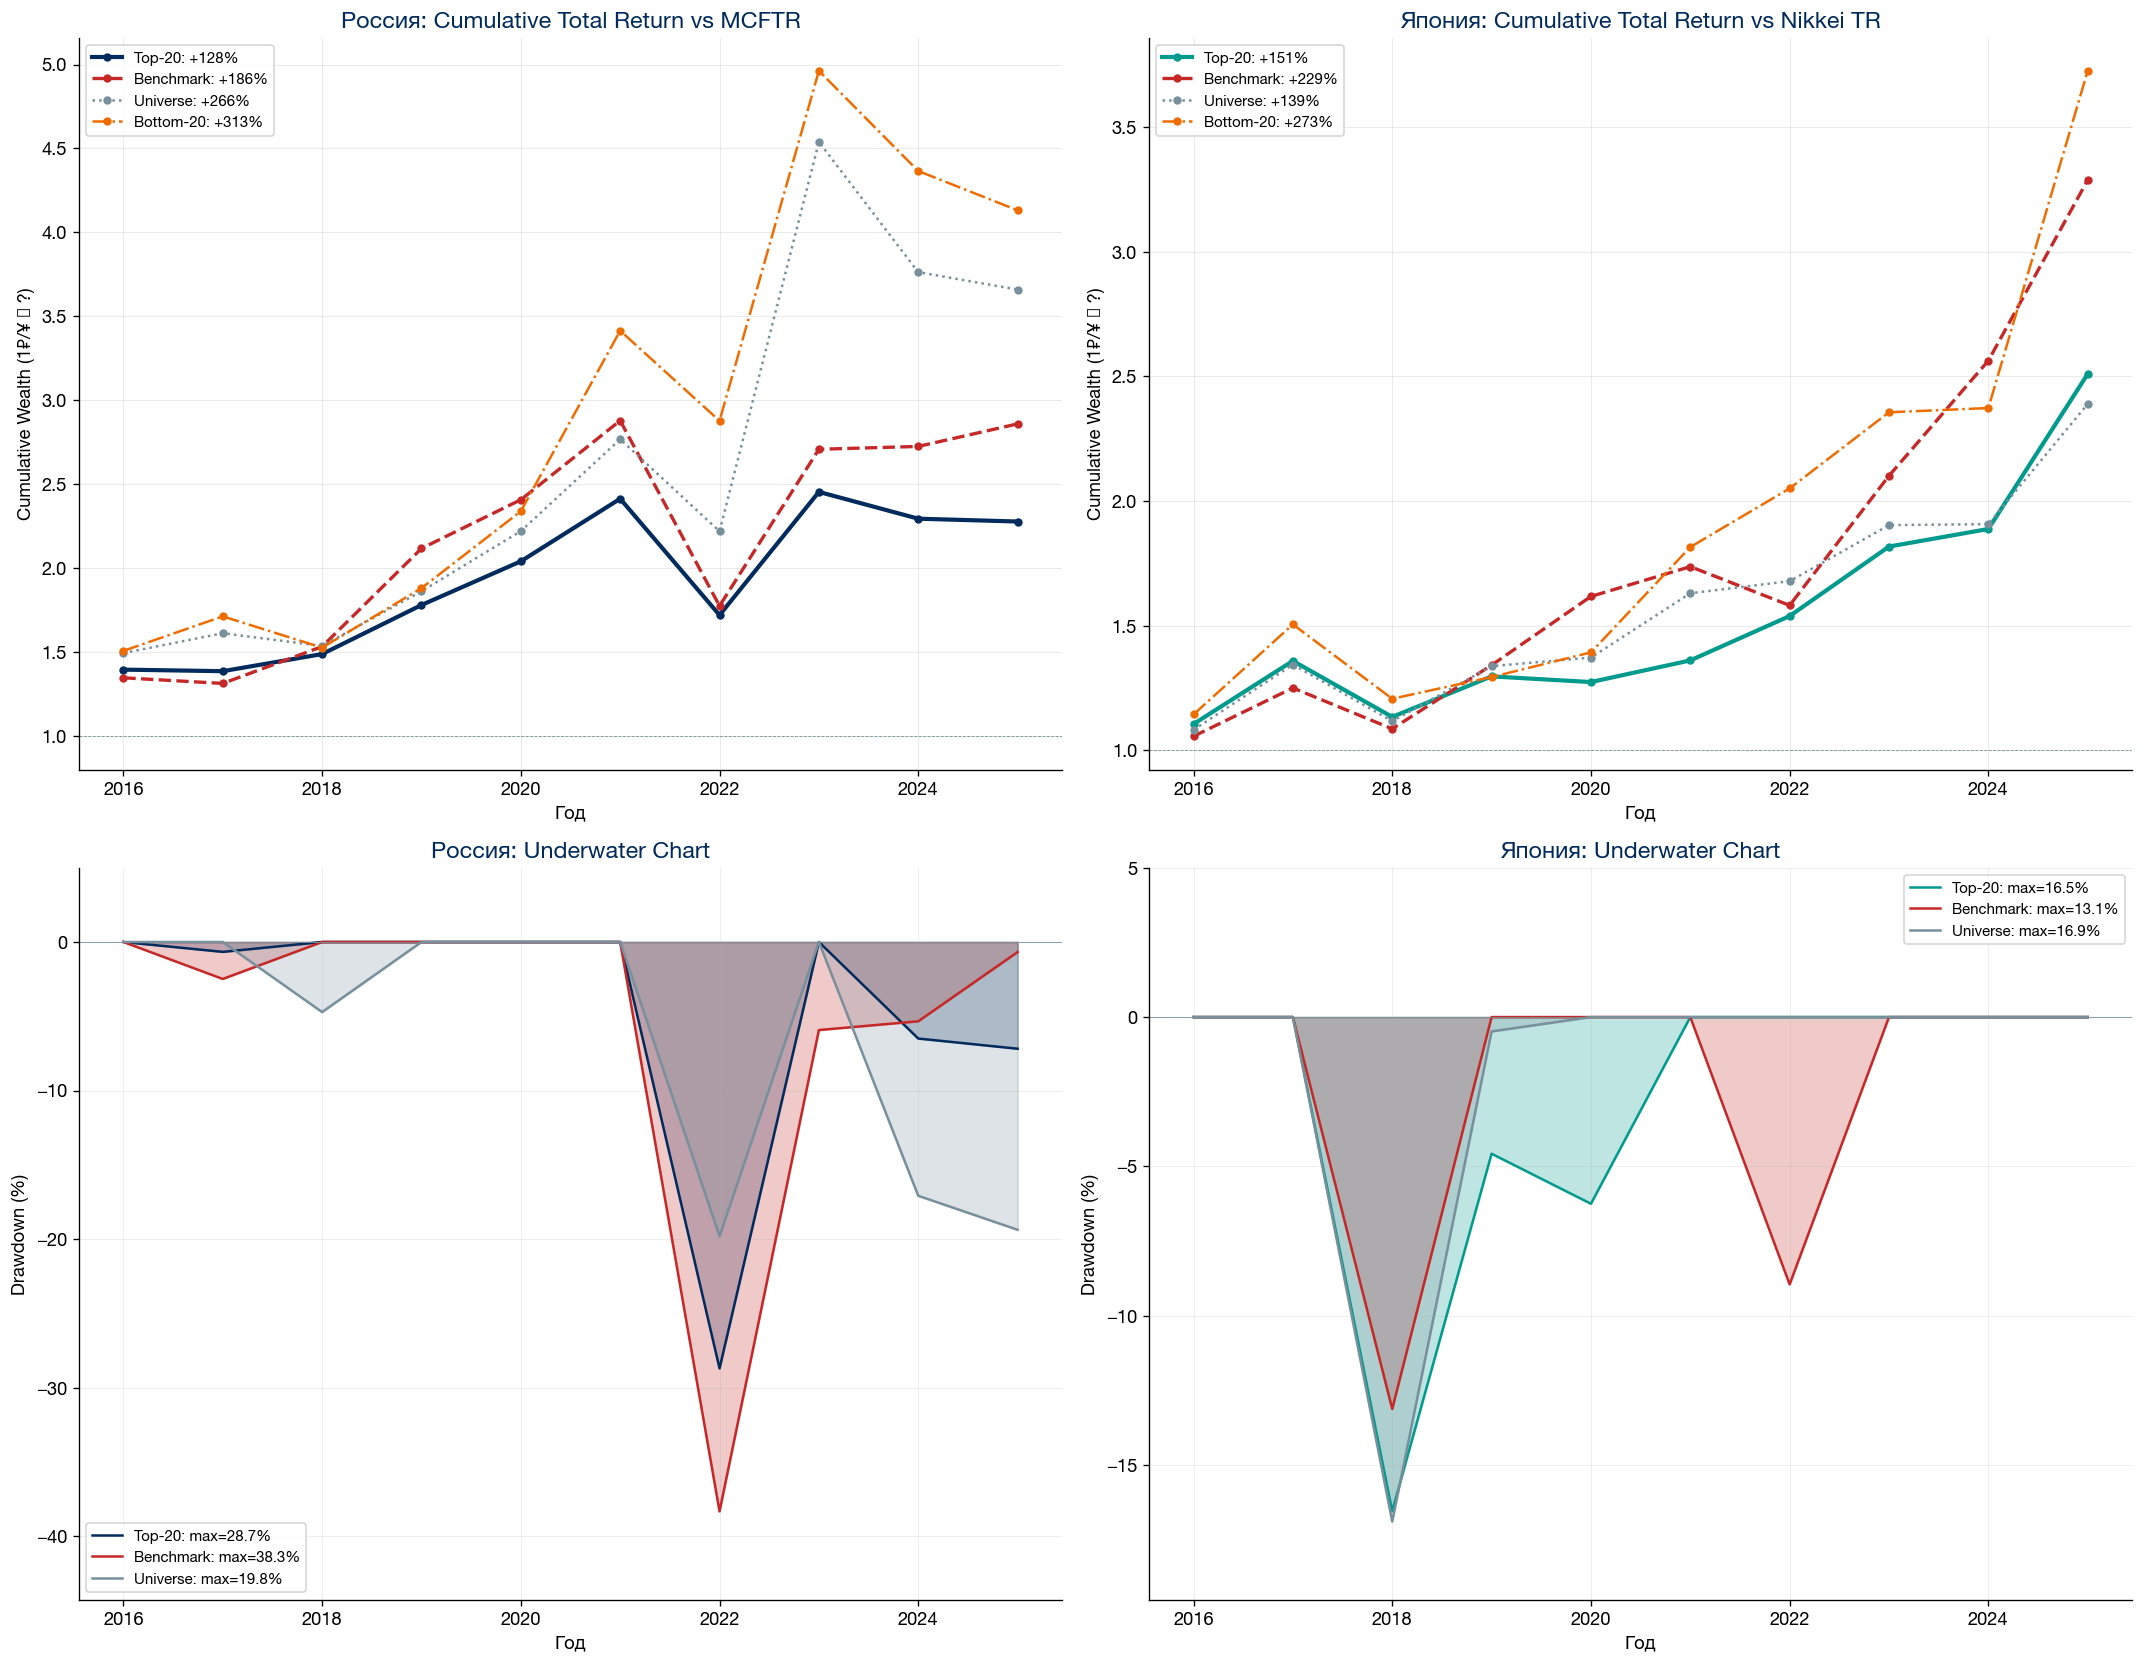

/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/1619424573.py:299: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/1619424573.py:299: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:257: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.png')
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:257: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.png')
/var/folders/bw/89jl601x6f716d0pv9t8hv9m0000gn/T/ipykernel_36249/676410520.py:258: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Helvetica Neue.
  plt.savefig(f'{OUT_DIR}/{name}.pdf')
/var/folders/bw/89jl601x6f716d0pv

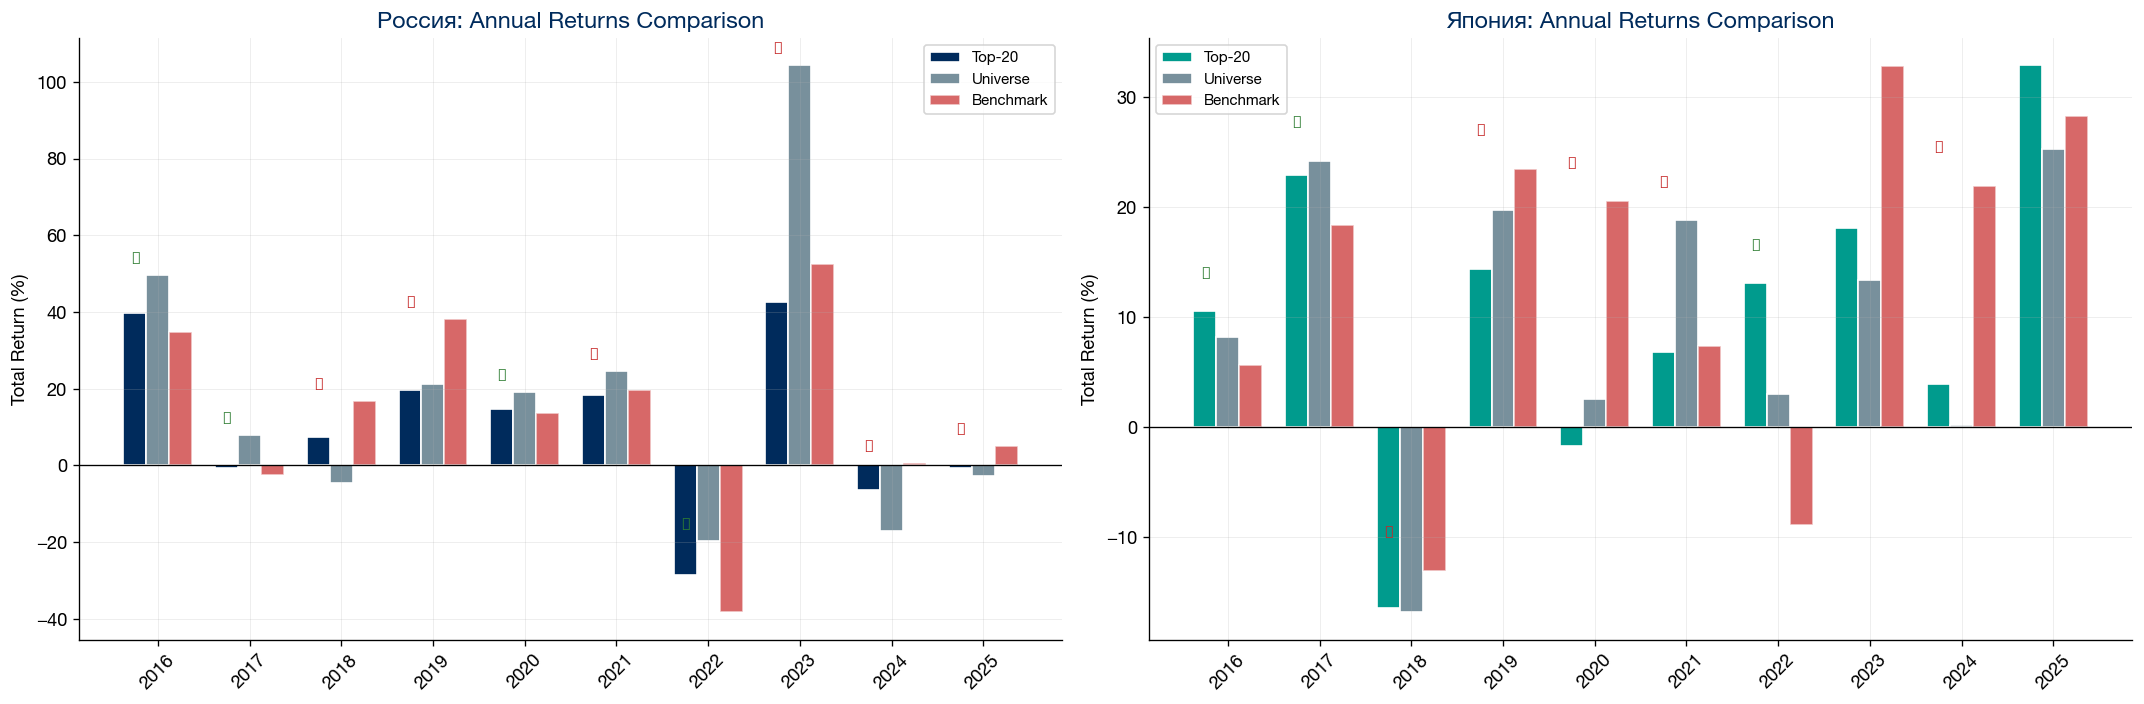

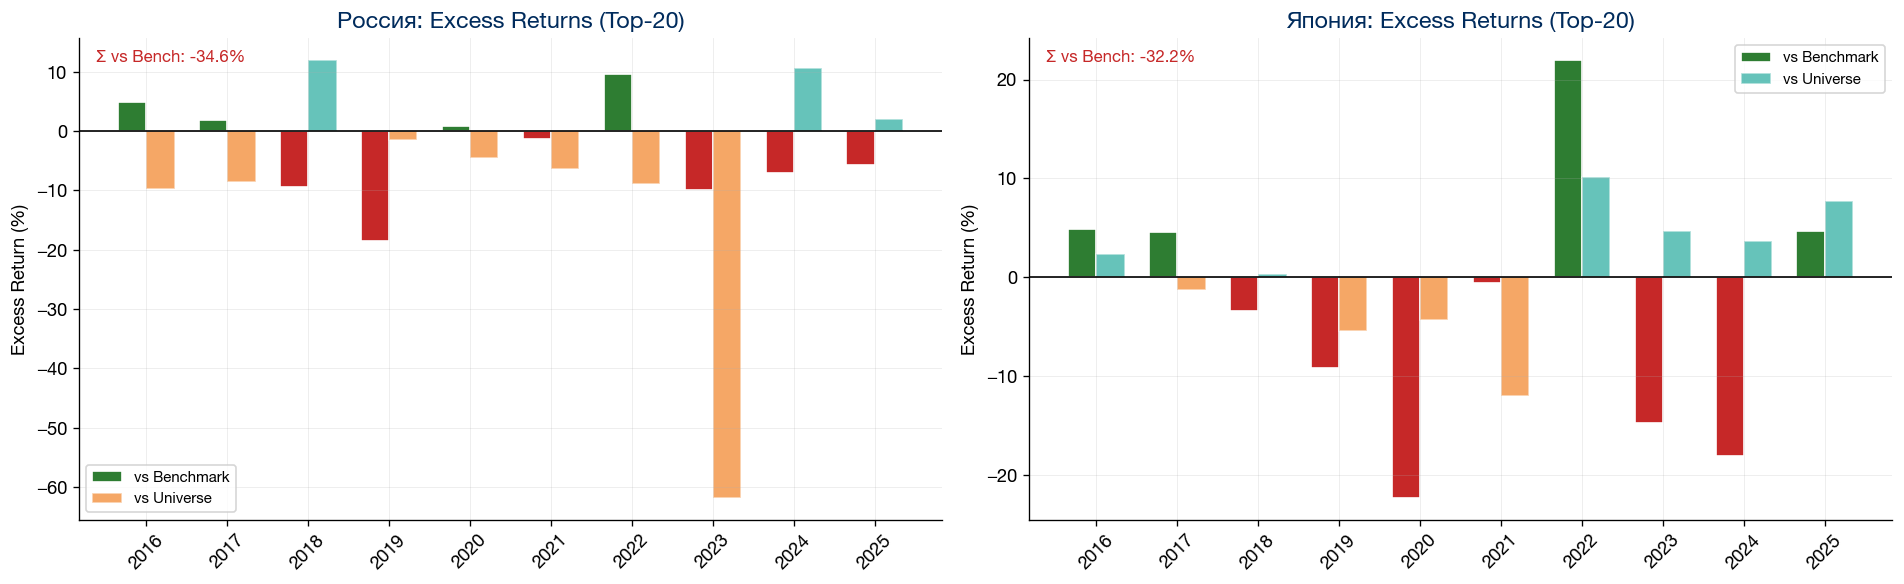

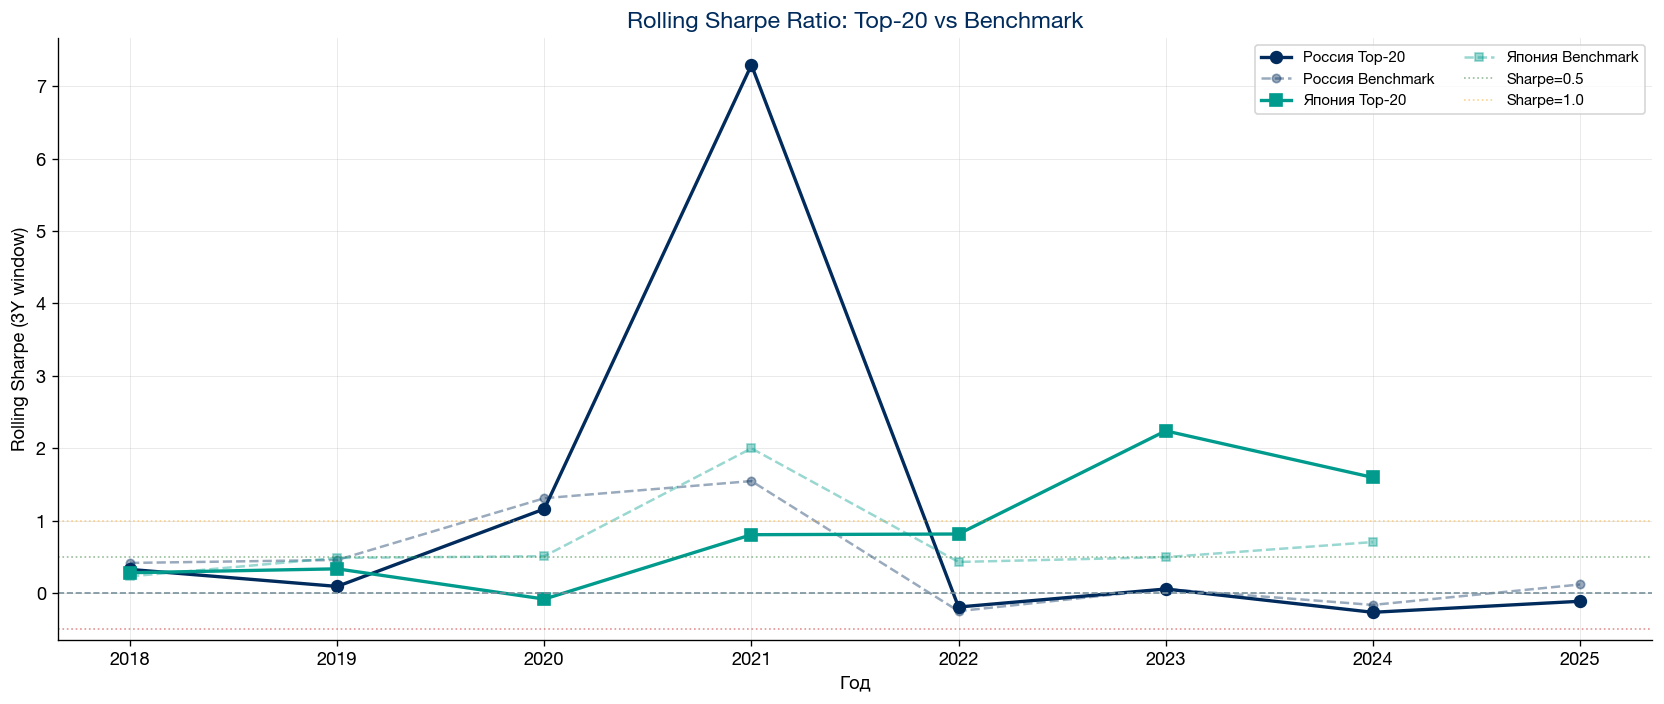

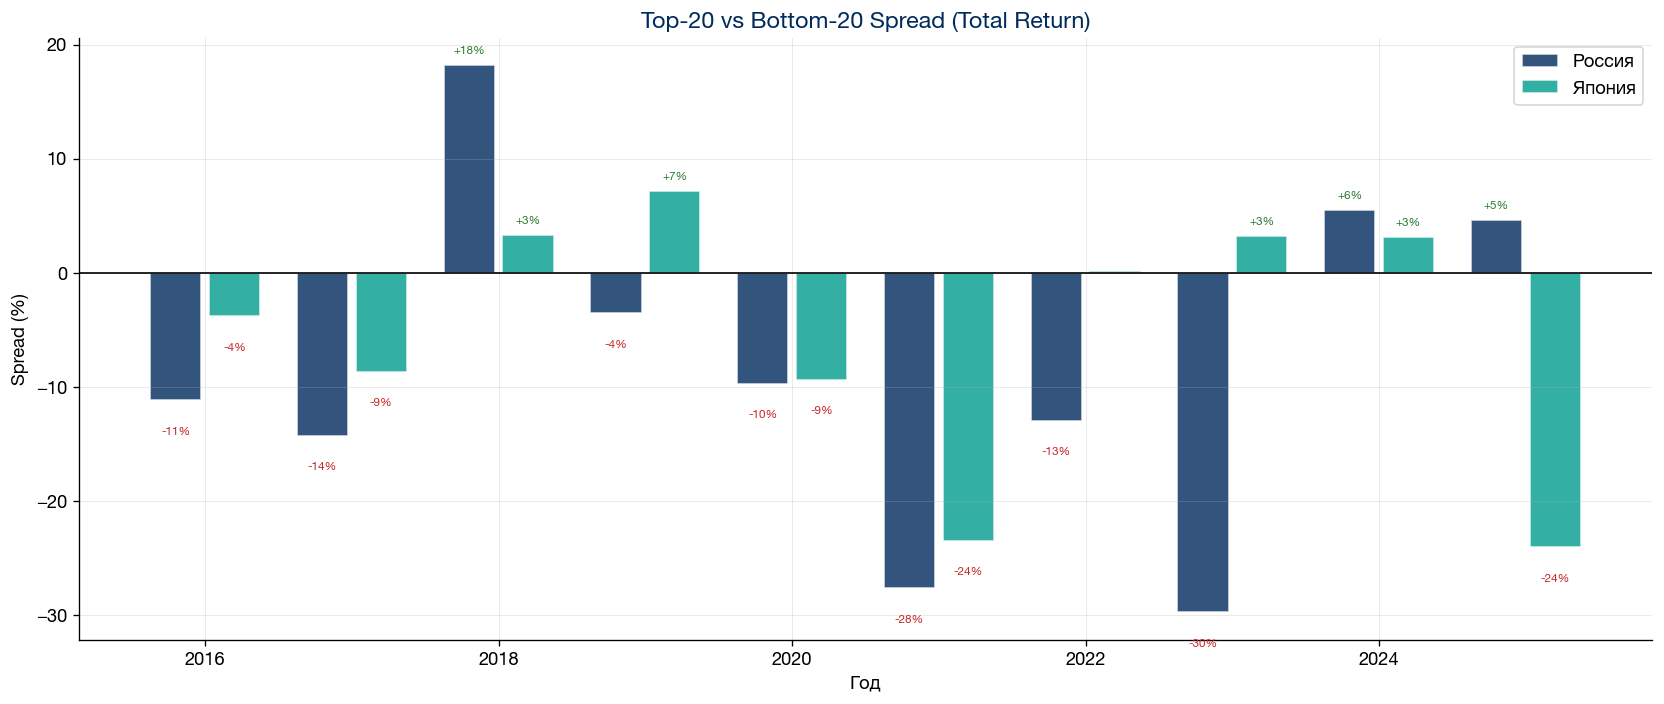

Страна,Return,Bench Return,Excess,Vol,Sharpe,Bench Sharpe,Sortino,MaxDD,Bench MaxDD,Alpha,Beta,IR,Win%,Cumulative
Россия,+10.6%,+14.0%,-3.5%,21.4%,0.02,0.16,0.02,28.7%,38.3%,-2.8%,0.83,-0.42,60%,+128%
Япония,+10.4%,+13.7%,-3.2%,13.6%,nan,nan,∞,16.5%,13.1%,N/A,N/A,N/A,80%,+151%


✅ Backtest results saved to: /Users/dmitrijeremkin/Desktop/диплом созвон 5/OUTPUT_ML_V5/backtest_full_results.xlsx


In [29]:
# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: ТАБЛИЦЫ МЕТРИК
# ══════════════════════════════════════════════════════════════

# ── Таблица 1: Year-by-year results ──
def make_yearly_table(bt_df, country):
    if len(bt_df) == 0:
        return []
    rows = []
    for _, r in bt_df.iterrows():
        bench_str = f'{r["benchmark_return"]*100:+.1f}%' if np.isfinite(r["benchmark_return"]) else 'N/A'
        excess_bench = f'{r["excess_vs_benchmark"]*100:+.1f}%' if np.isfinite(r.get("excess_vs_benchmark", np.nan)) else 'N/A'
        rows.append([
            f'{int(r["year"])}→{int(r["holding_year"])}',
            f'{r["top_k_return"]*100:+.1f}%',
            f'{r["bottom_k_return"]*100:+.1f}%',
            f'{r["universe_return"]*100:+.1f}%',
            bench_str,
            f'{r["rf"]*100:.1f}%',
            excess_bench,
            f'{r["excess_vs_universe"]*100:+.1f}%',
            f'{r["top_k_hit_rate"]:.0%}' if np.isfinite(r.get("top_k_hit_rate", np.nan)) else 'N/A',
        ])
    # Средняя строка
    rows.append([
        'СРЕДНЕЕ',
        f'{bt_df["top_k_return"].mean()*100:+.1f}%',
        f'{bt_df["bottom_k_return"].mean()*100:+.1f}%',
        f'{bt_df["universe_return"].mean()*100:+.1f}%',
        f'{bt_df["benchmark_return"].mean()*100:+.1f}%',
        f'{bt_df["rf"].mean()*100:.1f}%',
        f'{bt_df["excess_vs_benchmark"].mean()*100:+.1f}%',
        f'{bt_df["excess_vs_universe"].mean()*100:+.1f}%',
        f'{bt_df["top_k_hit_rate"].mean():.0%}' if 'top_k_hit_rate' in bt_df else 'N/A',
    ])
    return rows

for bt_df, country in [(bt_real_rf, 'Россия'), (bt_real_jp, 'Япония')]:
    if len(bt_df) == 0:
        continue
    rows = make_yearly_table(bt_df, country)
    html = mckinsey_table(
        rows,
        ['Период', f'Top-{TOP_K}', f'Bottom-{TOP_K}', 'Universe',
         'Benchmark', 'Rf', 'Excess vs Bench', 'Excess vs Univ', 'Hit Rate'],
        f'Backtest Year-by-Year — {country} ({bt_df["year"].min():.0f}–{bt_df["year"].max():.0f})',
        highlight_col=1)
    display(HTML(html))

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: RISK METRICS TABLE
# ══════════════════════════════════════════════════════════════

def format_risk_comparison(risk_metrics, country):
    if not risk_metrics:
        return []

    metrics_config = [
        ('mean_return',      'Mean Annual Return',     'pct'),
        ('volatility',       'Volatility (σ)',          'pct'),
        ('sharpe',           'Sharpe Ratio',            'ratio'),
        ('sortino',          'Sortino Ratio',           'ratio'),
        ('max_drawdown',     'Max Drawdown',            'pct'),
        ('calmar',           'Calmar Ratio',            'ratio'),
        ('var_95',           'VaR 95%',                 'pct'),
        ('cvar_95',          'CVaR 95%',                'pct'),
        ('win_rate',         'Win Rate',                'pct_direct'),
        ('best_year',        'Best Year',               'pct'),
        ('worst_year',       'Worst Year',              'pct'),
        ('cumulative_return','Cumulative Return',       'pct'),
        ('alpha',            'Alpha (vs Bench)',        'pct'),
        ('beta',             'Beta (vs Bench)',         'ratio'),
        ('tracking_error',   'Tracking Error',          'pct'),
        ('information_ratio','Information Ratio',       'ratio'),
        ('skewness',         'Skewness',                'ratio'),
        ('kurtosis',         'Kurtosis',                'ratio'),
    ]

    port_order = ['top_k', 'bottom_k', 'universe', 'benchmark', 'random']
    port_labels = {
        'top_k': f'Top-{TOP_K}', 'bottom_k': f'Bottom-{TOP_K}',
        'universe': 'Universe', 'benchmark': 'Benchmark', 'random': 'Random'
    }

    rows = []
    for key, label, fmt in metrics_config:
        row = [label]
        for port in port_order:
            if port in risk_metrics:
                val = risk_metrics[port].get(key, np.nan)
                if not np.isfinite(val):
                    row.append('N/A')
                elif fmt == 'pct':
                    row.append(f'{val*100:+.1f}%' if key not in ['volatility', 'max_drawdown', 'tracking_error'] else f'{val*100:.1f}%')
                elif fmt == 'pct_direct':
                    row.append(f'{val:.0%}')
                else:
                    row.append(f'{val:.2f}')
            else:
                row.append('—')
        rows.append(row)
    return rows, [port_labels.get(p, p) for p in port_order]

for risk_m, country in [(risk_real_rf, 'Россия'), (risk_real_jp, 'Япония')]:
    if not risk_m:
        continue
    rows, port_headers = format_risk_comparison(risk_m, country)
    html = mckinsey_table(
        rows,
        ['Метрика'] + port_headers,
        f'Risk Metrics — {country} (RUONIA/MCFTR)' if country == 'Россия' else f'Risk Metrics — {country} (BOJ/Nikkei)',
        highlight_col=1)
    display(HTML(html))

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: DETAILED PRINT
# ══════════════════════════════════════════════════════════════

for risk_m, country, rf_name, bench_name in [
    (risk_real_rf, 'Россия', 'RUONIA', 'MCFTR'),
    (risk_real_jp, 'Япония', 'BOJ', 'Nikkei 225 TR')
]:
    if not risk_m or 'top_k' not in risk_m:
        continue

    top = risk_m['top_k']
    univ = risk_m.get('universe', {})
    bench = risk_m.get('benchmark', {})
    bottom = risk_m.get('bottom_k', {})

    print(f'\n{"═"*70}')
    print(f'  {country}: Top-{TOP_K} Stability Portfolio')
    print(f'  Rf = {rf_name}, Benchmark = {bench_name}')
    print(f'{"═"*70}')

    print(f'\n  RETURN METRICS ({top["n_years"]} лет)')
    print(f'  ├─ Mean Annual Return:    {top["mean_return"]*100:+6.2f}%')
    print(f'  ├─ Cumulative Return:     {top["cumulative_return"]*100:+6.1f}%')
    print(f'  ├─ Best Year:             {top["best_year"]*100:+6.1f}%')
    print(f'  └─ Worst Year:            {top["worst_year"]*100:+6.1f}%')

    print(f'\n  📉 RISK METRICS')
    print(f'  ├─ Volatility (σ):        {top["volatility"]*100:6.2f}%')
    print(f'  ├─ Max Drawdown:          {top["max_drawdown"]*100:6.2f}%')
    print(f'  ├─ VaR 95%:               {top["var_95"]*100:+6.2f}%')
    print(f'  └─ CVaR 95%:              {top["cvar_95"]*100:+6.2f}%')

    print(f'\n  RISK-ADJUSTED RETURNS')
    print(f'  ├─ Sharpe Ratio:          {top["sharpe"]:6.2f}')
    sortino_str = f'{top["sortino"]:6.2f}' if top["sortino"] < 99 else '∞'
    print(f'  ├─ Sortino Ratio:         {sortino_str}')
    print(f'  └─ Calmar Ratio:          {top["calmar"]:6.2f}')

    print(f'\n  CONSISTENCY')
    print(f'  ├─ Win Rate:              {top["win_rate"]:6.0%}')
    sk = top.get("skewness", np.nan)
    kt = top.get("kurtosis", np.nan)
    print(f'  ├─ Skewness:              {sk:+6.2f}' if np.isfinite(sk) else '  ├─ Skewness:              N/A')
    print(f'  └─ Kurtosis:              {kt:6.2f}' if np.isfinite(kt) else '  └─ Kurtosis:              N/A')

    if np.isfinite(top.get('alpha', np.nan)):
        print(f'\n  📐 vs {bench_name}')
        print(f'  ├─ Alpha:                 {top["alpha"]*100:+6.2f}%')
        print(f'  ├─ Beta:                  {top["beta"]:6.2f}')
        print(f'  ├─ Tracking Error:        {top["tracking_error"]*100:6.2f}%')
        print(f'  └─ Information Ratio:     {top["information_ratio"]:+6.2f}' if np.isfinite(top["information_ratio"]) else '  └─ Information Ratio:     N/A')

    if univ:
        print(f'\n  COMPARISON')
        print(f'  ├─ Top-{TOP_K} vs Universe:   {(top["mean_return"]-univ["mean_return"])*100:+.2f}%')
        print(f'  ├─ Top-{TOP_K} vs Benchmark:  {(top["mean_return"]-bench.get("mean_return",0))*100:+.2f}%')
        print(f'  ├─ Top-{TOP_K} vs Bottom-{TOP_K}: {(top["mean_return"]-bottom.get("mean_return",0))*100:+.2f}%')
        print(f'  ├─ Sharpe Top vs Bench:   {top["sharpe"]:.2f} vs {bench.get("sharpe",0):.2f}')
        print(f'  └─ MaxDD Top vs Bench:    {top["max_drawdown"]*100:.1f}% vs {bench.get("max_drawdown",0)*100:.1f}%')

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: CUMULATIVE RETURNS & DRAWDOWN
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for col, (returns_dict, bt_df, country, color_main) in enumerate([
    (returns_real_rf, bt_real_rf, 'Россия', NAVY),
    (returns_real_jp, bt_real_jp, 'Япония', TEAL),
]):
    if len(bt_df) == 0:
        continue

    years = bt_df['holding_year'].values

    # ── Row 1: Cumulative Returns ──
    ax = axes[0, col]
    port_configs = [
        ('top_k',     '-',  f'Top-{TOP_K}',     color_main, 2.5),
        ('benchmark', '--', 'Benchmark',         CRIMSON,    2.0),
        ('universe',  ':',  'Universe',          GRAY,       1.5),
        ('bottom_k',  '-.', f'Bottom-{TOP_K}',   ORANGE,     1.5),
    ]

    for name, ls, label, clr, lw in port_configs:
        if name not in returns_dict or len(returns_dict[name]) == 0:
            continue
        rets = np.array(returns_dict[name])
        cum = np.cumprod(1 + rets)
        final = (cum[-1] - 1) * 100
        ax.plot(years, cum, linestyle=ls, linewidth=lw, marker='o',
                markersize=4, color=clr, label=f'{label}: {final:+.0f}%')

    ax.axhline(y=1, color=GRAY, ls='--', lw=0.5)
    ax.set_xlabel('Год')
    ax.set_ylabel('Cumulative Wealth (1₽/¥ → ?)')
    bench_name = 'MCFTR' if country == 'Россия' else 'Nikkei TR'
    ax.set_title(f'{country}: Cumulative Total Return vs {bench_name}',
                 fontsize=14, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)

    # ── Row 2: Drawdown ──
    ax = axes[1, col]
    for name, clr, label in [
        ('top_k', color_main, f'Top-{TOP_K}'),
        ('benchmark', CRIMSON, 'Benchmark'),
        ('universe', GRAY, 'Universe'),
    ]:
        if name not in returns_dict or len(returns_dict[name]) == 0:
            continue
        rets = np.array(returns_dict[name])
        wealth = np.cumprod(1 + rets)
        peak = np.maximum.accumulate(wealth)
        dd = (peak - wealth) / peak * 100
        ax.fill_between(years, 0, -dd, alpha=0.25, color=clr)
        ax.plot(years, -dd, color=clr, lw=1.5,
                label=f'{label}: max={np.max(dd):.1f}%')

    ax.axhline(y=0, color=GRAY, ls='-', lw=0.5)
    ax.set_xlabel('Год')
    ax.set_ylabel('Drawdown (%)')
    ax.set_title(f'{country}: Underwater Chart',
                 fontsize=14, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)
    ax.set_ylim(ax.get_ylim()[0] * 1.1, 5)

plt.tight_layout()
save_fig('fig_backtest_cumulative_drawdown')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: YEAR-BY-YEAR BAR CHART
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (bt_df, returns_dict, country, color_main) in zip(axes, [
    (bt_real_rf, returns_real_rf, 'Россия', NAVY),
    (bt_real_jp, returns_real_jp, 'Япония', TEAL),
]):
    if len(bt_df) == 0:
        continue

    years = bt_df['holding_year'].values
    x = np.arange(len(years))
    w = 0.25

    top_rets = np.array(returns_dict['top_k']) * 100
    univ_rets = np.array(returns_dict['universe']) * 100
    bench_rets = np.array(returns_dict['benchmark']) * 100

    ax.bar(x - w, top_rets, w, label=f'Top-{TOP_K}', color=color_main,
           edgecolor='white')
    ax.bar(x, univ_rets, w, label='Universe', color=GRAY,
           edgecolor='white')
    ax.bar(x + w, bench_rets, w, label='Benchmark', color=CRIMSON,
           edgecolor='white', alpha=0.7)

    ax.axhline(y=0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(years.astype(int), rotation=45)
    ax.set_ylabel('Total Return (%)')
    ax.set_title(f'{country}: Annual Returns Comparison',
                 fontsize=14, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)

    # Win/loss markers
    for i in range(len(years)):
        excess = top_rets[i] - bench_rets[i]
        marker = '✓' if excess > 0 else '✗'
        color = GREEN if excess > 0 else CRIMSON
        y_pos = max(top_rets[i], univ_rets[i], bench_rets[i]) + 3
        ax.annotate(marker, (x[i] - w, y_pos), ha='center',
                   fontsize=10, color=color, fontweight='bold')

plt.tight_layout()
save_fig('fig_backtest_annual_returns')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: EXCESS RETURN CHART
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (bt_df, country, color) in zip(axes, [
    (bt_real_rf, 'Россия', NAVY),
    (bt_real_jp, 'Япония', TEAL),
]):
    if len(bt_df) == 0:
        continue

    years = bt_df['holding_year'].values
    excess_bench = bt_df['excess_vs_benchmark'].values * 100
    excess_univ = bt_df['excess_vs_universe'].values * 100

    x = np.arange(len(years))
    w = 0.35

    colors_bench = [GREEN if v > 0 else CRIMSON for v in excess_bench]
    colors_univ = [TEAL if v > 0 else ORANGE for v in excess_univ]

    ax.bar(x - w/2, excess_bench, w, color=colors_bench, edgecolor='white',
           label='vs Benchmark')
    ax.bar(x + w/2, excess_univ, w, color=colors_univ, edgecolor='white',
           alpha=0.6, label='vs Universe')

    ax.axhline(y=0, color='black', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(years.astype(int), rotation=45)
    ax.set_ylabel('Excess Return (%)')
    ax.set_title(f'{country}: Excess Returns (Top-{TOP_K})',
                 fontsize=14, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9)

    # Cumulative excess annotation
    cum_excess_bench = np.nansum(excess_bench)
    ax.annotate(f'Σ vs Bench: {cum_excess_bench:+.1f}%',
               xy=(0.02, 0.95), xycoords='axes fraction',
               fontsize=10, fontweight='bold',
               color=GREEN if cum_excess_bench > 0 else CRIMSON)

plt.tight_layout()
save_fig('fig_backtest_excess_returns')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: ROLLING SHARPE
# ══════════════════════════════════════════════════════════════

def rolling_sharpe(returns, rf_rates, window=3):
    results = []
    for i in range(len(returns)):
        if i < window - 1:
            results.append(np.nan)
        else:
            r = returns[i-window+1:i+1]
            f = rf_rates[i-window+1:i+1]
            excess = r - f
            std = np.std(excess, ddof=1)
            results.append(np.mean(excess) / std if std > 0 else np.nan)
    return np.array(results)

fig, ax = plt.subplots(figsize=(14, 6))

for returns_dict, bt_df, country, color, marker in [
    (returns_real_rf, bt_real_rf, 'Россия', NAVY, 'o'),
    (returns_real_jp, bt_real_jp, 'Япония', TEAL, 's'),
]:
    if len(bt_df) == 0:
        continue

    years = bt_df['holding_year'].values
    rets = np.array(returns_dict['top_k'])
    rfs = np.array(returns_dict['rf'])
    rs = rolling_sharpe(rets, rfs, window=3)

    ax.plot(years, rs, marker=marker, markersize=7, linewidth=2,
            color=color, label=f'{country} Top-{TOP_K}')

    # Benchmark rolling sharpe
    bench_rets = np.array(returns_dict['benchmark'])
    rs_bench = rolling_sharpe(bench_rets, rfs, window=3)
    ax.plot(years, rs_bench, marker=marker, markersize=5, linewidth=1.5,
            color=color, alpha=0.4, linestyle='--',
            label=f'{country} Benchmark')

ax.axhline(y=0, color=GRAY, ls='--', lw=1)
ax.axhline(y=0.5, color=GREEN, ls=':', lw=1, alpha=0.5, label='Sharpe=0.5')
ax.axhline(y=1.0, color=GOLD, ls=':', lw=1, alpha=0.5, label='Sharpe=1.0')
ax.axhline(y=-0.5, color=CRIMSON, ls=':', lw=1, alpha=0.5)

ax.set_xlabel('Год')
ax.set_ylabel('Rolling Sharpe (3Y window)')
ax.set_title(f'Rolling Sharpe Ratio: Top-{TOP_K} vs Benchmark',
             fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('fig_backtest_rolling_sharpe')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: TOP-K vs BOTTOM-K SPREAD
# ══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 6))

for bt_df, returns_dict, country, color in [
    (bt_real_rf, returns_real_rf, 'Россия', NAVY),
    (bt_real_jp, returns_real_jp, 'Япония', TEAL),
]:
    if len(bt_df) == 0:
        continue

    years = bt_df['holding_year'].values
    top_rets = np.array(returns_dict['top_k']) * 100
    bottom_rets = np.array(returns_dict['bottom_k']) * 100
    spread = top_rets - bottom_rets

    x_offset = -0.2 if country == 'Россия' else 0.2
    bars = ax.bar(years + x_offset, spread, 0.35, label=country,
                  color=color, edgecolor='white', alpha=0.8)

    for bar, val in zip(bars, spread):
        if abs(val) > 2:
            ax.text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + (1 if val > 0 else -3),
                   f'{val:+.0f}%', ha='center', fontsize=7,
                   color=GREEN if val > 0 else CRIMSON)

ax.axhline(y=0, color='black', lw=1)
ax.set_xlabel('Год')
ax.set_ylabel('Spread (%)')
ax.set_title(f'Top-{TOP_K} vs Bottom-{TOP_K} Spread (Total Return)',
             fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig('fig_backtest_spread')
plt.show()

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: SUMMARY COMPARISON TABLE
# ══════════════════════════════════════════════════════════════

summary_rows = []
for risk_m, country, rf_name, bench_name in [
    (risk_real_rf, 'Россия', 'RUONIA', 'MCFTR'),
    (risk_real_jp, 'Япония', 'BOJ', 'Nikkei'),
]:
    if not risk_m or 'top_k' not in risk_m:
        continue

    top = risk_m['top_k']
    bench = risk_m.get('benchmark', {})

    summary_rows.append([
        country,
        f'{top.get("mean_return",0)*100:+.1f}%',
        f'{bench.get("mean_return",0)*100:+.1f}%',
        f'{(top.get("mean_return",0)-bench.get("mean_return",0))*100:+.1f}%',
        f'{top.get("volatility",0)*100:.1f}%',
        f'{top.get("sharpe",0):.2f}',
        f'{bench.get("sharpe",0):.2f}',
        f'{top.get("sortino",0):.2f}' if top.get("sortino",0) < 99 else '∞',
        f'{top.get("max_drawdown",0)*100:.1f}%',
        f'{bench.get("max_drawdown",0)*100:.1f}%',
        f'{top.get("alpha",0)*100:+.1f}%' if np.isfinite(top.get("alpha", np.nan)) else 'N/A',
        f'{top.get("beta",0):.2f}' if np.isfinite(top.get("beta", np.nan)) else 'N/A',
        f'{top.get("information_ratio",0):+.2f}' if np.isfinite(top.get("information_ratio", np.nan)) else 'N/A',
        f'{top.get("win_rate",0):.0%}',
        f'{top.get("cumulative_return",0)*100:+.0f}%',
    ])

if summary_rows:
    html = mckinsey_table(
        summary_rows,
        ['Страна', 'Return', 'Bench Return', 'Excess', 'Vol',
         'Sharpe', 'Bench Sharpe', 'Sortino', 'MaxDD',
         'Bench MaxDD', 'Alpha', 'Beta', 'IR', 'Win%', 'Cumulative'],
        f'Portfolio Performance Summary: Top-{TOP_K} Stability Strategy',
        highlight_col=3)
    display(HTML(html))

# %%
# ══════════════════════════════════════════════════════════════
#  BACKTEST: EXPORT TO EXCEL
# ══════════════════════════════════════════════════════════════

backtest_path = f'{OUT_DIR}/backtest_full_results.xlsx'

with pd.ExcelWriter(backtest_path, engine='openpyxl') as writer:
    for bt_df, country in [(bt_real_rf, 'Russia'), (bt_real_jp, 'Japan')]:
        if len(bt_df) > 0:
            bt_df.to_excel(writer, sheet_name=f'{country}_Yearly', index=False)

    # Risk metrics
    risk_rows = []
    for country, risk_m in [('Russia', risk_real_rf), ('Japan', risk_real_jp)]:
        if not risk_m:
            continue
        for port_name, metrics in risk_m.items():
            row = {'country': country, 'portfolio': port_name}
            row.update(metrics)
            risk_rows.append(row)
    if risk_rows:
        pd.DataFrame(risk_rows).to_excel(writer, sheet_name='Risk_Metrics', index=False)

    # Portfolio compositions
    for country, details in [('Russia', details_real_rf), ('Japan', details_real_jp)]:
        if not details:
            continue
        comp_rows = []
        for year, d in details.items():
            for i, (tk, ret) in enumerate(zip(d['tickers'], d['returns'])):
                comp_rows.append({'year': year, 'rank': i+1,
                                 'ticker': tk, 'return': ret})
        if comp_rows:
            pd.DataFrame(comp_rows).to_excel(
                writer, sheet_name=f'{country}_Portfolios', index=False)

print(f'✅ Backtest results saved to: {backtest_path}')